# Set-Up

In [ ]:
# Title: BayesAge_all_killifish_atlas_clocks_241104.ipynb
# Author: Lajoyce Mboning
# Edited by: Emma K. Costa
# Date:2024
# Related publication: Emma K. Costa, and Jingxun Chen, In prep.


# Description - Run the BayesAge Tissue Clocks

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from numpy import arange
from numpy import absolute
from numpy import mean
from numpy import std
import numpy as np
from scipy import stats
from sklearn.metrics import mean_absolute_error as mae
import statsmodels.api as sm
from scipy.stats import spearmanr
lowess = sm.nonparametric.lowess
from scipy.stats import poisson
from scipy.stats import pearsonr
from datetime import datetime
import time

In [ ]:
#allow Google CoLab to have access to your drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# set working dir
import os
os.chdir("/content/drive/My Drive/african_killifish_atlas/Code_check")

In [ ]:
# function to make the transcriptome reference
def transcriptome_reference(training_matrix,
                        reference_name,
                        output_path="./predictions/",
                        age_prediction="list",
                        age_list=[],
                        min_age=-20,
                        max_age=100,
                        age_step=1,
                        tau=0.7,
                        ):

    start_time = time.time()

    training_cv_df = pd.read_csv(training_matrix, sep="\t", index_col=0, low_memory=False)

    training_df_frequency = training_cv_df.iloc[:,:-1]

    #print(training_df_frequency)

    training_df_frequency = training_df_frequency.div(training_df_frequency.sum(axis=1), axis=0)

    genes = training_cv_df.iloc[:,:-1].columns.tolist()

    age_steps = np.arange(min_age, max_age + age_step, age_step)

    # Age values from the reference data
    age_training = training_cv_df["age"].values.flatten()

    final_training_matrix = []

    if age_prediction == "list":

        for gene in genes:
            # Frequency level of current gene
            gene_frequency = training_df_frequency[gene].values.flatten()

            # Perform lowess smoothing
            predicted_frequency_levels = lowess(gene_frequency, age_training, xvals=age_list, frac=tau)

            # Calculate Spearman rank correlation
            rho, p = spearmanr(age_training, gene_frequency)

            spearman_rank = rho

            p_value = p

            final_gene_frequency_tuple = (gene, ) + tuple(predicted_frequency_levels) + (spearman_rank, p_value)

            final_training_matrix.append(final_gene_frequency_tuple)

        df_columns = ["Gene"] + [str(num) for num in age_list] + ["spearman_rank", "p_value"]

    elif age_prediction == "steps":

        for gene in genes:
            # Frequency level of current gene
            gene_frequency = training_df_frequency[gene].values.flatten()

            # Perform lowess smoothing
            predicted_frequency_levels = lowess(gene_frequency, age_training, xvals=age_steps, frac=tau)

            # Calculate Spearman rank correlation
            rho, p = spearmanr(age_training, gene_frequency)

            spearman_rank = rho

            p_value = p

            final_gene_frequency_tuple = (gene, ) + tuple(predicted_frequency_levels) + (spearman_rank, p_value)

            final_training_matrix.append(final_gene_frequency_tuple)

        df_columns = ["Gene"] + [str(num) for num in age_steps] + ["spearman_rank", "p_value"]


    df = pd.DataFrame(final_training_matrix, columns=df_columns)
    df.set_index("Gene", inplace=True)

    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    # Save the DataFrame to a TSV file
    df.to_csv(os.path.join(output_path, reference_name), sep="\t")
    print(f"\nReference model dataset written to '{os.path.join(output_path, reference_name)}'")

    number_of_samples = training_cv_df.shape[0]

    # Write report file detailing input matrix
    report_file_path = os.path.join(output_path, f'{reference_name}.report.txt')
    with open(report_file_path, 'w') as writer:
        writer.write("BayesAge reference report for %s\n" % reference_name)
        now = datetime.now()
        write_datetime = now.strftime("%m/%d/%Y %H:%M:%S")
        writer.write("Reference file created: %s\n\n" % write_datetime)
        writer.write("Number of input samples = %s\n" % number_of_samples)
        writer.write("Number of input Genes = %s\n" % len(genes))
        if age_prediction == "list":
            writer.write("Predictions made for ages: %s\n" % age_list)
        elif age_prediction == "steps":
            writer.write("Predictions made for age steps from %s to %s with step %s\n" % (min_age, max_age, age_step))

    print(f"Report file generated at '{report_file_path}'")
    print("-----------------------------------------------------\n\n")

    end_time = time.time()
    elapsed_time = end_time - start_time
    print("\nTime to run construct reference: %0.3f seconds" % elapsed_time)
    print("\nThe reference is constructed and saved!")

    return df  # Optionally return the DataFrame

In [ ]:
# load DESeq2 norm counts
df_norm = pd.read_csv("./AtlasFiles_forLajoyce_240507/CountsNormDESeq2_AllTissue_240506.csv")

In [ ]:
# load raw counts
df_unnorm = pd.read_csv("./AtlasFiles_forLajoyce_240507/Counts_Atlas_allbatches_merged_v3.csv")

In [ ]:
df_unnorm.rename(columns={"Unnamed: 0": "Gene"}, inplace=True)

df_unnorm.head(5)

,Gene,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
0,a1cf,21686,52,5891,6,7544,18,10043,9,0,...,12,45920,3113,9682,4020,37522,1383,36,7855,14
1,aaas,623,585,1108,720,824,1072,1004,611,192,...,484,310,143,336,487,178,148,735,1383,717
2,aacs,1980,502,266,1913,238,2252,308,1614,56,...,1061,6587,291,3347,552,329,178,1124,382,1232
3,aadat,523,537,676,484,674,790,812,536,302,...,976,307,147,121,294,262,118,1485,781,465
4,aaed1,200,709,233,462,292,413,356,378,204,...,124,16,56,14,237,20,66,158,248,264


In [ ]:
df_unnorm.set_index("Gene", inplace=True)

In [ ]:
df_unnorm = df_unnorm.T

df_unnorm.head(5)

Gene,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_1,21686,623,1980,523,200,802,1242,1224,562,577,...,829,161,1014,220,1560,42,515,3018,1422,325
A1_2,52,585,502,537,709,674,1385,2329,652,646,...,1113,92,963,153,1118,27,966,3871,275,364
A10_1,5891,1108,266,676,233,835,1374,809,716,778,...,635,156,1650,137,1370,380,662,3191,498,477
A10_2,6,720,1913,484,462,710,1745,747,1132,785,...,1918,209,1277,278,2082,44,2019,1827,251,380
A11_1,7544,824,238,674,292,726,1363,1049,795,767,...,452,206,1214,117,1139,428,560,2096,387,479


In [ ]:
df_norm = df_norm.T

In [ ]:
df_norm_frequency = df_norm.div(df_norm.sum(axis=1), axis=0)

In [ ]:
# load metadata
df_metadata = pd.read_csv("./AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

/usr/local/lib/python3.10/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.reset_index()

,index,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,...,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,...,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,...,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,...,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN
3,3,A10_2,J_1A_14,M,1A,75,11/22/21,9/8/21,SpinalCord,NaN,...,SpinalCord_1,EC,RNA423,2,A10,A10,A10_2,NaN,NaN,NaN
4,4,A11_1,J_1A_22,M,1A,47,10/25/21,9/8/21,Kidney,NaN,...,Kidney_2,JC,R274,1,A11,A11,A11_1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,672,P7_1,J_1A_25,M,1A,103,12/20/21,9/8/21,Liver,NaN,...,Liver_1,IG,RNA689,1,P7,P7,P7_1,NaN,NaN,NaN
673,673,P7_2,P_1B_1,F,1B,77,12/6/21,9/20/21,Fat,4/13/23,...,Fat_3,EC,RNA566,2,P7,P7,P7_2,NaN,NaN,NaN
674,674,P8_2,J_1A_25,M,1A,103,12/20/21,9/8/21,Eye,NaN,...,Eye_1,MRW,642,2,P8,P8,P8_2,NaN,NaN,NaN
675,675,P9_1,J_1B_2,M,1B,49,11/8/21,9/20/21,Kidney,NaN,...,Kidney_1,JC,R257,1,P9,P9,P9_1,NaN,NaN,NaN


In [ ]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

/usr/local/lib/python3.10/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.set_index("sample", inplace=True)

In [ ]:
# Merge based on index
combined_df = pd.concat([df_unnorm, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)

# Bone

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/bone/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
bone_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "Bone"]

bone_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_2,52,585,502,537,709,674,1385,2329,652,646,...,153,1118,27,966,3871,275,364,M,Bone,78
A2_2,18,404,134,224,317,421,1034,2230,491,372,...,78,548,16,421,2675,316,302,M,Bone,133
A3_2,3406,645,288,537,321,596,1294,1463,452,601,...,110,1086,85,450,2143,267,418,F,Bone,102
A4_2,22,463,139,454,328,434,625,1153,621,354,...,175,543,50,403,2953,133,180,M,Bone,77
B1_2,1804,294,154,355,302,457,661,1398,470,299,...,20,425,85,488,1735,83,184,M,Bone,134


In [ ]:
bone_age_days_value_counts = bone_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
bone_age_steps = sorted(bone_age_days_value_counts)

print(bone_age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
bone_gene_expression_data = bone_df_counts.iloc[:, :-3]

In [ ]:
bone_df_age = bone_gene_expression_data.copy()

In [ ]:
bone_df_age["age"] = bone_df_counts["age_days"].tolist()

bone_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A1_2,52,585,502,537,709,674,1385,2329,652,646,...,92,963,153,1118,27,966,3871,275,364,78
A2_2,18,404,134,224,317,421,1034,2230,491,372,...,66,546,78,548,16,421,2675,316,302,133
A3_2,3406,645,288,537,321,596,1294,1463,452,601,...,166,1213,110,1086,85,450,2143,267,418,102


In [ ]:
for sample in bone_df_age.index.tolist():

    new_df = bone_df_age.drop(sample)

    new_df.to_csv(f"./outputs/all_bayesage_clocks/bone/bone_sample_{sample}.csv", sep="\t")

    print(new_df.shape)

In [ ]:
new_bone_age_steps = np.arange(min(bone_age_steps), max(bone_age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/bone/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
counter = 0

for sample in bone_df_age.index.tolist():

    transcriptome_reference(training_matrix=f"./outputs/all_bayesage_clocks/bone/bone_sample_{sample}.csv",
                            reference_name=f"bone_reference_{sample}",
                            output_path="./outputs/all_bayesage_clocks/bone/reference/",
                            age_prediction="list",
                            age_list=new_bone_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

    counter += 1

    print(counter)

#### Bone Age Prediction

     prediction
A1_2       82.0
A2_2      132.0
A3_2      144.0
A4_2      129.0
B1_2      162.0
B2_2      162.0
B4_2      127.0
C1_2      102.0
C2_2       69.0
C3_2      122.0
C4_2       78.0
D1_2      122.0
D2_2       65.0
D3_2       47.0
D4_2       52.0
E1_2       91.0
E2_2       81.0
E3_2       52.0
E4_2       82.0
F1_2      118.0
F2_2      118.0
F3_2      136.0
G1_2       61.0
G2_2      162.0
G3_2       47.0
H1_2       83.0
H2_2      119.0
H3_2      109.0
I1_2      139.0
I2_2       91.0
I3_2      143.0
J1_2       93.0
J2_2      140.0
J3_2      141.0
K1_2      162.0
K2_2       65.0
K3_2      162.0
L1_2       51.0
L2_2      119.0
L3_2      113.0
M1_2      162.0
M2_2      156.0
M3_2       81.0
N1_2       59.0
N2_2       54.0
N3_2       47.0
O1_2      107.0
O2_2      101.0
O3_2      132.0
P2_2       91.0
P3_2       62.0
[38.04531708  0.64164717]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:             

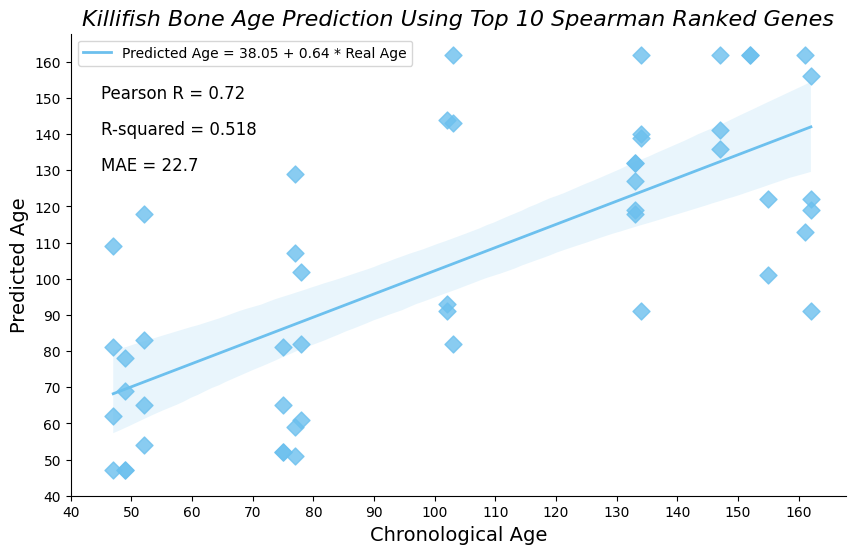

1
     prediction
A1_2      104.0
A2_2      113.0
A3_2      143.0
A4_2      128.0
B1_2      156.0
B2_2      160.0
B4_2      114.0
C1_2       81.0
C2_2       55.0
C3_2      115.0
C4_2       71.0
D1_2      127.0
D2_2       66.0
D3_2       58.0
D4_2       69.0
E1_2      113.0
E2_2       81.0
E3_2       52.0
E4_2       92.0
F1_2       55.0
F2_2      119.0
F3_2      144.0
G1_2       66.0
G2_2      162.0
G3_2       52.0
H1_2       69.0
H2_2      118.0
H3_2      109.0
I1_2      138.0
I2_2      114.0
I3_2      114.0
J1_2      116.0
J2_2      143.0
J3_2      117.0
K1_2      130.0
K2_2       65.0
K3_2      161.0
L1_2       58.0
L2_2      110.0
L3_2      113.0
M1_2      157.0
M2_2      158.0
M3_2       80.0
N1_2       64.0
N2_2       56.0
N3_2       47.0
O1_2      102.0
O2_2      101.0
O3_2      113.0
P2_2      118.0
P3_2       59.0
[35.2731014   0.64968186]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:           

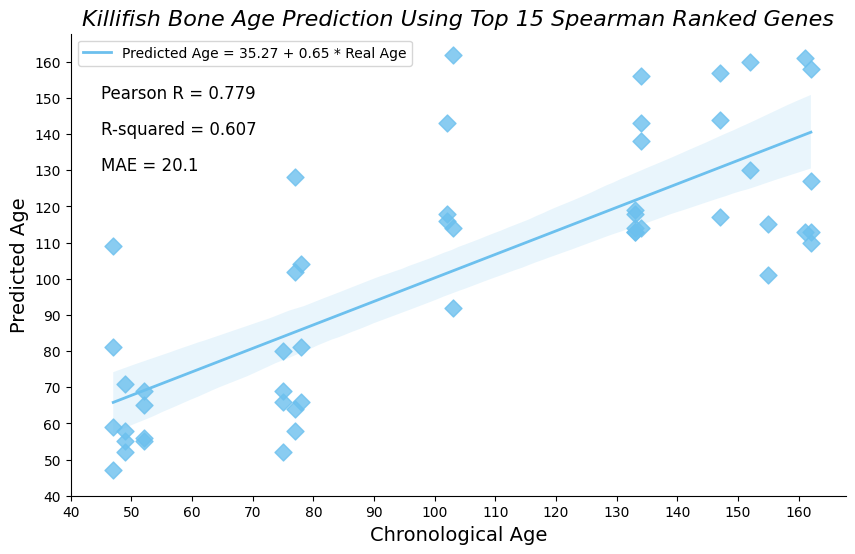

2
     prediction
A1_2       82.0
A2_2      112.0
A3_2       91.0
A4_2      105.0
B1_2       87.0
B2_2      129.0
B4_2      114.0
C1_2      108.0
C2_2       63.0
C3_2      115.0
C4_2       71.0
D1_2      130.0
D2_2       75.0
D3_2       61.0
D4_2       80.0
E1_2       79.0
E2_2       81.0
E3_2      114.0
E4_2       95.0
F1_2       57.0
F2_2       89.0
F3_2      149.0
G1_2       74.0
G2_2      162.0
G3_2       75.0
H1_2       56.0
H2_2      118.0
H3_2       55.0
I1_2      162.0
I2_2      114.0
I3_2      153.0
J1_2      140.0
J2_2      144.0
J3_2      118.0
K1_2      130.0
K2_2       67.0
K3_2      162.0
L1_2       89.0
L2_2      110.0
L3_2      113.0
M1_2      161.0
M2_2      143.0
M3_2       78.0
N1_2       71.0
N2_2       49.0
N3_2       67.0
O1_2      102.0
O2_2      114.0
O3_2      113.0
P2_2      132.0
P3_2       61.0
[44.06078948  0.56358289]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:           

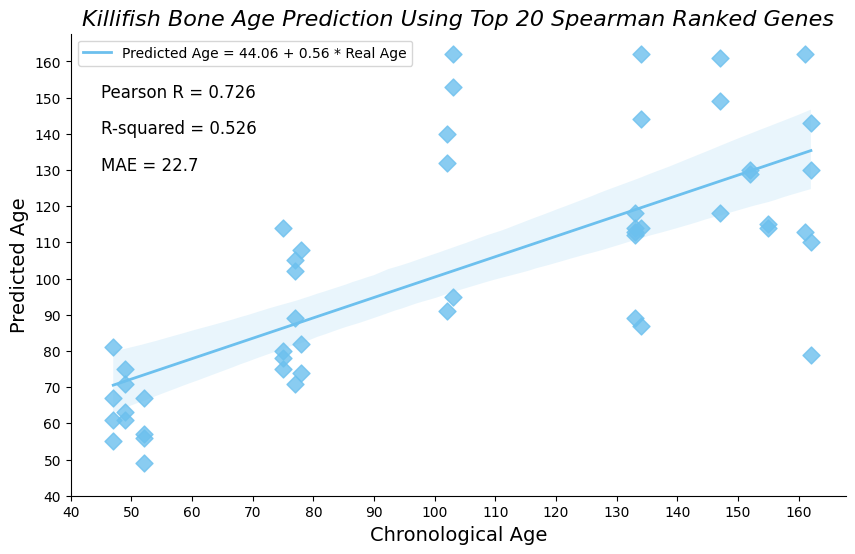

3
     prediction
A1_2       88.0
A2_2      112.0
A3_2       91.0
A4_2      108.0
B1_2       91.0
B2_2      129.0
B4_2      108.0
C1_2      113.0
C2_2       63.0
C3_2      115.0
C4_2       71.0
D1_2      123.0
D2_2       52.0
D3_2       60.0
D4_2       80.0
E1_2      148.0
E2_2       81.0
E3_2      114.0
E4_2      102.0
F1_2       55.0
F2_2      123.0
F3_2      100.0
G1_2       66.0
G2_2      162.0
G3_2       52.0
H1_2       56.0
H2_2      117.0
H3_2       61.0
I1_2      162.0
I2_2      114.0
I3_2       72.0
J1_2       81.0
J2_2      142.0
J3_2      121.0
K1_2      130.0
K2_2       67.0
K3_2      162.0
L1_2       89.0
L2_2      110.0
L3_2      113.0
M1_2      159.0
M2_2      142.0
M3_2       81.0
N1_2       71.0
N2_2       58.0
N3_2       67.0
O1_2      106.0
O2_2      153.0
O3_2      114.0
P2_2      115.0
P3_2       62.0
[35.96255888  0.62519611]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:           

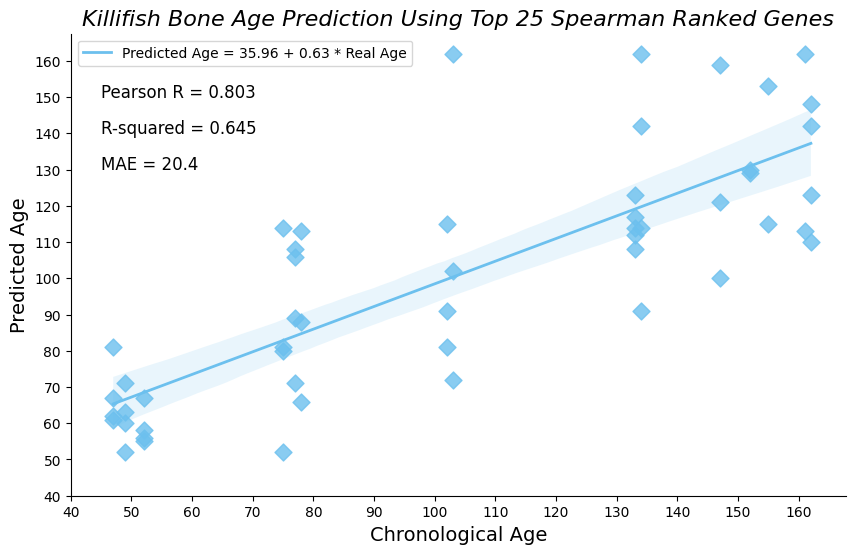

4
     prediction
A1_2       79.0
A2_2      109.0
A3_2       91.0
A4_2      109.0
B1_2       91.0
B2_2      129.0
B4_2      108.0
C1_2      113.0
C2_2       63.0
C3_2      119.0
C4_2       71.0
D1_2      105.0
D2_2       51.0
D3_2       63.0
D4_2       80.0
E1_2       79.0
E2_2       81.0
E3_2      103.0
E4_2      102.0
F1_2       55.0
F2_2       89.0
F3_2      100.0
G1_2       66.0
G2_2      162.0
G3_2       52.0
H1_2       56.0
H2_2      112.0
H3_2       63.0
I1_2      106.0
I2_2      114.0
I3_2       72.0
J1_2       81.0
J2_2      145.0
J3_2      121.0
K1_2      130.0
K2_2       67.0
K3_2      154.0
L1_2       89.0
L2_2      110.0
L3_2      113.0
M1_2      159.0
M2_2      142.0
M3_2       81.0
N1_2       77.0
N2_2       57.0
N3_2       47.0
O1_2      102.0
O2_2       65.0
O3_2      114.0
P2_2      115.0
P3_2       62.0
[43.3713769   0.49517721]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:           

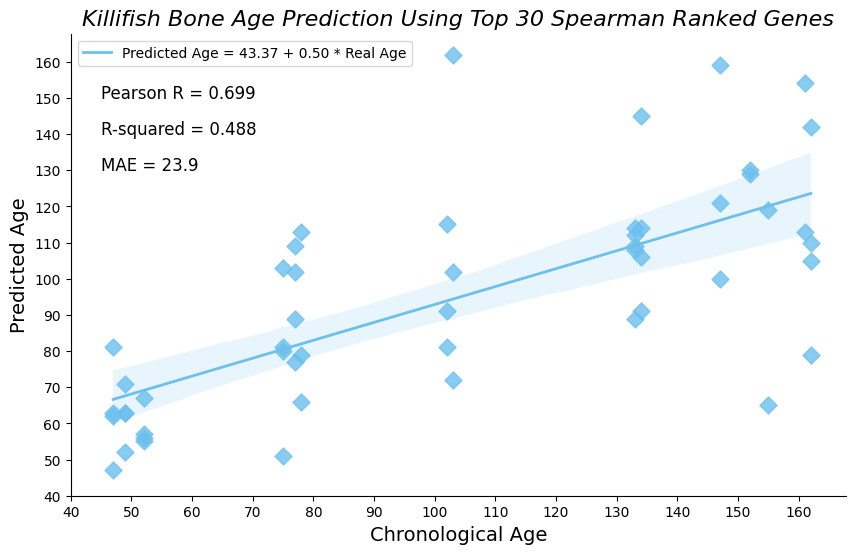

5
     prediction
A1_2       69.0
A2_2      110.0
A3_2       91.0
A4_2      109.0
B1_2       74.0
B2_2      129.0
B4_2      108.0
C1_2      113.0
C2_2       63.0
C3_2      119.0
C4_2       93.0
D1_2      105.0
D2_2       50.0
D3_2       60.0
D4_2       96.0
E1_2       79.0
E2_2       81.0
E3_2      114.0
E4_2      128.0
F1_2       64.0
F2_2       80.0
F3_2      100.0
G1_2       67.0
G2_2      162.0
G3_2       52.0
H1_2       56.0
H2_2      112.0
H3_2       63.0
I1_2       63.0
I2_2      114.0
I3_2      153.0
J1_2      116.0
J2_2      144.0
J3_2      123.0
K1_2      114.0
K2_2       67.0
K3_2      154.0
L1_2       89.0
L2_2      110.0
L3_2      113.0
M1_2      158.0
M2_2      144.0
M3_2       81.0
N1_2       93.0
N2_2       59.0
N3_2       67.0
O1_2      102.0
O2_2      109.0
O3_2      114.0
P2_2      115.0
P3_2       58.0
[51.67429155  0.44959453]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:           

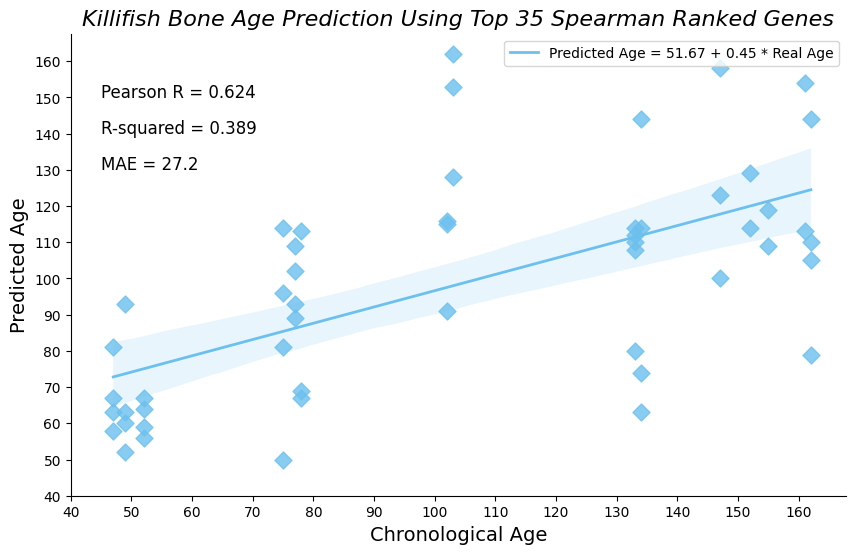

6
     prediction
A1_2       69.0
A2_2      110.0
A3_2       91.0
A4_2      107.0
B1_2       74.0
B2_2      130.0
B4_2      108.0
C1_2      113.0
C2_2       63.0
C3_2      115.0
C4_2       71.0
D1_2      105.0
D2_2       50.0
D3_2       58.0
D4_2       50.0
E1_2       79.0
E2_2       81.0
E3_2      114.0
E4_2      128.0
F1_2       56.0
F2_2      114.0
F3_2      150.0
G1_2       67.0
G2_2      162.0
G3_2       52.0
H1_2       56.0
H2_2      117.0
H3_2       63.0
I1_2       92.0
I2_2      114.0
I3_2      153.0
J1_2      116.0
J2_2       90.0
J3_2      162.0
K1_2       85.0
K2_2       67.0
K3_2      154.0
L1_2       89.0
L2_2      110.0
L3_2      113.0
M1_2      158.0
M2_2      150.0
M3_2       81.0
N1_2       93.0
N2_2       67.0
N3_2       47.0
O1_2      102.0
O2_2      109.0
O3_2      114.0
P2_2      115.0
P3_2       58.0
[43.27062725  0.52799962]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:           

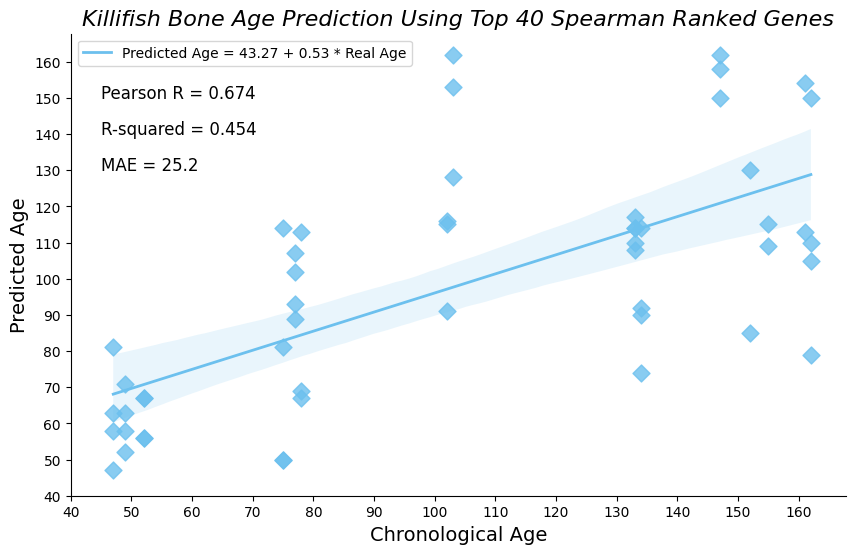

7
     prediction
A1_2       69.0
A2_2      111.0
A3_2       91.0
A4_2      108.0
B1_2       74.0
B2_2      129.0
B4_2      108.0
C1_2      113.0
C2_2       63.0
C3_2      115.0
C4_2       93.0
D1_2      105.0
D2_2       51.0
D3_2       58.0
D4_2       96.0
E1_2       79.0
E2_2       81.0
E3_2      114.0
E4_2      128.0
F1_2       55.0
F2_2      114.0
F3_2      150.0
G1_2       74.0
G2_2      156.0
G3_2       52.0
H1_2       56.0
H2_2      117.0
H3_2       63.0
I1_2      162.0
I2_2      114.0
I3_2      153.0
J1_2       92.0
J2_2       90.0
J3_2      162.0
K1_2       85.0
K2_2       67.0
K3_2      154.0
L1_2       89.0
L2_2      109.0
L3_2      113.0
M1_2      158.0
M2_2      147.0
M3_2       81.0
N1_2       93.0
N2_2       72.0
N3_2       47.0
O1_2      102.0
O2_2      109.0
O3_2      114.0
P2_2      115.0
P3_2       58.0
[46.77330121  0.516315  ]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:           

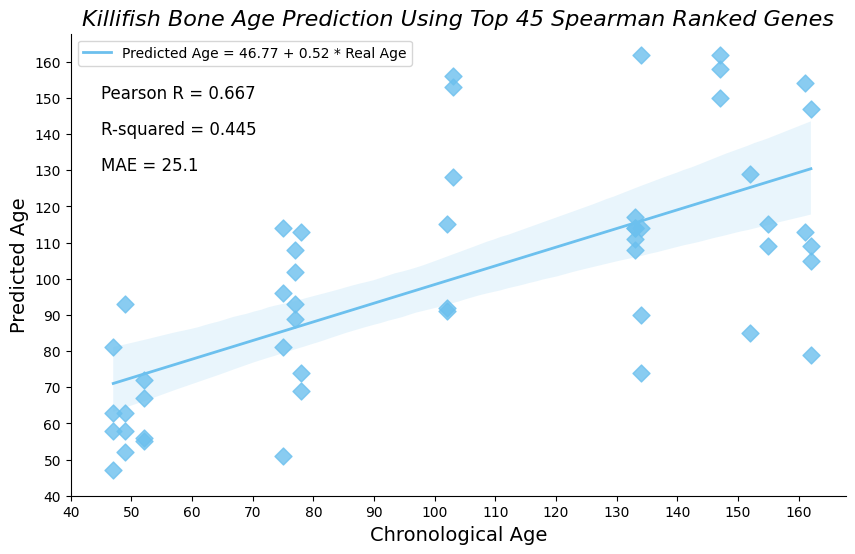

8
     prediction
A1_2      115.0
A2_2      110.0
A3_2       91.0
A4_2      108.0
B1_2       81.0
B2_2      129.0
B4_2      108.0
C1_2      113.0
C2_2       63.0
C3_2      115.0
C4_2       87.0
D1_2      105.0
D2_2       50.0
D3_2       56.0
D4_2       96.0
E1_2       79.0
E2_2       81.0
E3_2      114.0
E4_2      128.0
F1_2       55.0
F2_2       80.0
F3_2      150.0
G1_2       74.0
G2_2      156.0
G3_2       53.0
H1_2       56.0
H2_2      117.0
H3_2      144.0
I1_2      162.0
I2_2      116.0
I3_2      153.0
J1_2       92.0
J2_2       90.0
J3_2      122.0
K1_2       85.0
K2_2       67.0
K3_2      154.0
L1_2       89.0
L2_2      108.0
L3_2      124.0
M1_2      155.0
M2_2      142.0
M3_2       81.0
N1_2       93.0
N2_2       72.0
N3_2       68.0
O1_2      102.0
O2_2      109.0
O3_2      114.0
P2_2      115.0
P3_2       58.0
[58.76572722  0.41477686]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:           

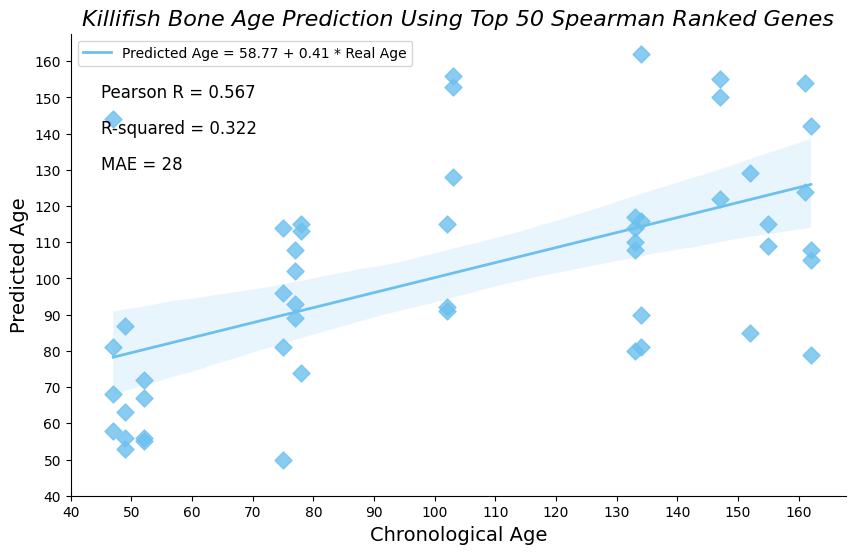

9


In [ ]:
gene_number_test = [10, 15, 20, 25, 30, 35, 40, 45, 50]

counter = 0

for number in gene_number_test:

    gene_number = number

    # Initialize DataFrame for predictions
    bone_predicted_ages = pd.DataFrame(index=bone_df_age.index, columns=["prediction"])

    # Iterate through each sample in the DataFrame
    for sample in bone_df_age.index.tolist():

        # Read the spearman and frequency data for the current sample
        df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/bone/reference/bone_reference_{sample}", sep="\t")
        df_frequency.set_index("Gene", inplace=True)

        # Get top genes based on spearman correlation
        top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
        top_genes = top_absolute_spearman_correlation.index.tolist()
        #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

        total_reads_sample = df_unnorm.loc[sample].sum()

        list_of_profile_probabilities_per_age = []

        # Iterate through each age step
        for age in new_bone_age_steps:

            probability_list_one_age = []
            genes_not_defined = []

            # Iterate through each gene for the sample
            for gene in top_genes:

                gene_frequency = df_frequency.loc[gene, f"{age}"]

                # Replace negative gene frequency with 10^-10
                if gene_frequency < 0:
                    gene_frequency = 10**-10

                sample_expected_counts = gene_frequency * total_reads_sample
                sample_observed_counts = df_unnorm.loc[sample, gene]

                poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

                # Replace NaN poisson probability with a small positive value and log it
                if np.isnan(poisson_probability):
                    poisson_probability = 0.001
                    genes_not_defined.append(gene)

                # Replace zero poisson probability with 0.001
                if poisson_probability == 0:
                    poisson_probability = 0.001

                logP = np.log(poisson_probability)

                probability_list_one_age.append(logP)

            list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

        # transform into dataframe with age steps
        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_bone_age_steps)

        # Compute highest likelihood age among age steps
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

        # Compute highest maximum probability
        max_probability = float(age_probability_df["Pr"].max())

        bone_predicted_ages.loc[sample, "prediction"] = max_probability_age

    # Print the resulting DataFrame
    print(bone_predicted_ages)

    bone_predicted_ages["true_age"] = bone_df_age["age"].tolist()

    bone_df_model = sm.OLS(bone_predicted_ages["prediction"].tolist(), sm.add_constant(bone_predicted_ages["true_age"].tolist()))

    bone_df_results = bone_df_model.fit()

    print(bone_df_results.params)
    print(bone_df_results.summary())

    b, m = bone_df_results.params

    MAE = mae(bone_predicted_ages["true_age"].tolist(), bone_predicted_ages["prediction"].tolist())

    print(MAE)

    bone_correlation_coefficient, bone_p_value = pearsonr(bone_predicted_ages["true_age"].tolist(), bone_predicted_ages["prediction"].tolist())

    bone_correlation_coefficient

    # Ensure the 'age' and 'prediction' columns are numeric
    bone_predicted_ages['age'] = pd.to_numeric(bone_predicted_ages['true_age'], errors='coerce')
    bone_predicted_ages['prediction'] = pd.to_numeric(bone_predicted_ages['prediction'], errors='coerce')

    # Drop rows with NaN values in 'age' or 'prediction' columns
    bone_df_female_predictions = bone_predicted_ages.dropna(subset=['age', 'prediction'])

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(bone_predicted_ages['age'], bone_predicted_ages['prediction'])

    # Calculate Pearson R, R-squared, and MAE
    bone_correlation_coefficient = r_value
    cod = r_value ** 2
    MAE = mae(bone_predicted_ages['age'], bone_predicted_ages['prediction'])

    # Formatting variables to three significant figures
    bone_correlation_coefficient = f"{bone_correlation_coefficient:.3g}"
    cod = f"{cod:.3g}"
    MAE = f"{MAE:.3g}"


    print(f"Performance for Gene Number: {gene_number}")
    print(f"Pearson Correlation: {bone_correlation_coefficient}")
    print(f"Coefficient of Determination: {cod}")
    print(f"Mean Absolute Error: {MAE}")

    counter += 1
    # Plotting the scatter plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.regplot(x="age",
            y="prediction",
            data=bone_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
    sns.despine(right=True)

    x_tick = np.arange(40, 170, 10)
    y_tick = np.arange(40, 170, 10)

    plt.xticks(x_tick)
    plt.yticks(y_tick)

    # Perason Correlation
    plt.text(45, 150, f"Pearson R = {bone_correlation_coefficient}", fontsize=12, color="black")

    #R-squared
    plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

    # Adding MAE text
    plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

    # Changing the names and sizes of x and y-axis labels
    plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
    plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

    # Changing the size of the title
    plt.title(f'Killifish Bone Age Prediction Using Top {gene_number} Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

    # Display the legend
    plt.legend()

    # Save the plot as a publication-ready image (e.g., PNG)
    #plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

    plt.show()

    print(counter)

# Gonad (Testis + Ovary)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/gonad/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
gonad_df = combined_df.loc[combined_df.iloc[:, -2].isin(["Testis", "Ovary"])]

In [ ]:
gonad_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A21_1,32,1959,166,699,148,2517,710,1347,1644,2038,...,4603,3400,607,1119,2209,730,1093,M,Testis,78
A23_1,44,1888,754,376,861,1401,2020,444,1838,810,...,338,2854,744,940,6840,535,2130,F,Ovary,78
A24_1,26,1766,233,540,92,1989,753,1127,1458,1775,...,3175,3323,522,1156,2020,525,813,M,Testis,75
B21_1,24,1246,533,271,596,960,1730,494,1294,461,...,208,1678,540,534,5620,591,1236,F,Ovary,155
B22_1,16,1627,206,558,116,2055,699,975,1659,1709,...,4228,3163,495,989,1844,711,923,M,Testis,133


In [ ]:
age_days_value_counts = gonad_df["age_days"].value_counts().index.tolist()

In [ ]:
gonad_age_steps = sorted(age_days_value_counts)

print(gonad_age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
gonad_gene_expression_data = gonad_df.iloc[:, :-3]

In [ ]:
gonad_df_age = gonad_gene_expression_data.copy()

In [ ]:
gonad_df_age["age"] = gonad_df["age_days"].tolist()

gonad_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A21_1,32,1959,166,699,148,2517,710,1347,1644,2038,...,1175,3764,4603,3400,607,1119,2209,730,1093,78
A23_1,44,1888,754,376,861,1401,2020,444,1838,810,...,177,2191,338,2854,744,940,6840,535,2130,78
A24_1,26,1766,233,540,92,1989,753,1127,1458,1775,...,743,2755,3175,3323,522,1156,2020,525,813,75


In [ ]:
#for sample in gonad_df_age.index.tolist():

#    new_df = gonad_df_age.drop(sample)

#    new_df.to_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/gonad/sample/gonad_sample_{sample}.csv", sep="\t")

#    print(new_df.shape)

In [ ]:
gonad_age_steps = list(np.arange(47, 163, 1))

gonad_age_steps

[47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162]

### Gonad Reference

In [ ]:
#counter = 0

#for sample in gonad_df_age.index.tolist():

#    transcriptome_reference(training_matrix=f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/gonad/sample/gonad_sample_{sample}.csv",
#                            reference_name=f"gonad_reference_{sample}",
#                            output_path="/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/gonad/reference/",
#                            age_prediction="list",
#                            age_list=gonad_age_steps,
#                            min_age=1,
#                            max_age=24,
#                            age_step=1,
#                            tau=0.7)

#    counter += 1

#    print(counter)

### Gonad Age Prediction

In [ ]:
gene_number = 10

In [ ]:
# Initialize DataFrame for predictions
gonad_predicted_ages = pd.DataFrame(index=gonad_df_age.index, columns=["prediction"])

# Iterate through each sample in the DataFrame
for sample in gonad_df_age.index.tolist():

    # Read the spearman and frequency data for the current sample
    #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
    df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/gonad/reference/gonad_reference_{sample}", sep="\t")
    df_frequency.set_index("Gene", inplace=True)

    # Get top genes based on spearman correlation
    top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
    top_genes = top_absolute_spearman_correlation.index.tolist()
    #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

    total_reads_sample = df_unnorm.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    # Iterate through each age step
    for age in gonad_age_steps:

        probability_list_one_age = []
        genes_not_defined = []

        # Iterate through each gene for the sample
        for gene in top_genes:

            gene_frequency = df_frequency.loc[gene, f"{age}"]

            # Replace negative gene frequency with 10^-10
            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_unnorm.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=gonad_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    gonad_predicted_ages.loc[sample, "prediction"] = max_probability_age

# Print the resulting DataFrame
print(gonad_predicted_ages)


      prediction
A21_1       88.0
A23_1       74.0
A24_1      115.0
B21_1       79.0
B22_1      139.0
B23_1      153.0
B24_1       97.0
C21_1      118.0
C23_1      162.0
C24_1      139.0
D21_1       65.0
D23_1      122.0
D24_1      158.0
E21_1      117.0
E23_1      118.0
E24_1      114.0
F23_1       50.0
F24_1       50.0
G21_1       67.0
G23_1       59.0
G24_1      147.0
H21_1      162.0
H23_1      131.0
I21_1       68.0
I22_1      119.0
I23_1      162.0
J21_1      147.0
J22_1       47.0
J23_1       53.0
K21_1      162.0
K22_1      144.0
K23_1      162.0
L22_1       75.0
L23_1      162.0
M21_1       52.0
M22_1       92.0
M23_1       81.0
N21_1       89.0
N22_1      162.0
N23_1       47.0
O21_1       70.0
O22_1       54.0
O23_1       47.0
P21_1      152.0
P22_1       68.0
P23_1      138.0


In [ ]:
gonad_predicted_ages["true_age"] = gonad_df_age["age"].tolist()

In [ ]:
gonad_df_model = sm.OLS(gonad_predicted_ages["prediction"].tolist(), sm.add_constant(gonad_predicted_ages["true_age"].tolist()))

gonad_df_results = gonad_df_model.fit()

print(gonad_df_results.params)
print(gonad_df_results.summary())

[22.00705578  0.80313288]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.657
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     84.40
Date:                Fri, 01 Nov 2024   Prob (F-statistic):           8.54e-12
Time:                        18:44:24   Log-Likelihood:                -211.53
No. Observations:                  46   AIC:                             427.1
Df Residuals:                      44   BIC:                             430.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.0071     

In [ ]:
b, m = gonad_df_results.params

In [ ]:
MAE = mae(gonad_predicted_ages["true_age"].tolist(), gonad_predicted_ages["prediction"].tolist())

print(MAE)

17.67391304347826


In [ ]:
gonad_correlation_coefficient, gonad_p_value = pearsonr(gonad_predicted_ages["true_age"].tolist(), gonad_predicted_ages["prediction"].tolist())

gonad_correlation_coefficient

0.8107591570421382

In [ ]:
cod = gonad_df_results.rsquared

print(cod)

0.6573304107276785


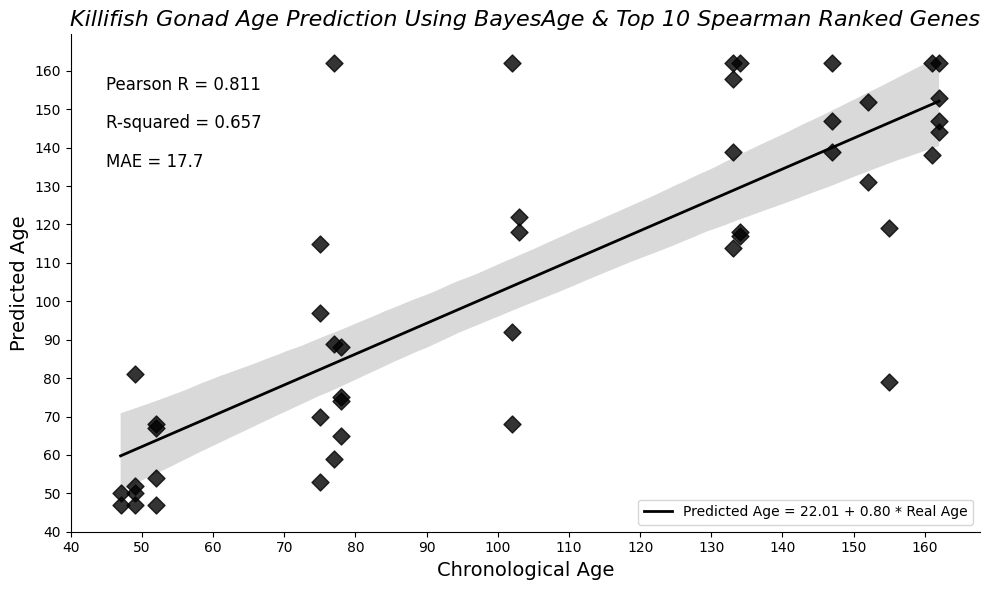

In [ ]:
# Ensure the 'age' and 'prediction' columns are numeric
gonad_predicted_ages['true_age'] = pd.to_numeric(gonad_predicted_ages['true_age'], errors='coerce')
gonad_predicted_ages['prediction'] = pd.to_numeric(gonad_predicted_ages['prediction'], errors='coerce')

# Drop rows with NaN values in 'age' or 'prediction' columns
gonad_predicted_ages = gonad_predicted_ages.dropna(subset=['true_age', 'prediction'])

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(gonad_predicted_ages['true_age'].tolist(), gonad_predicted_ages['prediction'].tolist())

# Calculate Pearson R, R-squared, and MAE
gonad_correlation_coefficient = r_value
cod = r_value ** 2
MAE = mae(gonad_predicted_ages['true_age'], gonad_predicted_ages['prediction'])

# Formatting variables to three significant figures
gonad_correlation_coefficient = f"{gonad_correlation_coefficient:.3g}"
cod = f"{cod:.3g}"
MAE = f"{MAE:.3g}"

# Plotting the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x="true_age",
            y="prediction",
            data=gonad_predicted_ages,
            marker="D",
            color="#010101",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
sns.despine(right=True)

x_tick = np.arange(40, 170, 10)
y_tick = np.arange(40, 170, 10)

plt.xticks(x_tick)
plt.yticks(y_tick)

# Pearson Correlation
plt.text(45, 155, f"Pearson R = {gonad_correlation_coefficient}", fontsize=12, color="black")

# R-squared
plt.text(45, 145, f"R-squared = {cod}", fontsize=12, color="black")

# Adding MAE text
plt.text(45, 135, f'MAE = {MAE}', fontsize=12, color='black')

# Changing the names and sizes of x and y-axis labels
plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

# Changing the size of the title
plt.title('Killifish Gonad Age Prediction Using BayesAge & Top 10 Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

# Display the legend
plt.legend()

plt.tight_layout()

# Save the plot as a publication-ready image (e.g., PNG)
#plt.savefig("/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/killifish_plots/gut_BayesAge_predictions_scatter.svg", dpi=300, bbox_inches="tight")

plt.show()

### Gonad (Testis)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/testis/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
testis_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "Testis"]

testis_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A21_1,32,1959,166,699,148,2517,710,1347,1644,2038,...,4603,3400,607,1119,2209,730,1093,M,Testis,78
A24_1,26,1766,233,540,92,1989,753,1127,1458,1775,...,3175,3323,522,1156,2020,525,813,M,Testis,75
B22_1,16,1627,206,558,116,2055,699,975,1659,1709,...,4228,3163,495,989,1844,711,923,M,Testis,133
B23_1,29,1549,146,668,165,2070,522,1085,1563,1807,...,3888,2673,533,887,1562,519,760,M,Testis,162
C21_1,4,1457,142,468,104,1869,619,937,1343,1510,...,3033,2571,510,942,1500,542,797,M,Testis,134


In [ ]:
testis_age_days_value_counts = testis_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
testis_age_steps = sorted(testis_age_days_value_counts)

print(testis_age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 161, 162]


In [ ]:
testis_gene_expression_data = testis_df_counts.iloc[:, :-3]

In [ ]:
testis_df_age = testis_gene_expression_data.copy()

In [ ]:
testis_df_age["age"] = testis_df_counts["age_days"].tolist()

testis_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A21_1,32,1959,166,699,148,2517,710,1347,1644,2038,...,1175,3764,4603,3400,607,1119,2209,730,1093,78
A24_1,26,1766,233,540,92,1989,753,1127,1458,1775,...,743,2755,3175,3323,522,1156,2020,525,813,75
B22_1,16,1627,206,558,116,2055,699,975,1659,1709,...,874,3451,4228,3163,495,989,1844,711,923,133


In [ ]:
#for sample in testis_df_age.index.tolist():

#    new_df = testis_df_age.drop(sample)

#    new_df.to_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/testis/sample/testis_sample_{sample}.csv", sep="\t")

#    print(new_df.shape)

In [ ]:
new_testis_age_steps = np.arange(min(testis_age_steps), max(testis_age_steps) + 1, 1)

In [ ]:
#counter = 0

#for sample in testis_df_age.index.tolist():

#    transcriptome_reference(training_matrix=f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/testis/sample/testis_sample_{sample}.csv",
#                            reference_name=f"testis_reference_{sample}",
#                            output_path="/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/testis/reference/",
#                            age_prediction="list",
#                            age_list=new_testis_age_steps,
#                            min_age=1,
#                            max_age=24,
#                            age_step=1,
#                            tau=0.7)

#    counter += 1

#    print(counter)

#### Testis Age Prediction

      prediction
A21_1       78.0
A24_1      118.0
B22_1      152.0
B23_1      145.0
C21_1      137.0
C24_1      149.0
D23_1      112.0
D24_1      162.0
E21_1      104.0
E23_1      109.0
E24_1      119.0
F23_1       47.0
G21_1       50.0
G24_1      162.0
H21_1      102.0
H23_1      129.0
I23_1       49.0
J21_1      126.0
J22_1       65.0
K21_1      162.0
K22_1      162.0
K23_1      144.0
L22_1       77.0
L23_1      162.0
M23_1       48.0
N21_1       86.0
N23_1       50.0
O21_1       71.0
O23_1       47.0
P21_1      123.0
P23_1      162.0
[9.9357105  0.90355273]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     159.0
Date:                Fri, 01 Nov 2024   Prob (F-statistic):           2.70e-13
Time:                        18:44:48

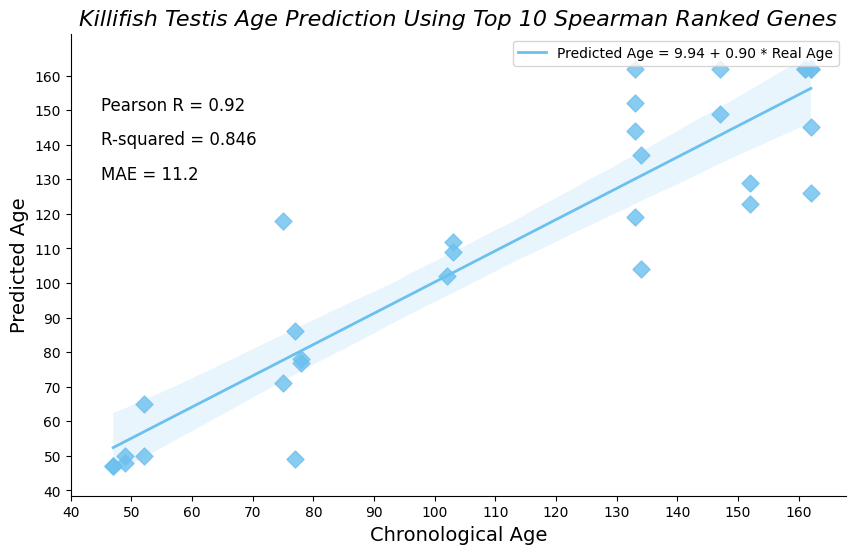

1
      prediction
A21_1       79.0
A24_1      118.0
B22_1      151.0
B23_1      144.0
C21_1      135.0
C24_1      150.0
D23_1      113.0
D24_1      162.0
E21_1      104.0
E23_1      108.0
E24_1      119.0
F23_1       52.0
G21_1       48.0
G24_1      162.0
H21_1      101.0
H23_1      130.0
I23_1       55.0
J21_1      127.0
J22_1       63.0
K21_1      162.0
K22_1      162.0
K23_1      135.0
L22_1       75.0
L23_1      162.0
M23_1       48.0
N21_1       83.0
N23_1       52.0
O21_1       74.0
O23_1       47.0
P21_1      125.0
P23_1      162.0
[10.88551139  0.89468215]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     172.8
Date:                Fri, 01 Nov 2024   Prob (F-statistic):           9.59e-14
Time:                        18:4

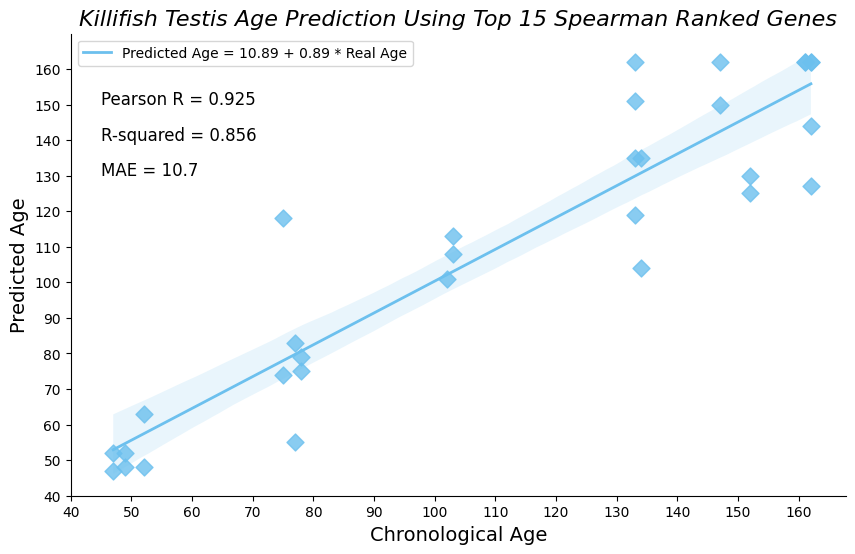

2
      prediction
A21_1       83.0
A24_1      118.0
B22_1      151.0
B23_1      142.0
C21_1      135.0
C24_1      150.0
D23_1      112.0
D24_1      162.0
E21_1      118.0
E23_1      109.0
E24_1      119.0
F23_1       59.0
G21_1       50.0
G24_1      162.0
H21_1      101.0
H23_1      130.0
I23_1      108.0
J21_1      129.0
J22_1       62.0
K21_1      162.0
K22_1      162.0
K23_1      162.0
L22_1       75.0
L23_1      162.0
M23_1       48.0
N21_1       84.0
N23_1       50.0
O21_1       78.0
O23_1       47.0
P21_1      127.0
P23_1      162.0
[17.44261715  0.86779687]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     161.5
Date:                Fri, 01 Nov 2024   Prob (F-statistic):           2.22e-13
Time:                        18:4

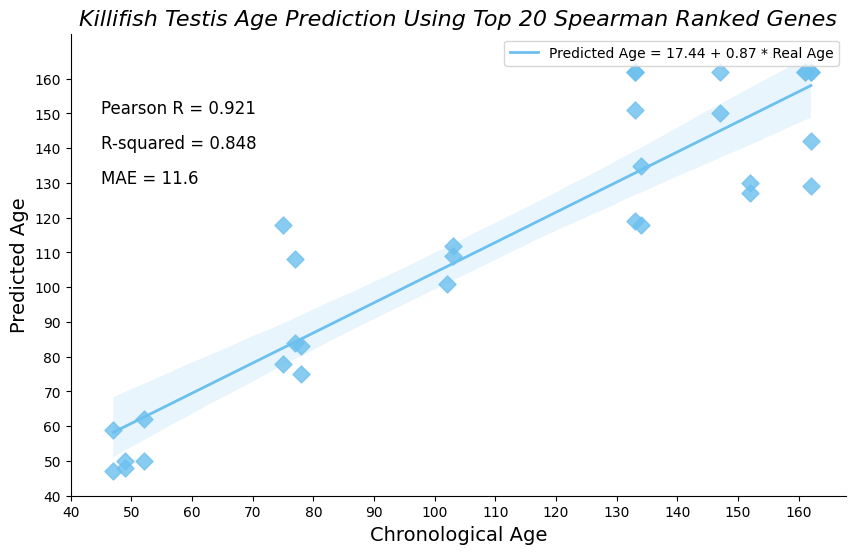

3
      prediction
A21_1       78.0
A24_1      118.0
B22_1      150.0
B23_1      143.0
C21_1      133.0
C24_1      150.0
D23_1      114.0
D24_1      162.0
E21_1      118.0
E23_1      102.0
E24_1      115.0
F23_1       57.0
G21_1       51.0
G24_1      148.0
H21_1      103.0
H23_1      130.0
I23_1      108.0
J21_1      133.0
J22_1       61.0
K21_1      162.0
K22_1      162.0
K23_1      162.0
L22_1       84.0
L23_1      162.0
M23_1       48.0
N21_1       85.0
N23_1       47.0
O21_1       78.0
O23_1       47.0
P21_1      127.0
P23_1      162.0
[17.31844917  0.86338231]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     169.8
Date:                Fri, 01 Nov 2024   Prob (F-statistic):           1.20e-13
Time:                        18:4

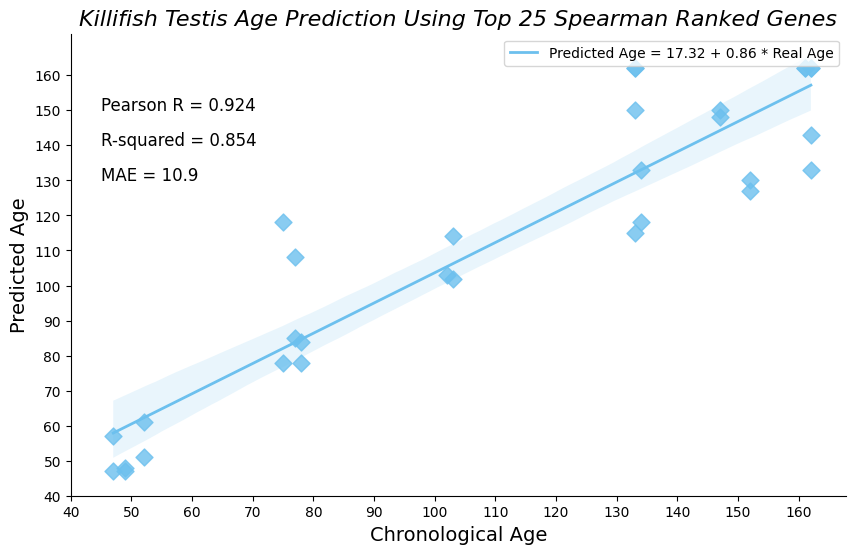

4
      prediction
A21_1       78.0
A24_1      118.0
B22_1      154.0
B23_1      135.0
C21_1      136.0
C24_1      151.0
D23_1      115.0
D24_1      162.0
E21_1      118.0
E23_1      102.0
E24_1      115.0
F23_1       57.0
G21_1       67.0
G24_1      148.0
H21_1      105.0
H23_1      120.0
I23_1      108.0
J21_1      133.0
J22_1       61.0
K21_1      162.0
K22_1      162.0
K23_1      162.0
L22_1       84.0
L23_1      162.0
M23_1       48.0
N21_1       94.0
N23_1       47.0
O21_1       81.0
O23_1       47.0
P21_1      130.0
P23_1      162.0
[21.91088686  0.8288935 ]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     141.5
Date:                Fri, 01 Nov 2024   Prob (F-statistic):           1.12e-12
Time:                        18:4

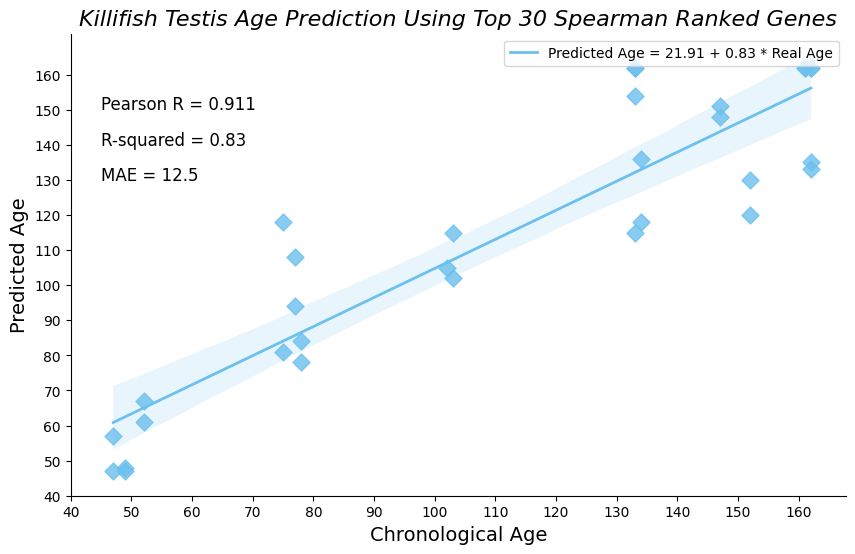

5
      prediction
A21_1       78.0
A24_1      118.0
B22_1      154.0
B23_1      136.0
C21_1      136.0
C24_1      151.0
D23_1      116.0
D24_1      162.0
E21_1      118.0
E23_1      102.0
E24_1      114.0
F23_1       60.0
G21_1       67.0
G24_1      148.0
H21_1      110.0
H23_1      120.0
I23_1      108.0
J21_1      133.0
J22_1       61.0
K21_1      162.0
K22_1      162.0
K23_1      162.0
L22_1       84.0
L23_1      162.0
M23_1       48.0
N21_1       94.0
N23_1       47.0
O21_1       81.0
O23_1       47.0
P21_1      129.0
P23_1      151.0
[23.45572822  0.81406539]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     136.4
Date:                Fri, 01 Nov 2024   Prob (F-statistic):           1.75e-12
Time:                        18:4

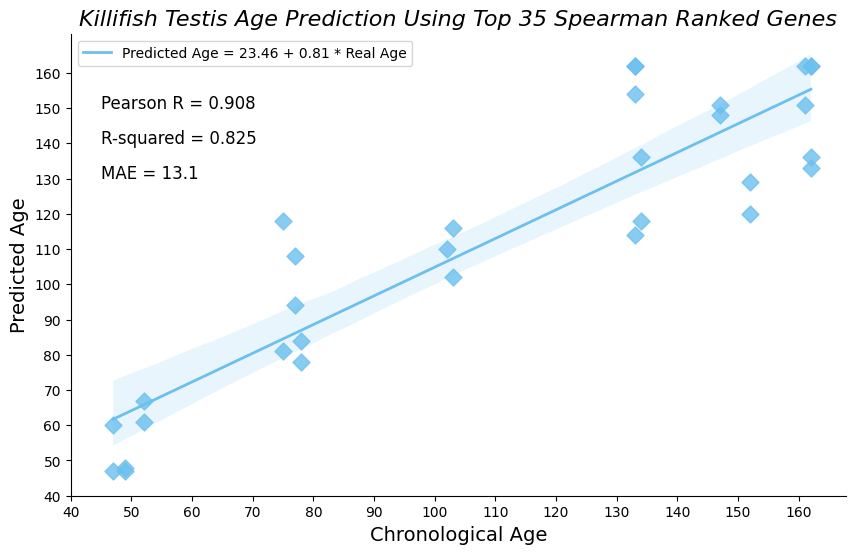

6
      prediction
A21_1       78.0
A24_1      118.0
B22_1      154.0
B23_1      134.0
C21_1      136.0
C24_1      151.0
D23_1      116.0
D24_1      162.0
E21_1      118.0
E23_1      102.0
E24_1      115.0
F23_1       59.0
G21_1       67.0
G24_1      147.0
H21_1      111.0
H23_1      120.0
I23_1      108.0
J21_1      135.0
J22_1       61.0
K21_1      158.0
K22_1      162.0
K23_1      162.0
L22_1       84.0
L23_1      162.0
M23_1       48.0
N21_1       94.0
N23_1       47.0
O21_1       81.0
O23_1       48.0
P21_1      129.0
P23_1      151.0
[23.82199397  0.80988292]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     136.8
Date:                Fri, 01 Nov 2024   Prob (F-statistic):           1.69e-12
Time:                        18:4

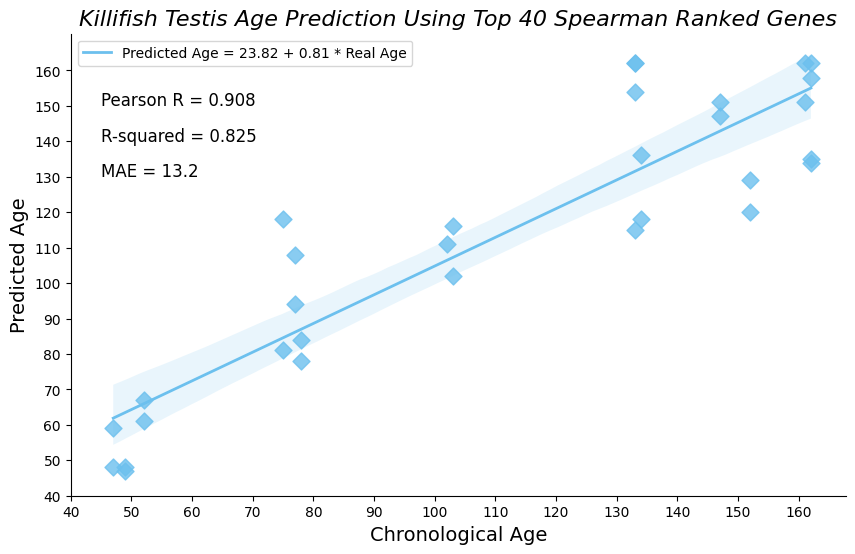

7
      prediction
A21_1       78.0
A24_1      118.0
B22_1      154.0
B23_1      135.0
C21_1      136.0
C24_1      151.0
D23_1      115.0
D24_1      162.0
E21_1      118.0
E23_1      102.0
E24_1      115.0
F23_1       59.0
G21_1       47.0
G24_1      147.0
H21_1      111.0
H23_1      120.0
I23_1      108.0
J21_1      134.0
J22_1       61.0
K21_1      158.0
K22_1      162.0
K23_1      162.0
L22_1       84.0
L23_1      162.0
M23_1       48.0
N21_1       94.0
N23_1       47.0
O21_1       82.0
O23_1       49.0
P21_1      130.0
P23_1      151.0
[20.95780939  0.8305093 ]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     139.4
Date:                Fri, 01 Nov 2024   Prob (F-statistic):           1.34e-12
Time:                        18:4

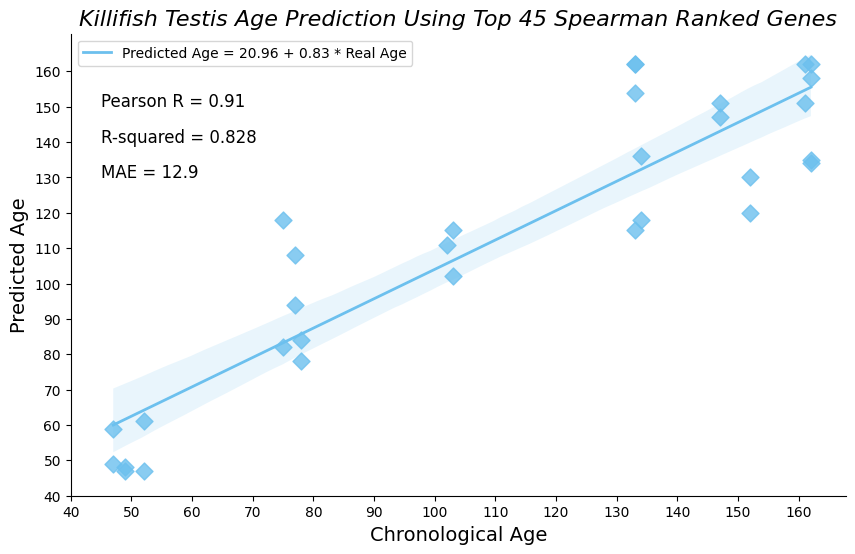

8
      prediction
A21_1       78.0
A24_1      118.0
B22_1      154.0
B23_1      136.0
C21_1      135.0
C24_1      151.0
D23_1      114.0
D24_1      162.0
E21_1      118.0
E23_1      102.0
E24_1      114.0
F23_1       60.0
G21_1       67.0
G24_1      147.0
H21_1      112.0
H23_1      141.0
I23_1      108.0
J21_1      135.0
J22_1       61.0
K21_1      158.0
K22_1      162.0
K23_1      162.0
L22_1       84.0
L23_1      162.0
M23_1       48.0
N21_1       94.0
N23_1       47.0
O21_1       81.0
O23_1       49.0
P21_1      132.0
P23_1      162.0
[21.97496675  0.83705595]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     166.4
Date:                Fri, 01 Nov 2024   Prob (F-statistic):           1.53e-13
Time:                        18:4

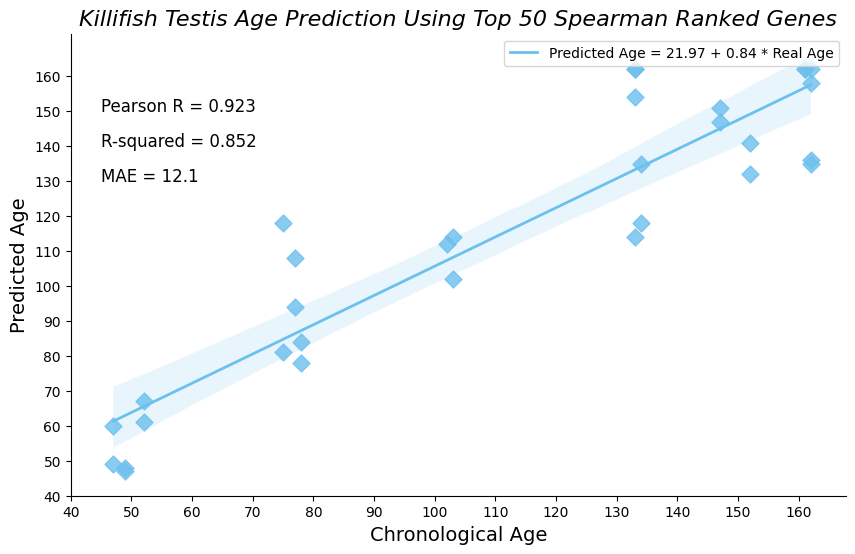

9


In [ ]:
gene_number_test = [10, 15, 20, 25, 30, 35, 40, 45, 50]

counter = 0

for number in gene_number_test:

    gene_number = number

    # Initialize DataFrame for predictions
    testis_predicted_ages = pd.DataFrame(index=testis_df_age.index, columns=["prediction"])

    # Iterate through each sample in the DataFrame
    for sample in testis_df_age.index.tolist():

        # Read the spearman and frequency data for the current sample
        #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
        df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/testis/reference/testis_reference_{sample}", sep="\t")
        df_frequency.set_index("Gene", inplace=True)

        # Get top genes based on spearman correlation
        top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
        top_genes = top_absolute_spearman_correlation.index.tolist()
        #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

        total_reads_sample = df_unnorm.loc[sample].sum()

        list_of_profile_probabilities_per_age = []

        # Iterate through each age step
        for age in new_testis_age_steps:

            probability_list_one_age = []
            genes_not_defined = []

            # Iterate through each gene for the sample
            for gene in top_genes:

                gene_frequency = df_frequency.loc[gene, f"{age}"]

                # Replace negative gene frequency with 10^-10
                if gene_frequency < 0:
                    gene_frequency = 10**-10

                sample_expected_counts = gene_frequency * total_reads_sample
                sample_observed_counts = df_unnorm.loc[sample, gene]

                poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

                # Replace NaN poisson probability with a small positive value and log it
                if np.isnan(poisson_probability):
                    poisson_probability = 0.001
                    genes_not_defined.append(gene)

                # Replace zero poisson probability with 0.001
                if poisson_probability == 0:
                    poisson_probability = 0.001

                logP = np.log(poisson_probability)

                probability_list_one_age.append(logP)

            list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

        # transform into dataframe with age steps
        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_testis_age_steps)

        # Compute highest likelihood age among age steps
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

        # Compute highest maximum probability
        max_probability = float(age_probability_df["Pr"].max())

        testis_predicted_ages.loc[sample, "prediction"] = max_probability_age

    # Print the resulting DataFrame
    print(testis_predicted_ages)

    testis_predicted_ages["true_age"] = testis_df_age["age"].tolist()

    testis_df_model = sm.OLS(testis_predicted_ages["prediction"].tolist(), sm.add_constant(testis_predicted_ages["true_age"].tolist()))

    testis_df_results = testis_df_model.fit()

    print(testis_df_results.params)
    print(testis_df_results.summary())

    b, m = testis_df_results.params

    MAE = mae(testis_predicted_ages["true_age"].tolist(), testis_predicted_ages["prediction"].tolist())

    print(MAE)

    testis_correlation_coefficient, testis_p_value = pearsonr(testis_predicted_ages["true_age"].tolist(), testis_predicted_ages["prediction"].tolist())

    testis_correlation_coefficient

    # Ensure the 'age' and 'prediction' columns are numeric
    testis_predicted_ages['age'] = pd.to_numeric(testis_predicted_ages['true_age'], errors='coerce')
    testis_predicted_ages['prediction'] = pd.to_numeric(testis_predicted_ages['prediction'], errors='coerce')

    # Drop rows with NaN values in 'age' or 'prediction' columns
    testis_df_female_predictions = testis_predicted_ages.dropna(subset=['age', 'prediction'])

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(testis_predicted_ages['age'], testis_predicted_ages['prediction'])

    # Calculate Pearson R, R-squared, and MAE
    testis_correlation_coefficient = r_value
    cod = r_value ** 2
    MAE = mae(testis_predicted_ages['age'], testis_predicted_ages['prediction'])

    # Formatting variables to three significant figures
    testis_correlation_coefficient = f"{testis_correlation_coefficient:.3g}"
    cod = f"{cod:.3g}"
    MAE = f"{MAE:.3g}"


    print(f"Performance for Gene Number: {gene_number}")
    print(f"Pearson Correlation: {testis_correlation_coefficient}")
    print(f"Coefficient of Determination: {cod}")
    print(f"Mean Absolute Error: {MAE}")

    counter += 1
    # Plotting the scatter plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.regplot(x="age",
            y="prediction",
            data=testis_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
    sns.despine(right=True)

    x_tick = np.arange(40, 170, 10)
    y_tick = np.arange(40, 170, 10)

    plt.xticks(x_tick)
    plt.yticks(y_tick)

    # Perason Correlation
    plt.text(45, 150, f"Pearson R = {testis_correlation_coefficient}", fontsize=12, color="black")

    #R-squared
    plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

    # Adding MAE text
    plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

    # Changing the names and sizes of x and y-axis labels
    plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
    plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

    # Changing the size of the title
    plt.title(f'Killifish Testis Age Prediction Using Top {gene_number} Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

    # Display the legend
    plt.legend()

    # Save the plot as a publication-ready image (e.g., PNG)
    #plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

    plt.show()

    print(counter)

### Gonad (Ovary)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/ovary/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
ovary_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "Ovary"]

ovary_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A23_1,44,1888,754,376,861,1401,2020,444,1838,810,...,338,2854,744,940,6840,535,2130,F,Ovary,78
B21_1,24,1246,533,271,596,960,1730,494,1294,461,...,208,1678,540,534,5620,591,1236,F,Ovary,155
B24_1,60,1409,870,362,798,832,2082,454,1429,701,...,265,2659,649,882,7654,793,1928,F,Ovary,75
C23_1,32,1308,516,266,571,1088,1310,457,1350,637,...,283,1837,601,525,4587,485,1304,F,Ovary,147
D21_1,62,1214,749,273,665,1278,1721,288,1846,691,...,325,2138,668,776,6401,543,1485,F,Ovary,78


In [ ]:
ovary_age_days_value_counts = ovary_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
ovary_age_steps = sorted(ovary_age_days_value_counts)

print(ovary_age_steps)

[49, 52, 75, 77, 78, 102, 134, 147, 155]


In [ ]:
ovary_gene_expression_data = ovary_df_counts.iloc[:, :-3]

In [ ]:
ovary_df_age = ovary_gene_expression_data.copy()

In [ ]:
ovary_df_age["age"] = ovary_df_counts["age_days"].tolist()

ovary_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A23_1,44,1888,754,376,861,1401,2020,444,1838,810,...,177,2191,338,2854,744,940,6840,535,2130,78
B21_1,24,1246,533,271,596,960,1730,494,1294,461,...,124,1556,208,1678,540,534,5620,591,1236,155
B24_1,60,1409,870,362,798,832,2082,454,1429,701,...,106,2587,265,2659,649,882,7654,793,1928,75


In [ ]:
#for sample in ovary_df_age.index.tolist():

#    new_df = ovary_df_age.drop(sample)

#    new_df.to_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/ovary/sample/ovary_sample_{sample}.csv", sep="\t")

#    print(new_df.shape)

In [ ]:
new_ovary_age_steps = np.arange(min(ovary_age_steps), max(ovary_age_steps) + 1, 1)

In [ ]:
#counter = 0

#for sample in ovary_df_age.index.tolist():

#    transcriptome_reference(training_matrix=f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/ovary/sample/ovary_sample_{sample}.csv",
#                            reference_name=f"ovary_reference_{sample}",
#                            output_path="/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/ovary/reference/",
#                            age_prediction="list",
#                            age_list=new_ovary_age_steps,
#                            min_age=1,
#                            max_age=24,
#                            age_step=1,
#                            tau=0.7)

#    counter += 1

#    print(counter)

#### Age Prediction

      prediction
A23_1       76.0
B21_1       84.0
B24_1      102.0
C23_1      155.0
D21_1       72.0
F24_1       58.0
G23_1       85.0
I21_1       75.0
I22_1       85.0
J23_1       80.0
M21_1       54.0
M22_1       98.0
N22_1      150.0
O22_1       49.0
P22_1       83.0
[38.63755154  0.52640343]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                     10.72
Date:                Fri, 01 Nov 2024   Prob (F-statistic):            0.00603
Time:                        18:48:37   Log-Likelihood:                -67.441
No. Observations:                  15   AIC:                             138.9
Df Residuals:                      13   BIC:                             140.3
Df Model:                           1                                 

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


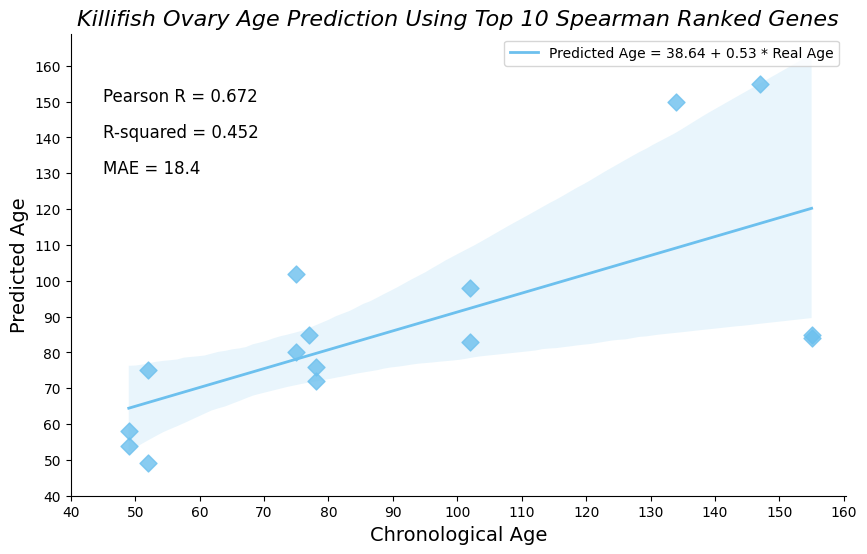

1
      prediction
A23_1       76.0
B21_1       98.0
B24_1      123.0
C23_1      147.0
D21_1       61.0
F24_1       49.0
G23_1       52.0
I21_1       74.0
I22_1       82.0
J23_1       92.0
M21_1       49.0
M22_1       95.0
N22_1      150.0
O22_1       49.0
P22_1       78.0
[32.61864891  0.56936251]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     10.03
Date:                Fri, 01 Nov 2024   Prob (F-statistic):            0.00742
Time:                        18:48:47   Log-Likelihood:                -69.118
No. Observations:                  15   AIC:                             142.2
Df Residuals:                      13   BIC:                             143.7
Df Model:                           1                               

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


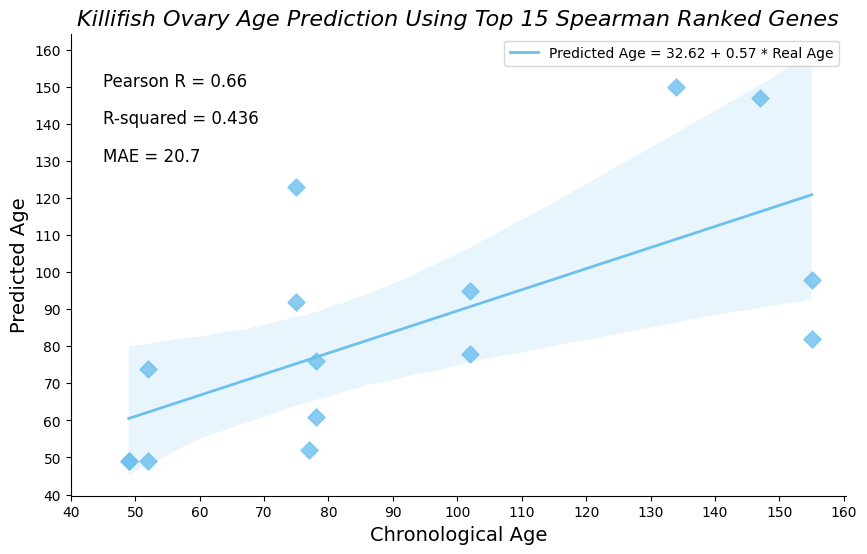

2
      prediction
A23_1       87.0
B21_1       98.0
B24_1      123.0
C23_1      146.0
D21_1       81.0
F24_1       49.0
G23_1       54.0
I21_1       75.0
I22_1       82.0
J23_1       92.0
M21_1       49.0
M22_1       97.0
N22_1      150.0
O22_1       67.0
P22_1       78.0
[41.66235331  0.50946717]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     8.688
Date:                Fri, 01 Nov 2024   Prob (F-statistic):             0.0113
Time:                        18:48:57   Log-Likelihood:                -68.530
No. Observations:                  15   AIC:                             141.1
Df Residuals:                      13   BIC:                             142.5
Df Model:                           1                               

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


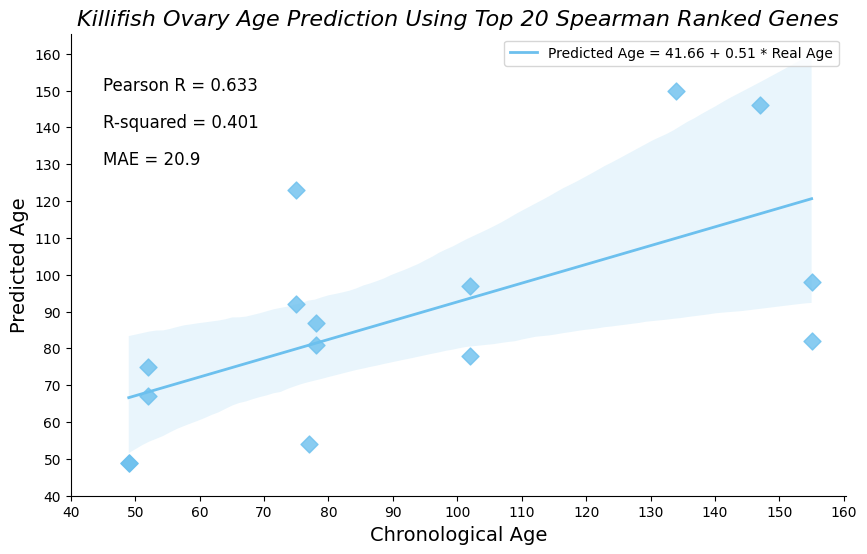

3
      prediction
A23_1       88.0
B21_1       98.0
B24_1      115.0
C23_1      147.0
D21_1       80.0
F24_1       49.0
G23_1       54.0
I21_1       75.0
I22_1       82.0
J23_1       92.0
M21_1       51.0
M22_1       74.0
N22_1      150.0
O22_1       69.0
P22_1       73.0
[40.71176657  0.49733587]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.346
Method:                 Least Squares   F-statistic:                     8.414
Date:                Fri, 01 Nov 2024   Prob (F-statistic):             0.0124
Time:                        18:49:09   Log-Likelihood:                -68.408
No. Observations:                  15   AIC:                             140.8
Df Residuals:                      13   BIC:                             142.2
Df Model:                           1                               

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


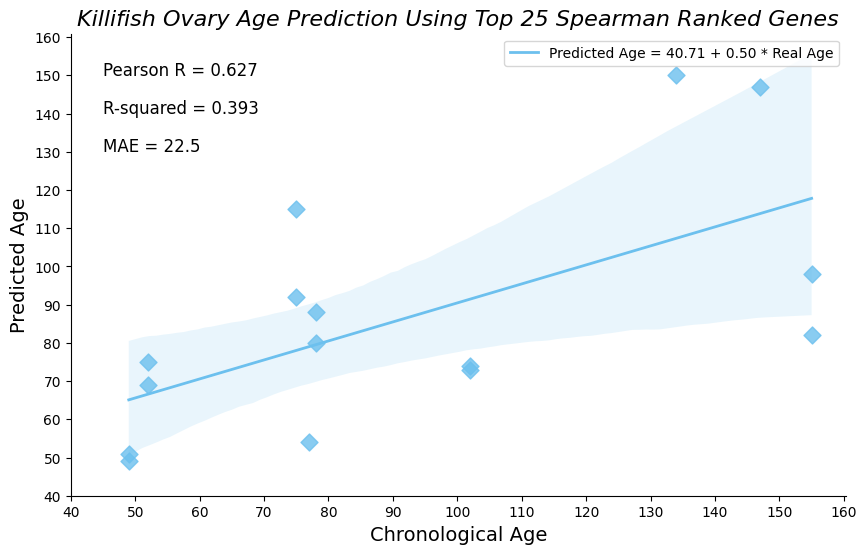

4
      prediction
A23_1       87.0
B21_1       98.0
B24_1      115.0
C23_1      146.0
D21_1       80.0
F24_1       49.0
G23_1       55.0
I21_1       75.0
I22_1       82.0
J23_1       92.0
M21_1       51.0
M22_1       74.0
N22_1      150.0
O22_1       70.0
P22_1       73.0
[41.13193784  0.49276879]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.392
Model:                            OLS   Adj. R-squared:                  0.346
Method:                 Least Squares   F-statistic:                     8.391
Date:                Fri, 01 Nov 2024   Prob (F-statistic):             0.0125
Time:                        18:49:21   Log-Likelihood:                -68.291
No. Observations:                  15   AIC:                             140.6
Df Residuals:                      13   BIC:                             142.0
Df Model:                           1                               

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


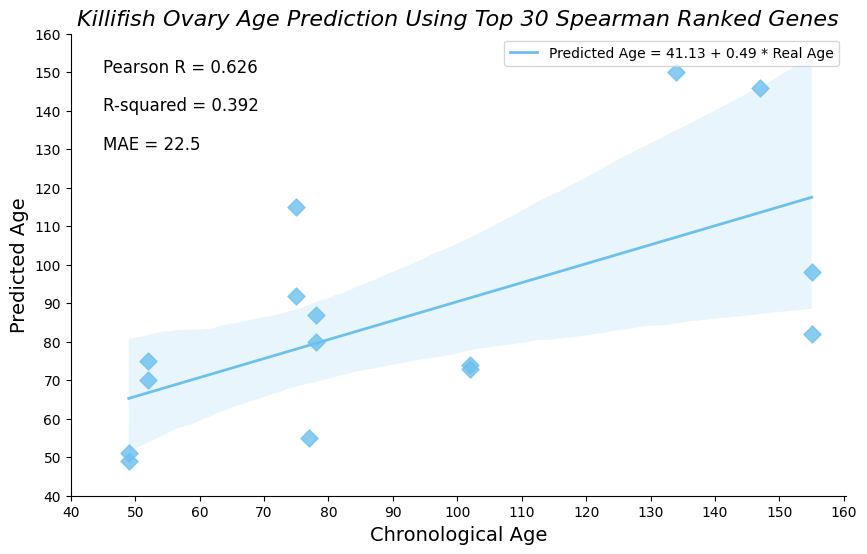

5
      prediction
A23_1       88.0
B21_1       98.0
B24_1      127.0
C23_1      147.0
D21_1       79.0
F24_1       50.0
G23_1       56.0
I21_1       75.0
I22_1       82.0
J23_1       92.0
M21_1       51.0
M22_1       74.0
N22_1      150.0
O22_1       70.0
P22_1       73.0
[43.03793213  0.48292103]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.355
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     7.141
Date:                Fri, 01 Nov 2024   Prob (F-statistic):             0.0192
Time:                        18:49:35   Log-Likelihood:                -69.197
No. Observations:                  15   AIC:                             142.4
Df Residuals:                      13   BIC:                             143.8
Df Model:                           1                               

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


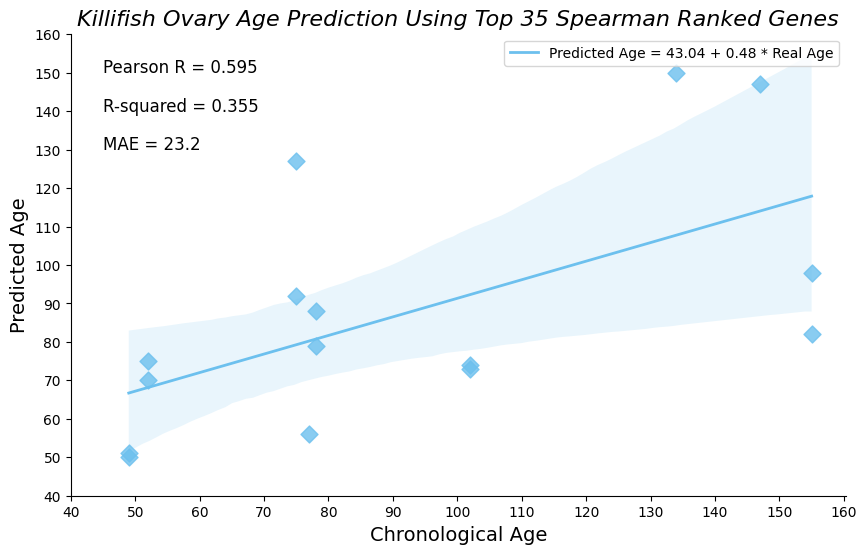

6
      prediction
A23_1       86.0
B21_1       89.0
B24_1      127.0
C23_1      148.0
D21_1       79.0
F24_1       50.0
G23_1       55.0
I21_1       75.0
I22_1       82.0
J23_1       92.0
M21_1       51.0
M22_1       74.0
N22_1      150.0
O22_1       70.0
P22_1       73.0
[44.3573105   0.46060894]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.321
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     6.144
Date:                Fri, 01 Nov 2024   Prob (F-statistic):             0.0277
Time:                        18:49:49   Log-Likelihood:                -69.615
No. Observations:                  15   AIC:                             143.2
Df Residuals:                      13   BIC:                             144.6
Df Model:                           1                               

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


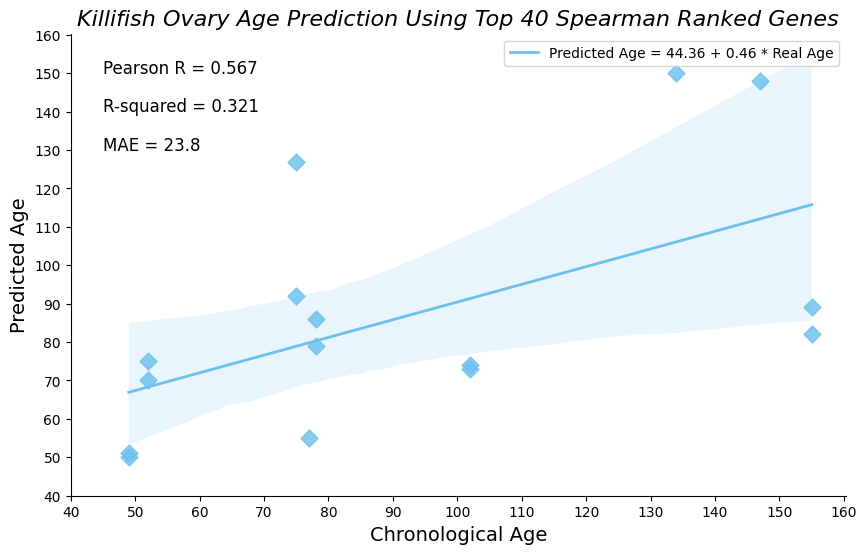

7
      prediction
A23_1       83.0
B21_1       89.0
B24_1      127.0
C23_1      144.0
D21_1       82.0
F24_1       50.0
G23_1       55.0
I21_1       75.0
I22_1      128.0
J23_1       92.0
M21_1       51.0
M22_1       74.0
N22_1      150.0
O22_1       70.0
P22_1       73.0
[35.43628291  0.58801142]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     12.28
Date:                Fri, 01 Nov 2024   Prob (F-statistic):            0.00388
Time:                        18:50:05   Log-Likelihood:                -68.083
No. Observations:                  15   AIC:                             140.2
Df Residuals:                      13   BIC:                             141.6
Df Model:                           1                               

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


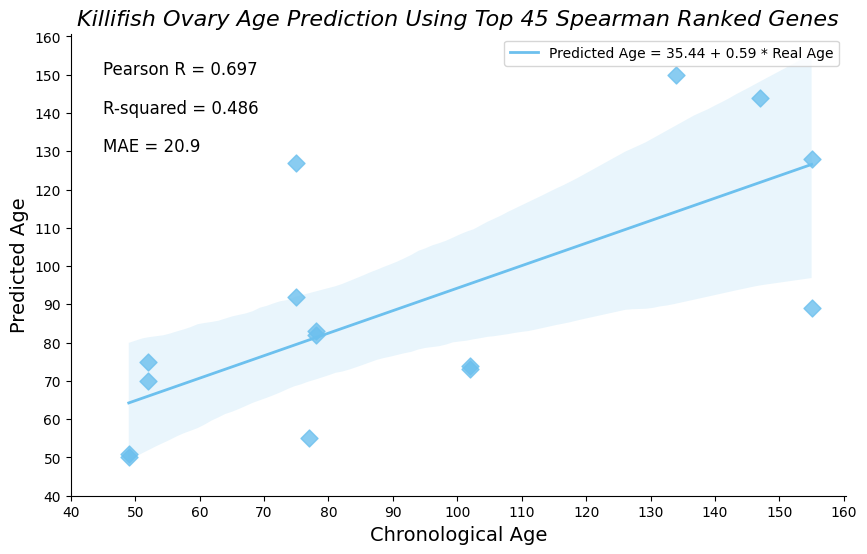

8
      prediction
A23_1       83.0
B21_1       89.0
B24_1      127.0
C23_1      144.0
D21_1       82.0
F24_1       50.0
G23_1       55.0
I21_1       75.0
I22_1      128.0
J23_1       92.0
M21_1       51.0
M22_1      101.0
N22_1      150.0
O22_1       70.0
P22_1       73.0
[36.05455122  0.60085633]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     13.68
Date:                Fri, 01 Nov 2024   Prob (F-statistic):            0.00268
Time:                        18:50:21   Log-Likelihood:                -67.601
No. Observations:                  15   AIC:                             139.2
Df Residuals:                      13   BIC:                             140.6
Df Model:                           1                               

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


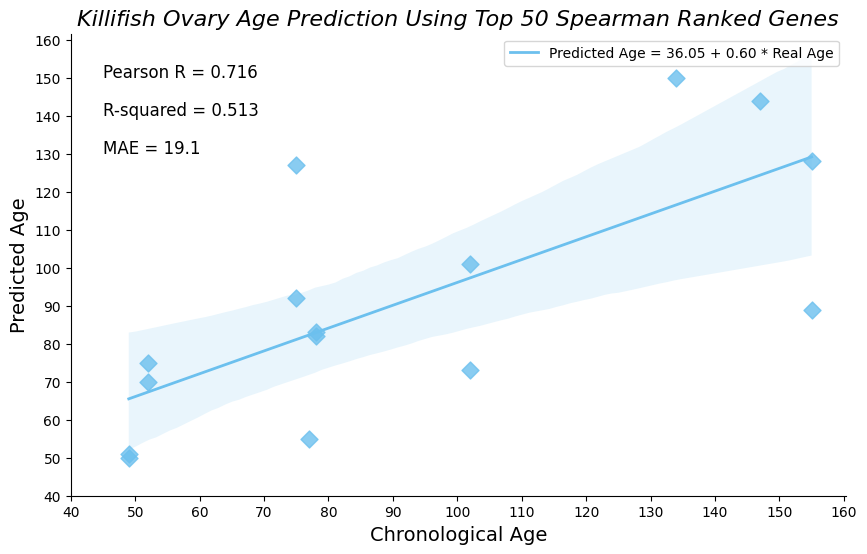

9
      prediction
A23_1       82.0
B21_1       89.0
B24_1      127.0
C23_1      144.0
D21_1       82.0
F24_1       50.0
G23_1       57.0
I21_1       75.0
I22_1       82.0
J23_1       92.0
M21_1       51.0
M22_1      151.0
N22_1      150.0
O22_1       86.0
P22_1       73.0
[50.8212496   0.45556613]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     4.699
Date:                Fri, 01 Nov 2024   Prob (F-statistic):             0.0493
Time:                        18:50:38   Log-Likelihood:                -71.461
No. Observations:                  15   AIC:                             146.9
Df Residuals:                      13   BIC:                             148.3
Df Model:                           1                               

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


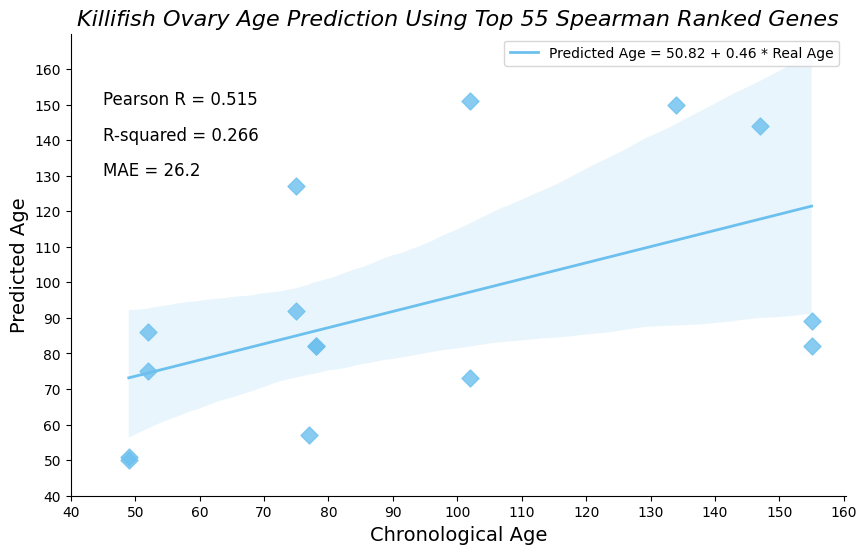

10
      prediction
A23_1       82.0
B21_1       89.0
B24_1      127.0
C23_1      144.0
D21_1       69.0
F24_1       50.0
G23_1       56.0
I21_1       75.0
I22_1       82.0
J23_1       93.0
M21_1       51.0
M22_1      151.0
N22_1      150.0
O22_1       68.0
P22_1       73.0
[44.81547732  0.49838249]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     5.549
Date:                Fri, 01 Nov 2024   Prob (F-statistic):             0.0349
Time:                        18:50:56   Log-Likelihood:                -71.562
No. Observations:                  15   AIC:                             147.1
Df Residuals:                      13   BIC:                             148.5
Df Model:                           1                              

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


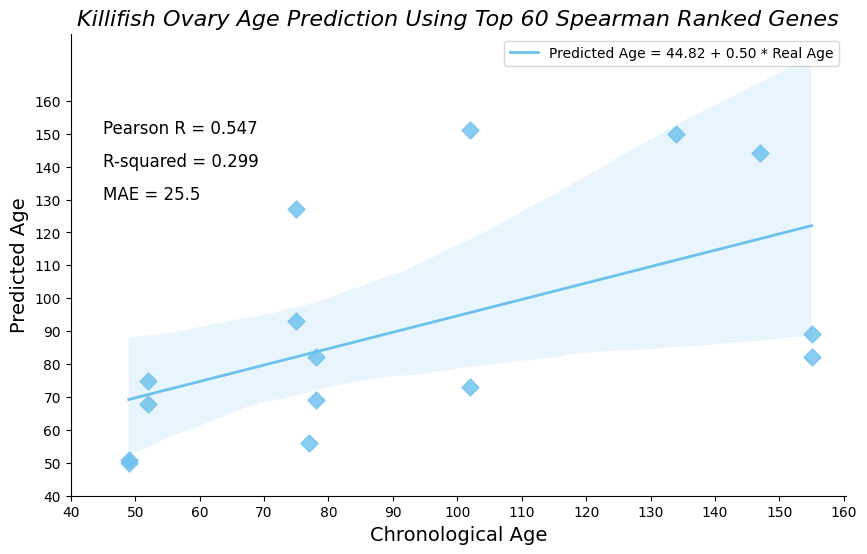

11


In [ ]:
gene_number_test = [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]

counter = 0

for number in gene_number_test:

    gene_number = number

    # Initialize DataFrame for predictions
    ovary_predicted_ages = pd.DataFrame(index=ovary_df_age.index, columns=["prediction"])

    # Iterate through each sample in the DataFrame
    for sample in ovary_df_age.index.tolist():

        # Read the spearman and frequency data for the current sample
        #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
        df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/ovary/reference/ovary_reference_{sample}", sep="\t")
        df_frequency.set_index("Gene", inplace=True)

        # Get top genes based on spearman correlation
        top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
        top_genes = top_absolute_spearman_correlation.index.tolist()
        #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

        total_reads_sample = df_unnorm.loc[sample].sum()

        list_of_profile_probabilities_per_age = []

        # Iterate through each age step
        for age in new_ovary_age_steps:

            probability_list_one_age = []
            genes_not_defined = []

            # Iterate through each gene for the sample
            for gene in top_genes:

                gene_frequency = df_frequency.loc[gene, f"{age}"]

                # Replace negative gene frequency with 10^-10
                if gene_frequency < 0:
                    gene_frequency = 10**-10

                sample_expected_counts = gene_frequency * total_reads_sample
                sample_observed_counts = df_unnorm.loc[sample, gene]

                poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

                # Replace NaN poisson probability with a small positive value and log it
                if np.isnan(poisson_probability):
                    poisson_probability = 0.001
                    genes_not_defined.append(gene)

                # Replace zero poisson probability with 0.001
                if poisson_probability == 0:
                    poisson_probability = 0.001

                logP = np.log(poisson_probability)

                probability_list_one_age.append(logP)

            list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

        # transform into dataframe with age steps
        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_ovary_age_steps)

        # Compute highest likelihood age among age steps
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

        # Compute highest maximum probability
        max_probability = float(age_probability_df["Pr"].max())

        ovary_predicted_ages.loc[sample, "prediction"] = max_probability_age

    # Print the resulting DataFrame
    print(ovary_predicted_ages)

    ovary_predicted_ages["true_age"] = ovary_df_age["age"].tolist()

    ovary_df_model = sm.OLS(ovary_predicted_ages["prediction"].tolist(), sm.add_constant(ovary_predicted_ages["true_age"].tolist()))

    ovary_df_results = ovary_df_model.fit()

    print(ovary_df_results.params)
    print(ovary_df_results.summary())

    b, m = ovary_df_results.params

    MAE = mae(ovary_predicted_ages["true_age"].tolist(), ovary_predicted_ages["prediction"].tolist())

    print(MAE)

    ovary_correlation_coefficient, ovary_p_value = pearsonr(ovary_predicted_ages["true_age"].tolist(), ovary_predicted_ages["prediction"].tolist())

    ovary_correlation_coefficient

    # Ensure the 'age' and 'prediction' columns are numeric
    ovary_predicted_ages['age'] = pd.to_numeric(ovary_predicted_ages['true_age'], errors='coerce')
    ovary_predicted_ages['prediction'] = pd.to_numeric(ovary_predicted_ages['prediction'], errors='coerce')

    # Drop rows with NaN values in 'age' or 'prediction' columns
    ovary_df_female_predictions = ovary_predicted_ages.dropna(subset=['age', 'prediction'])

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(ovary_predicted_ages['age'], ovary_predicted_ages['prediction'])

    # Calculate Pearson R, R-squared, and MAE
    ovary_correlation_coefficient = r_value
    cod = r_value ** 2
    MAE = mae(ovary_predicted_ages['age'], ovary_predicted_ages['prediction'])

    # Formatting variables to three significant figures
    ovary_correlation_coefficient = f"{ovary_correlation_coefficient:.3g}"
    cod = f"{cod:.3g}"
    MAE = f"{MAE:.3g}"


    print(f"Performance for Gene Number: {gene_number}")
    print(f"Pearson Correlation: {ovary_correlation_coefficient}")
    print(f"Coefficient of Determination: {cod}")
    print(f"Mean Absolute Error: {MAE}")

    counter += 1
    # Plotting the scatter plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.regplot(x="age",
            y="prediction",
            data=ovary_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
    sns.despine(right=True)

    x_tick = np.arange(40, 170, 10)
    y_tick = np.arange(40, 170, 10)

    plt.xticks(x_tick)
    plt.yticks(y_tick)

    # Perason Correlation
    plt.text(45, 150, f"Pearson R = {ovary_correlation_coefficient}", fontsize=12, color="black")

    #R-squared
    plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

    # Adding MAE text
    plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

    # Changing the names and sizes of x and y-axis labels
    plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
    plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

    # Changing the size of the title
    plt.title(f'Killifish Ovary Age Prediction Using Top {gene_number} Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

    # Display the legend
    plt.legend()

    # Save the plot as a publication-ready image (e.g., PNG)
    #plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

    plt.show()

    print(counter)

# Liver

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/liver/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
liver_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "Liver"]

liver_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_1,36508,206,3342,296,14,375,356,1593,339,202,...,36,414,0,185,928,108,162,M,Liver,134
A6_1,16717,324,7288,436,30,545,461,617,583,271,...,44,968,116,161,876,297,219,F,Liver,52
A7_1,13509,146,1092,252,36,333,395,486,282,188,...,11,884,0,120,930,170,192,F,Liver,133
A8_1,56721,239,1240,467,30,416,444,1032,402,261,...,52,470,8,229,1014,153,168,M,Liver,133
B5_1,13940,141,1006,154,8,288,292,461,316,172,...,6,558,0,103,648,158,115,F,Liver,102


In [ ]:
liver_age_days_value_counts = liver_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
liver_age_steps = sorted(liver_age_days_value_counts)

print(liver_age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
liver_gene_expression_data = liver_df_counts.iloc[:, :-3]

In [ ]:
liver_df_age = liver_gene_expression_data.copy()

In [ ]:
liver_df_age["age"] = liver_df_counts["age_days"].tolist()

liver_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_1,36508,206,3342,296,14,375,356,1593,339,202,...,25,262,36,414,0,185,928,108,162,134
A6_1,16717,324,7288,436,30,545,461,617,583,271,...,72,383,44,968,116,161,876,297,219,52
A7_1,13509,146,1092,252,36,333,395,486,282,188,...,58,389,11,884,0,120,930,170,192,133


In [ ]:
for sample in liver_df_age.index.tolist():

    new_df = liver_df_age.drop(sample)

    new_df.to_csv(f"./liver_sample_{sample}.csv", sep="\t")

    print(new_df.shape)

(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)


In [ ]:
liver_age_steps = np.arange(47, 163, 1)

In [ ]:
counter = 0

for sample in liver_df_age.index.tolist():

    transcriptome_reference(training_matrix=f"./liver_sample_{sample}.csv",
                            reference_name=f"liver_reference_{sample}",
                            output_path="./",
                            age_prediction="list",
                            age_list=liver_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

    counter += 1

    print(counter)

<ipython-input-4-63f1e9a106d4>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './liver_reference_A5_1'
Report file generated at './liver_reference_A5_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 161.066 seconds

The reference is constructed and saved!
1


<ipython-input-4-63f1e9a106d4>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './liver_reference_A6_1'
Report file generated at './liver_reference_A6_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 155.783 seconds

The reference is constructed and saved!
2


<ipython-input-4-63f1e9a106d4>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)


...


Reference model dataset written to './liver_reference_P5_1'
Report file generated at './liver_reference_P5_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 154.430 seconds

The reference is constructed and saved!
52


<ipython-input-4-63f1e9a106d4>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './liver_reference_P6_1'
Report file generated at './liver_reference_P6_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 153.964 seconds

The reference is constructed and saved!
53


<ipython-input-4-63f1e9a106d4>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './liver_reference_P7_1'
Report file generated at './liver_reference_P7_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 152.719 seconds

The reference is constructed and saved!
54


### Liver Age Prediction

In [ ]:
liver_age_steps

array([ 47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,
        60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,
        73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,
        86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,
        99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
       112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124,
       125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137,
       138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150,
       151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162])

In [ ]:
gene_number = 25

In [ ]:
# Initialize DataFrame for predictions
liver_predicted_ages = pd.DataFrame(index=liver_df_age.index, columns=["prediction"])

# Iterate through each sample in the DataFrame
for sample in liver_df_age.index.tolist():

    # Read the spearman and frequency data for the current sample
    #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
    df_frequency= pd.read_csv(f"./liver_reference_{sample}", sep="\t")
    df_frequency.set_index("Gene", inplace=True)

    # Get top genes based on spearman correlation
    top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
    top_genes = top_absolute_spearman_correlation.index.tolist()
    #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

    total_reads_sample = df_unnorm.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    # Iterate through each age step
    for age in liver_age_steps:

        probability_list_one_age = []
        genes_not_defined = []

        # Iterate through each gene for the sample
        for gene in top_genes:

            gene_frequency = df_frequency.loc[gene, f"{age}"]

            # Replace negative gene frequency with 10^-10
            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_unnorm.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=liver_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    liver_predicted_ages.loc[sample, "prediction"] = max_probability_age

# Print the resulting DataFrame
print(liver_predicted_ages)

     prediction
A5_1      156.0
A6_1       49.0
A7_1       88.0
A8_1      162.0
B5_1       79.0
B6_1      102.0
B7_1      162.0
B8_1      103.0
C5_1      151.0
C6_1       51.0
C7_1      154.0
C8_1      162.0
D5_1      150.0
D6_1      160.0
D7_1       92.0
D8_1      132.0
E5_1      113.0
E6_1      125.0
E7_1      162.0
E8_1      125.0
F5_1       54.0
F6_1      110.0
F7_1      162.0
F8_1      162.0
G5_1      108.0
G6_1       77.0
G7_1       56.0
G8_1      162.0
H5_1      104.0
H6_1       68.0
H7_1       54.0
I5_1       93.0
I6_1       48.0
I7_1       47.0
J5_1      108.0
J7_1       86.0
K5_1      131.0
K6_1       66.0
K7_1       79.0
L5_1       84.0
L6_1       69.0
L7_1      106.0
M5_1       97.0
M6_1       73.0
M7_1       57.0
N5_1       84.0
N6_1      152.0
N7_1       86.0
O5_1       60.0
O6_1      148.0
O7_1       87.0
P5_1      162.0
P6_1       92.0
P7_1      155.0


In [ ]:
liver_predicted_ages["true_age"] = liver_df_age["age"].tolist()

In [ ]:
liver_df_model = sm.OLS(liver_predicted_ages["prediction"].tolist(), sm.add_constant(liver_predicted_ages["true_age"].tolist()))

liver_df_results = liver_df_model.fit()

print(liver_df_results.params)
print(liver_df_results.summary())

[32.09730644  0.70906533]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.531
Method:                 Least Squares   F-statistic:                     61.01
Date:                Tue, 05 Nov 2024   Prob (F-statistic):           2.53e-10
Time:                        17:42:25   Log-Likelihood:                -253.31
No. Observations:                  54   AIC:                             510.6
Df Residuals:                      52   BIC:                             514.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         32.0973     

In [ ]:
# Save the regression results to a text file
#output_path = './model_performance/'
#gene_num = "".join([str(gene_number), "genes"])
#out_file_prefix = 'liver_combined_regression_res'
#out_file_name = "_".join([out_file_prefix, gene_num])
#liver_df_results.summary.as_text(os.path.join(output_path, out_file_name))

# Print the summary to a text file
#with open("model_summary.txt", "w") as f:
#    f.write(liver_df_results.summary().as_text())

AttributeError: 'function' object has no attribute 'as_text'

In [ ]:
b, m = liver_df_results.params

In [ ]:
MAE = mae(liver_predicted_ages["true_age"].tolist(), liver_predicted_ages["prediction"].tolist())

print(MAE)

21.87037037037037


In [ ]:
liver_correlation_coefficient, liver_p_value = pearsonr(liver_predicted_ages["true_age"].tolist(), liver_predicted_ages["prediction"].tolist())

liver_correlation_coefficient

0.7347662281404248

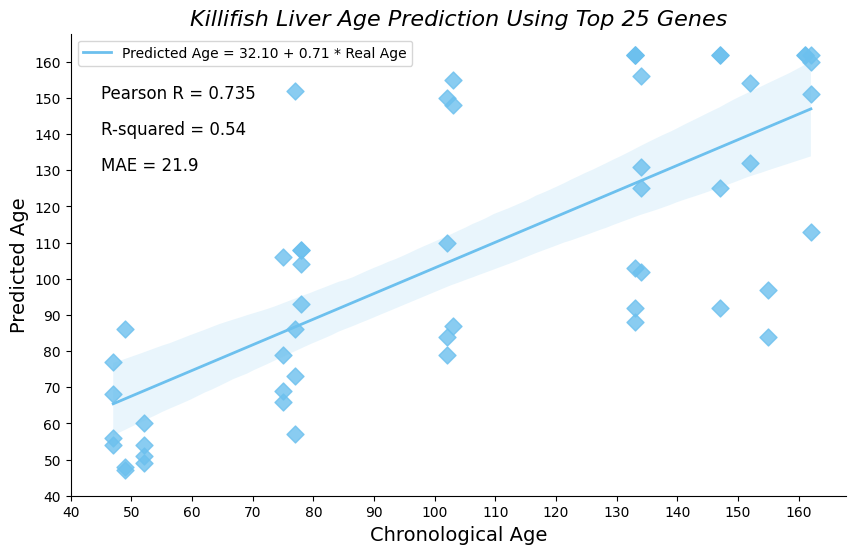

In [ ]:
# Ensure the 'age' and 'prediction' columns are numeric
liver_predicted_ages['age'] = pd.to_numeric(liver_predicted_ages['true_age'], errors='coerce')
liver_predicted_ages['prediction'] = pd.to_numeric(liver_predicted_ages['prediction'], errors='coerce')

# Drop rows with NaN values in 'age' or 'prediction' columns
liver_df_female_predictions = liver_predicted_ages.dropna(subset=['age', 'prediction'])

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(liver_predicted_ages['age'], liver_predicted_ages['prediction'])

# Calculate Pearson R, R-squared, and MAE
liver_correlation_coefficient = r_value
cod = r_value ** 2
MAE = mae(liver_predicted_ages['age'], liver_predicted_ages['prediction'])

# Formatting variables to three significant figures
liver_correlation_coefficient = f"{liver_correlation_coefficient:.3g}"
cod = f"{cod:.3g}"
MAE = f"{MAE:.3g}"

# Plotting the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x="age",
            y="prediction",
            data=liver_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
sns.despine(right=True)

x_tick = np.arange(40, 170, 10)
y_tick = np.arange(40, 170, 10)

plt.xticks(x_tick)
plt.yticks(y_tick)

# Perason Correlation
plt.text(45, 150, f"Pearson R = {liver_correlation_coefficient}", fontsize=12, color="black")

#R-squared
plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

# Adding MAE text
plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

# Changing the names and sizes of x and y-axis labels
plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

# Changing the size of the title
#plt.title('Killifish Liver Age Prediction Using Top 20 Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed
plt.title("".join(['Killifish Liver Age Prediction Using Top ', str(gene_number), ' Genes']), fontsize=16, fontstyle="italic")

# Display the legend
plt.legend()

# Save the plot as a publication-ready image (e.g., PNG)
#plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

plt.savefig("".join(["./plots/killifish_liver_combined_scatter_plot_top_",str(gene_number),"_genes.svg"]), dpi=300, bbox_inches="tight")

plt.show()

### Female

In [ ]:
liver_df_female = liver_df_counts.loc[liver_df_counts.iloc[:,-3] == "F"]

liver_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A6_1,16717,324,7288,436,30,545,461,617,583,271,...,44,968,116,161,876,297,219,F,Liver,52
A7_1,13509,146,1092,252,36,333,395,486,282,188,...,11,884,0,120,930,170,192,F,Liver,133
B5_1,13940,141,1006,154,8,288,292,461,316,172,...,6,558,0,103,648,158,115,F,Liver,102
B6_1,11838,99,783,134,16,251,210,353,172,166,...,8,702,0,110,425,114,123,F,Liver,134
B8_1,11255,74,917,136,12,150,200,246,202,120,...,16,395,6,95,252,82,93,F,Liver,133


In [ ]:
age_days_value_counts_female = liver_df_female["age_days"].value_counts().index.tolist()

In [ ]:
liver_age_steps_female = sorted(age_days_value_counts_female)

In [ ]:
liver_gene_expression_data_female = liver_df_female.iloc[:,:-3]

In [ ]:
liver_df_female_age = liver_gene_expression_data_female.copy()

In [ ]:
#brain_df_female["age_days"] = pd.to_numeric(brain_df_female["age_days"], errors='coerce')
liver_df_female_age["age"] = liver_df_female["age_days"].tolist()

In [ ]:
for sample in liver_df_female_age.index.tolist():

    new_df = liver_df_female_age.drop(sample)

    new_df.to_csv(f"./liver_female_{sample}.csv", sep="\t")

    print(new_df)

    print(new_df.shape)

       a1cf  aaas  aacs  aadat  aaed1  aagab  aak1  aamdc  aamp  aar2  ...  \
A7_1  13509   146  1092    252     36    333   395    486   282   188  ...   
B5_1  13940   141  1006    154      8    288   292    461   316   172  ...   
B6_1  11838    99   783    134     16    251   210    353   172   166  ...   
B8_1  11255    74   917    136     12    150   200    246   202   120  ...   
C6_1  14809   264  6110    186     16    322   330    428   490   211  ...   
D7_1  17436   143  4071    205     18    240   304    483   207   123  ...   
E6_1  22699   214  2429    258     50    340   333    466   437   216  ...   
E8_1  14277   121   863    204     14    304   335    427   246   176  ...   
G5_1  12561   178  2093    159     18    313   305    348   286   151  ...   
G6_1  12629   119   725    148      6    265   326    342   295   177  ...   
G7_1  10401   150   665    158     34    180   244    361   324   155  ...   
I5_1  10663    95  1416    120     16    306   277    315   285 

In [ ]:
liver_age_steps_female = list(np.arange(47, 156, 1))

In [ ]:
liver_age_steps_female

[47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155]

#### Reference Generation

In [ ]:
counter = 0

for sample in liver_df_female_age.index.tolist():

    transcriptome_reference(training_matrix=f"./liver_female_{sample}.csv",
                            reference_name=f"liver_reference_female_{sample}",
                            output_path="./",
                            age_prediction="list",
                            age_list=liver_age_steps_female,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

    counter += 1

    print(counter)

<ipython-input-7-2d9ce31a41d1>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './liver_reference_female_A6_1'
Report file generated at './liver_reference_female_A6_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 135.222 seconds

The reference is constructed and saved!
1


<ipython-input-7-2d9ce31a41d1>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './liver_reference_female_A7_1'
Report file generated at './liver_reference_female_A7_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 131.675 seconds

The reference is constructed and saved!
2


<ipython-input-7-2d9ce31a41d1>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)


...


Reference model dataset written to './liver_reference_female_M7_1'
Report file generated at './liver_reference_female_M7_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 131.389 seconds

The reference is constructed and saved!
21


<ipython-input-7-2d9ce31a41d1>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './liver_reference_female_N5_1'
Report file generated at './liver_reference_female_N5_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 130.645 seconds

The reference is constructed and saved!
22


<ipython-input-7-2d9ce31a41d1>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './liver_reference_female_O7_1'
Report file generated at './liver_reference_female_O7_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 127.469 seconds

The reference is constructed and saved!
23


#### Liver Female Age Prediction

In [ ]:
gene_number = 10

In [ ]:
# Initialize DataFrame for predictions
liver_female_predicted_ages = pd.DataFrame(index=liver_df_female_age.index, columns=["prediction"])

# Iterate through each sample in the DataFrame
for sample in liver_df_female_age.index.tolist():

    # Read the spearman and frequency data for the current sample
    #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
    df_frequency= pd.read_csv(f"./liver_reference_female_{sample}", sep="\t")
    df_frequency.set_index("Gene", inplace=True)

    # Get top genes based on spearman correlation
    top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
    top_genes = top_absolute_spearman_correlation.index.tolist()
    #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

    total_reads_sample = df_unnorm.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    # Iterate through each age step
    for age in liver_age_steps_female:

        probability_list_one_age = []
        genes_not_defined = []

        # Iterate through each gene for the sample
        for gene in top_genes:

            gene_frequency = df_frequency.loc[gene, f"{age}"]

            # Replace negative gene frequency with 10^-10
            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_unnorm.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=liver_age_steps_female)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    liver_female_predicted_ages.loc[sample, "prediction"] = max_probability_age

# Print the resulting DataFrame
print(liver_female_predicted_ages)


     prediction
A6_1       49.0
A7_1       92.0
B5_1      105.0
B6_1      121.0
B8_1       91.0
C6_1       51.0
D7_1      142.0
E6_1      155.0
E8_1      147.0
G5_1       88.0
G6_1       59.0
G7_1       77.0
I5_1       80.0
I6_1       47.0
I7_1       49.0
K6_1       64.0
K7_1       98.0
L5_1      151.0
M5_1      139.0
M6_1       68.0
M7_1       52.0
N5_1      147.0
O7_1      135.0


In [ ]:
liver_female_predicted_ages["true_age"] = liver_df_female_age["age"].tolist()

In [ ]:
liver_female_df_model = sm.OLS(liver_female_predicted_ages["prediction"].tolist(), sm.add_constant(liver_female_predicted_ages["true_age"].tolist()))

liver_female_df_results = liver_female_df_model.fit()

print(liver_female_df_results.params)
print(liver_female_df_results.summary())

[15.50804115  0.84067017]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     54.34
Date:                Tue, 05 Nov 2024   Prob (F-statistic):           2.98e-07
Time:                        19:39:53   Log-Likelihood:                -101.39
No. Observations:                  23   AIC:                             206.8
Df Residuals:                      21   BIC:                             209.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.5080     

In [ ]:
b, m = liver_female_df_results.params

In [ ]:
MAE = mae(liver_female_predicted_ages["true_age"].tolist(), liver_female_predicted_ages["prediction"].tolist())

print(MAE)

15.217391304347826


In [ ]:
liver_female_correlation_coefficient, liver_female_p_value = pearsonr(liver_female_predicted_ages["true_age"].tolist(), liver_female_predicted_ages["prediction"].tolist())

liver_female_correlation_coefficient

0.8492683894023025

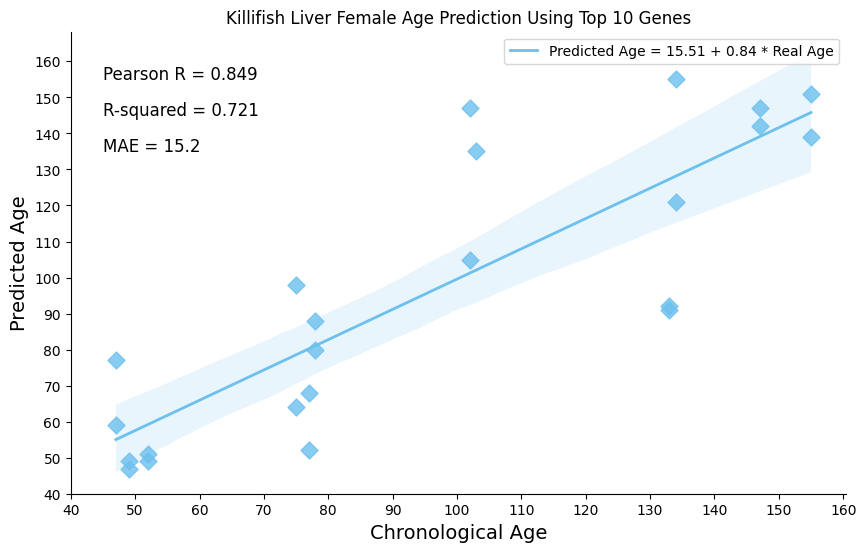

In [ ]:
# Ensure the 'age' and 'prediction' columns are numeric
liver_female_predicted_ages['age'] = pd.to_numeric(liver_female_predicted_ages['true_age'], errors='coerce')
liver_female_predicted_ages['prediction'] = pd.to_numeric(liver_female_predicted_ages['prediction'], errors='coerce')

# Drop rows with NaN values in 'age' or 'prediction' columns
liver_df_female_predictions = liver_female_predicted_ages.dropna(subset=['age', 'prediction'])

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(liver_female_predicted_ages['age'], liver_female_predicted_ages['prediction'])

# Calculate Pearson R, R-squared, and MAE
liver_correlation_coefficient = r_value
cod = r_value ** 2
MAE = mae(liver_female_predicted_ages['age'], liver_female_predicted_ages['prediction'])

# Formatting variables to three significant figures
liver_correlation_coefficient = f"{liver_correlation_coefficient:.3g}"
cod = f"{cod:.3g}"
MAE = f"{MAE:.3g}"

# Plotting the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x="age",
            y="prediction",
            data=liver_female_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
sns.despine(right=True)

x_tick = np.arange(40, 170, 10)
y_tick = np.arange(40, 170, 10)

plt.xticks(x_tick)
plt.yticks(y_tick)

# Perason Correlation
plt.text(45, 155, f"Pearson R = {liver_correlation_coefficient}", fontsize=12, color="black")

#R-squared
plt.text(45, 145, f"R-squared = {cod}", fontsize=12, color="black")

# Adding MAE text
plt.text(45, 135, f'MAE = {MAE}', fontsize=12, color='black')

# Changing the names and sizes of x and y-axis labels
plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

# Changing the size of the title
#plt.title('Killifish Liver Female Age Prediction Using Top 10 Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed
plt.title("".join(['Killifish Liver Female Age Prediction Using Top ', str(gene_number), ' Genes']))

# Display the legend
plt.legend()

# Save the plot as a publication-ready image (e.g., PNG)
#plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_female_scatter_plot_top_10_genes.svg', dpi=300, bbox_inches='tight')
plt.savefig("".join(["./plots/killifish_liver_female_scatter_plot_top_",str(gene_number),"_genes.svg"]), dpi=300, bbox_inches="tight")

plt.show()

### Liver Male Age Prediction

In [ ]:
liver_df_male = liver_df_counts.loc[liver_df_counts.iloc[:,-3] == "M"]

liver_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_1,36508,206,3342,296,14,375,356,1593,339,202,...,36,414,0,185,928,108,162,M,Liver,134
A8_1,56721,239,1240,467,30,416,444,1032,402,261,...,52,470,8,229,1014,153,168,M,Liver,133
B7_1,46082,190,5874,288,30,465,555,1129,332,306,...,14,576,2,235,1049,250,243,M,Liver,133
C5_1,41639,254,8813,231,22,423,336,1167,313,270,...,60,422,8,174,852,86,159,M,Liver,162
C7_1,46991,267,3752,349,38,556,637,1162,378,377,...,76,327,6,223,1268,156,190,M,Liver,152


In [ ]:
age_days_value_counts_male = liver_df_male["age_days"].value_counts().index.tolist()

age_days_value_counts_male

[133, 162, 134, 152, 102, 147, 52, 161, 78, 47, 75, 77, 103, 49]

In [ ]:
liver_age_steps_male = sorted(age_days_value_counts_male)

In [ ]:
liver_age_steps_male

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 161, 162]

In [ ]:
liver_gene_expression_data_male = liver_df_male.iloc[:,:-3]

In [ ]:
liver_df_male_age = liver_gene_expression_data_male.copy()

In [ ]:
liver_df_male_age["age"] = liver_df_male["age_days"].tolist()

In [ ]:
for sample in liver_df_male_age.index.tolist():

    new_df = liver_df_male_age.drop(sample)

    new_df.to_csv(f"./liver_male_{sample}.csv", sep="\t")

    print(new_df)

    print(new_df.shape)

       a1cf  aaas   aacs  aadat  aaed1  aagab  aak1  aamdc  aamp  aar2  ...  \
A8_1  56721   239   1240    467     30    416   444   1032   402   261  ...   
B7_1  46082   190   5874    288     30    465   555   1129   332   306  ...   
C5_1  41639   254   8813    231     22    423   336   1167   313   270  ...   
C7_1  46991   267   3752    349     38    556   637   1162   378   377  ...   
C8_1  45445   170  12258    268     12    414   450    940   238   205  ...   
D5_1  47400   227   1867    362     40    505   496   1221   406   356  ...   
D6_1  38972   197   5021    198     30    438   332    805   285   196  ...   
D8_1  32908   206   3185    204      6    340   489    584   360   220  ...   
E5_1  32096   368   3687    329     62    461   548    698   395   286  ...   
E7_1  50396   176   2244    196     31    276   446    885   212   178  ...   
F5_1  25793   200   6468    232     28    397   468    853   344   158  ...   
F6_1  35294   234   2506    188     74    300   437 

### Reference Generation

In [ ]:
liver_age_steps_male = list(np.arange(47, 163, 1))

In [ ]:
counter = 0

for sample in liver_df_male_age.index.tolist():

    transcriptome_reference(training_matrix=f"./liver_male_{sample}.csv",
                            reference_name=f"liver_reference_male_{sample}",
                            output_path="./",
                            age_prediction="list",
                            age_list=liver_age_steps_male,
                           min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

    counter += 1

    print(counter)

<ipython-input-7-2d9ce31a41d1>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './liver_reference_male_A5_1'
Report file generated at './liver_reference_male_A5_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 150.279 seconds

The reference is constructed and saved!
1


<ipython-input-7-2d9ce31a41d1>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './liver_reference_male_A8_1'
Report file generated at './liver_reference_male_A8_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 140.294 seconds

The reference is constructed and saved!
2


<ipython-input-7-2d9ce31a41d1>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)


...


Reference model dataset written to './liver_reference_male_P5_1'
Report file generated at './liver_reference_male_P5_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 139.720 seconds

The reference is constructed and saved!
29


<ipython-input-7-2d9ce31a41d1>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './liver_reference_male_P6_1'
Report file generated at './liver_reference_male_P6_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 139.179 seconds

The reference is constructed and saved!
30


<ipython-input-7-2d9ce31a41d1>:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './liver_reference_male_P7_1'
Report file generated at './liver_reference_male_P7_1.report.txt'
-----------------------------------------------------



Time to run construct reference: 143.455 seconds

The reference is constructed and saved!
31


### Liver Male Age Prediction

In [ ]:
gene_number = 15

In [ ]:
# Initialize DataFrame for predictions
liver_male_predicted_ages = pd.DataFrame(index=liver_df_male_age.index, columns=["prediction"])

# Iterate through each sample in the DataFrame
for sample in liver_df_male_age.index.tolist():

    # Read the spearman and frequency data for the current sample
    #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
    df_frequency= pd.read_csv(f"./liver_reference_male_{sample}", sep="\t")
    df_frequency.set_index("Gene", inplace=True)

    # Get top genes based on spearman correlation
    top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
    top_genes = top_absolute_spearman_correlation.index.tolist()
    #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

    total_reads_sample = df_unnorm.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    # Iterate through each age step
    for age in liver_age_steps_male:

        probability_list_one_age = []
        genes_not_defined = []

        # Iterate through each gene for the sample
        for gene in top_genes:

            gene_frequency = df_frequency.loc[gene, f"{age}"]

            # Replace negative gene frequency with 10^-10
            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_unnorm.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=liver_age_steps_male)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    liver_male_predicted_ages.loc[sample, "prediction"] = max_probability_age

# Print the resulting DataFrame
print(liver_male_predicted_ages)

     prediction
A5_1      113.0
A8_1      114.0
B7_1      107.0
C5_1      159.0
C7_1      120.0
C8_1      150.0
D5_1      107.0
D6_1      144.0
D8_1      162.0
E5_1       96.0
E7_1      146.0
F5_1       57.0
F6_1       87.0
F7_1      146.0
F8_1      162.0
G8_1      142.0
H5_1       90.0
H6_1       65.0
H7_1       55.0
J5_1       95.0
J7_1       65.0
K5_1      140.0
L6_1       52.0
L7_1       88.0
N6_1       47.0
N7_1       72.0
O5_1       52.0
O6_1      123.0
P5_1      162.0
P6_1       79.0
P7_1      103.0


In [ ]:
liver_male_predicted_ages["true_age"] = liver_df_male_age["age"].tolist()

In [ ]:
liver_male_df_model = sm.OLS(liver_male_predicted_ages["prediction"].tolist(), sm.add_constant(liver_male_predicted_ages["true_age"].tolist()))

liver_male_df_results = liver_male_df_model.fit()

print(liver_male_df_results.params)
print(liver_male_df_results.summary())

[18.10836539  0.78583663]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.735
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     80.35
Date:                Tue, 05 Nov 2024   Prob (F-statistic):           7.43e-10
Time:                        21:26:21   Log-Likelihood:                -135.40
No. Observations:                  31   AIC:                             274.8
Df Residuals:                      29   BIC:                             277.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.1084     

In [ ]:
b, m = liver_male_df_results.params

In [ ]:
MAE = mae(liver_male_predicted_ages["true_age"].tolist(), liver_male_predicted_ages["prediction"].tolist())

print(MAE)

16.419354838709676


In [ ]:
liver_male_correlation_coefficient, liver_male_p_value = pearsonr(liver_male_predicted_ages["true_age"].tolist(), liver_male_predicted_ages["prediction"].tolist())

liver_male_correlation_coefficient

0.8571999655460996

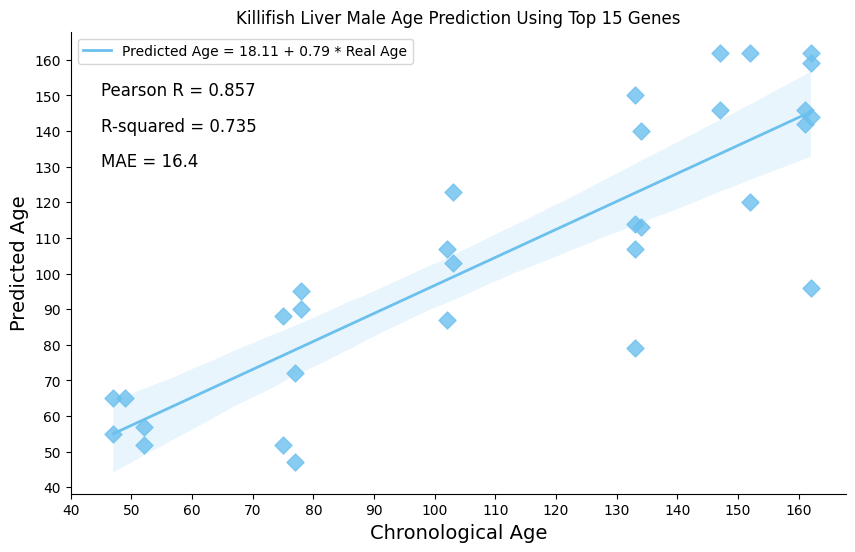

In [ ]:
# Ensure the 'age' and 'prediction' columns are numeric
liver_male_predicted_ages['age'] = pd.to_numeric(liver_male_predicted_ages['true_age'], errors='coerce')
liver_male_predicted_ages['prediction'] = pd.to_numeric(liver_male_predicted_ages['prediction'], errors='coerce')

# Drop rows with NaN values in 'age' or 'prediction' columns
liver_df_male_predictions = liver_male_predicted_ages.dropna(subset=['age', 'prediction'])

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(liver_male_predicted_ages['age'], liver_male_predicted_ages['prediction'])

# Calculate Pearson R, R-squared, and MAE
liver_correlation_coefficient = r_value
cod = r_value ** 2
MAE = mae(liver_male_predicted_ages['age'], liver_male_predicted_ages['prediction'])

# Formatting variables to three significant figures
liver_correlation_coefficient = f"{liver_correlation_coefficient:.3g}"
cod = f"{cod:.3g}"
MAE = f"{MAE:.3g}"

# Plotting the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x="age",
            y="prediction",
            data=liver_male_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
sns.despine(right=True)

x_tick = np.arange(40, 170, 10)
y_tick = np.arange(40, 170, 10)

plt.xticks(x_tick)
plt.yticks(y_tick)

# Perason Correlation
plt.text(45, 150, f"Pearson R = {liver_correlation_coefficient}", fontsize=12, color="black")

#R-squared
plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

# Adding MAE text
plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

# Changing the names and sizes of x and y-axis labels
plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

# Changing the size of the title
#plt.title('Killifish Liver Male Age Prediction Using Top 15 Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed
plt.title("".join(['Killifish Liver Male Age Prediction Using Top ', str(gene_number), ' Genes']))


# Display the legend
plt.legend()

# Save the plot as a publication-ready image (e.g., PNG)
#plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_male_scatter_plot_top_20_genes.svg', dpi=300, bbox_inches='tight')
plt.savefig("".join(["./plots/killifish_liver_male_scatter_plot_top_",str(gene_number),"_genes.svg"]), dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
xed

NameError: name 'xed' is not defined

# Kidney

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/kidney/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
kidney_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "Kidney"]

kidney_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A10_1,5891,1108,266,676,233,835,1374,809,716,778,...,137,1370,380,662,3191,498,477,M,Kidney,133
A11_1,7544,824,238,674,292,726,1363,1049,795,767,...,117,1139,428,560,2096,387,479,M,Kidney,47
A12_1,10043,1004,308,812,356,893,1594,1200,803,878,...,152,1461,377,859,2667,534,617,M,Kidney,161
A9_1,3788,1280,351,748,533,865,1443,1127,849,816,...,257,1705,441,742,4230,386,619,F,Kidney,78
B10_1,9185,1117,216,764,364,833,1893,1034,837,912,...,142,1438,283,910,3535,800,715,M,Kidney,147


In [ ]:
kidney_age_days_value_counts = kidney_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
kidney_age_steps = sorted(kidney_age_days_value_counts)

print(kidney_age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
kidney_gene_expression_data = kidney_df_counts.iloc[:, :-3]

In [ ]:
kidney_df_age = kidney_gene_expression_data.copy()

In [ ]:
kidney_df_age["age"] = kidney_df_counts["age_days"].tolist()

kidney_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A10_1,5891,1108,266,676,233,835,1374,809,716,778,...,156,1650,137,1370,380,662,3191,498,477,133
A11_1,7544,824,238,674,292,726,1363,1049,795,767,...,206,1214,117,1139,428,560,2096,387,479,47
A12_1,10043,1004,308,812,356,893,1594,1200,803,878,...,163,1831,152,1461,377,859,2667,534,617,161


In [ ]:
#for sample in kidney_df_age.index.tolist():

#    new_df = kidney_df_age.drop(sample)

#    new_df.to_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/kidney/sample/kidney_sample_{sample}.csv", sep="\t")

#    print(new_df.shape)

In [ ]:
kidney_age_steps = list(np.arange(47, 163, 1))

In [ ]:
#counter = 0

#for sample in kidney_df_age.index.tolist():

#    transcriptome_reference(training_matrix=f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/kidney/sample/kidney_sample_{sample}.csv",
#                            reference_name=f"kidney_reference_{sample}",
#                            output_path="/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/kidney/reference/",
#                            age_prediction="list",
#                            age_list=kidney_age_steps,
#                            min_age=1,
#                            max_age=24,
#                            age_step=1,
#                            tau=0.7)

#    counter += 1

#    print(counter)

#### Kidney Age Prediction

In [ ]:
gene_number = 10

In [ ]:
# Initialize DataFrame for predictions
kidney_predicted_ages = pd.DataFrame(index=kidney_df_age.index, columns=["prediction"])

# Iterate through each sample in the DataFrame
for sample in kidney_df_age.index.tolist():

    # Read the spearman and frequency data for the current sample
    #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
    df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/kidney/reference/kidney_reference_{sample}", sep="\t")
    df_frequency.set_index("Gene", inplace=True)

    # Get top genes based on spearman correlation
    top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
    top_genes = top_absolute_spearman_correlation.index.tolist()
    #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

    total_reads_sample = df_unnorm.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    # Iterate through each age step
    for age in kidney_age_steps:

        probability_list_one_age = []
        genes_not_defined = []

        # Iterate through each gene for the sample
        for gene in top_genes:

            gene_frequency = df_frequency.loc[gene, f"{age}"]

            # Replace negative gene frequency with 10^-10
            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_unnorm.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=liver_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    kidney_predicted_ages.loc[sample, "prediction"] = max_probability_age

# Print the resulting DataFrame
print(kidney_predicted_ages)

      prediction
A10_1      154.0
A11_1       53.0
A12_1      118.0
A9_1        81.0
B10_1      132.0
B11_1       90.0
B12_1       50.0
B9_1        77.0
C10_1       83.0
C11_1       87.0
C12_1       83.0
C9_1        93.0
D10_1      108.0
D11_1       65.0
D12_1       47.0
D9_1       140.0
E10_1       84.0
E11_1      105.0
E12_1      160.0
E9_1        81.0
F10_1       47.0
F11_1      123.0
F12_1       82.0
F9_1       113.0
G10_1      162.0
G11_1       61.0
G12_1       80.0
G9_1       141.0
H10_1       63.0
H11_1       74.0
H9_1       115.0
I10_1       75.0
I11_1      145.0
I9_1       143.0
J10_1      100.0
J11_1      118.0
J9_1       118.0
K10_1       63.0
K11_1       57.0
K9_1        65.0
L10_1       56.0
L11_1      101.0
L9_1        70.0
M10_1       85.0
M11_1       50.0
M9_1       162.0
N10_1      149.0
N11_1       52.0
N9_1       115.0
O10_1      143.0
O11_1      162.0
O9_1       146.0
P10_1       78.0
P11_1       63.0
P9_1        58.0


In [ ]:
kidney_predicted_ages["true_age"] = kidney_df_age["age"].tolist()

In [ ]:
kidney_df_model = sm.OLS(kidney_predicted_ages["prediction"].tolist(), sm.add_constant(kidney_predicted_ages["true_age"].tolist()))

kidney_df_results =  kidney_df_model.fit()

print(kidney_df_results.params)
print(kidney_df_results.summary())

[31.86776465  0.62306416]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.510
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     55.17
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           9.24e-10
Time:                        18:37:04   Log-Likelihood:                -254.64
No. Observations:                  55   AIC:                             513.3
Df Residuals:                      53   BIC:                             517.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.8678     

In [ ]:
b, m = kidney_df_results.params

In [ ]:
MAE = mae(kidney_predicted_ages["true_age"].tolist(), kidney_predicted_ages["prediction"].tolist())

print(MAE)

22.30909090909091


In [ ]:
kidney_correlation_coefficient, kidney_p_value = pearsonr(kidney_predicted_ages["true_age"].tolist(), kidney_predicted_ages["prediction"].tolist())

kidney_correlation_coefficient

0.7141720111009109

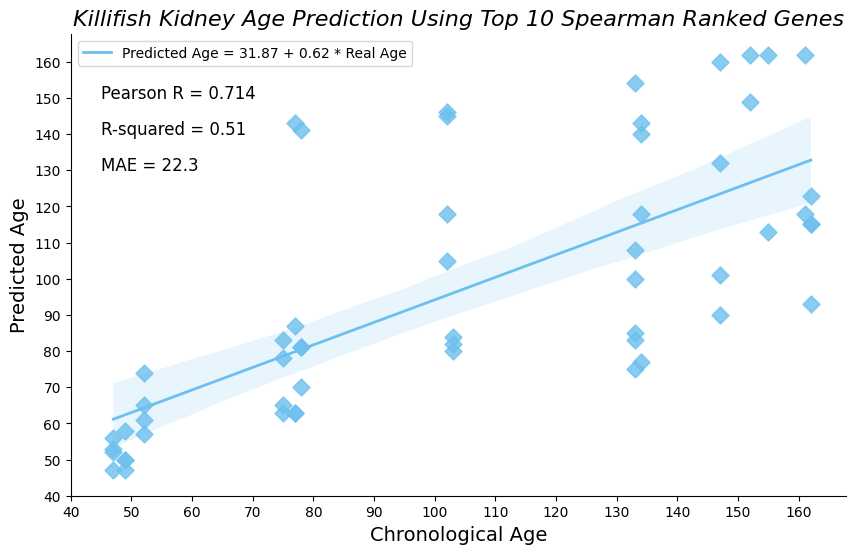

In [ ]:
# Ensure the 'age' and 'prediction' columns are numeric
kidney_predicted_ages['age'] = pd.to_numeric(kidney_predicted_ages['true_age'], errors='coerce')
kidney_predicted_ages['prediction'] = pd.to_numeric(kidney_predicted_ages['prediction'], errors='coerce')

# Drop rows with NaN values in 'age' or 'prediction' columns
kidney_df_female_predictions = kidney_predicted_ages.dropna(subset=['age', 'prediction'])

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(kidney_predicted_ages['age'], kidney_predicted_ages['prediction'])

# Calculate Pearson R, R-squared, and MAE
kidney_correlation_coefficient = r_value
cod = r_value ** 2
MAE = mae(kidney_predicted_ages['age'], kidney_predicted_ages['prediction'])

# Formatting variables to three significant figures
kidney_correlation_coefficient = f"{kidney_correlation_coefficient:.3g}"
cod = f"{cod:.3g}"
MAE = f"{MAE:.3g}"

# Plotting the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x="age",
            y="prediction",
            data=kidney_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
sns.despine(right=True)

x_tick = np.arange(40, 170, 10)
y_tick = np.arange(40, 170, 10)

plt.xticks(x_tick)
plt.yticks(y_tick)

# Perason Correlation
plt.text(45, 150, f"Pearson R = {kidney_correlation_coefficient}", fontsize=12, color="black")

#R-squared
plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

# Adding MAE text
plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

# Changing the names and sizes of x and y-axis labels
plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

# Changing the size of the title
plt.title('Killifish Kidney Age Prediction Using Top 10 Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

# Display the legend
plt.legend()

# Save the plot as a publication-ready image (e.g., PNG)
#plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_kidney_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

plt.show()

# Skin

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/skin/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
skin_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "Skin"]

skin_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A17_1,0,879,319,1047,660,544,916,1263,728,575,...,159,1082,94,635,7113,558,464,F,Skin,134
A18_1,0,666,301,951,733,584,1298,1583,566,601,...,107,671,11,723,5201,490,561,M,Skin,161
A19_1,4,451,154,729,544,312,645,779,388,416,...,52,512,23,457,3973,263,277,M,Skin,162
A20_1,0,862,232,1275,910,714,1260,1416,641,903,...,91,1082,49,752,7939,621,586,M,Skin,161
B17_1,2,782,318,908,605,553,1031,1191,749,646,...,68,994,40,542,5770,630,458,F,Skin,155


In [ ]:
skin_age_days_value_counts = skin_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
skin_age_steps = sorted(skin_age_days_value_counts)

print(skin_age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
skin_gene_expression_data = skin_df_counts.iloc[:, :-3]

In [ ]:
skin_df_age = skin_gene_expression_data.copy()

In [ ]:
skin_df_age["age"] = skin_df_counts["age_days"].tolist()

skin_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A17_1,0,879,319,1047,660,544,916,1263,728,575,...,110,1613,159,1082,94,635,7113,558,464,134
A18_1,0,666,301,951,733,584,1298,1583,566,601,...,87,1454,107,671,11,723,5201,490,561,161
A19_1,4,451,154,729,544,312,645,779,388,416,...,74,868,52,512,23,457,3973,263,277,162


In [ ]:
#for sample in skin_df_age.index.tolist():

#    new_df = skin_df_age.drop(sample)

#    new_df.to_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/skin/sample/skin_sample_{sample}.csv", sep="\t")

#    print(new_df.shape)

In [ ]:
new_skin_age_steps = list(np.arange(min(skin_age_steps), max(skin_age_steps) + 1 , 1))

In [ ]:
#counter = 0

#for sample in skin_df_age.index.tolist():

 #   transcriptome_reference(training_matrix=f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/skin/sample/skin_sample_{sample}.csv",
#                            reference_name=f"skin_reference_{sample}",
 #                           output_path="/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/skin/reference/",
#                            age_prediction="list",
#                            age_list=new_skin_age_steps,
#                            min_age=1,
#                            max_age=24,
#                            age_step=1,
#                            tau=0.7)

 #   counter += 1

#    print(counter)

#### Skin Age Prediction

In [ ]:
gene_number = 50

In [ ]:
# Initialize DataFrame for predictions
skin_predicted_ages = pd.DataFrame(index=skin_df_age.index, columns=["prediction"])

# Iterate through each sample in the DataFrame
for sample in skin_df_age.index.tolist():

    # Read the spearman and frequency data for the current sample
    #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
    df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/skin/reference/skin_reference_{sample}", sep="\t")
    df_frequency.set_index("Gene", inplace=True)

    # Get top genes based on spearman correlation
    top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
    top_genes = top_absolute_spearman_correlation.index.tolist()
    #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

    total_reads_sample = df_unnorm.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    # Iterate through each age step
    for age in new_skin_age_steps:

        probability_list_one_age = []
        genes_not_defined = []

        # Iterate through each gene for the sample
        for gene in top_genes:

            gene_frequency = df_frequency.loc[gene, f"{age}"]

            # Replace negative gene frequency with 10^-10
            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_unnorm.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_skin_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    skin_predicted_ages.loc[sample, "prediction"] = max_probability_age

# Print the resulting DataFrame
print(skin_predicted_ages)

      prediction
A17_1      123.0
A18_1      138.0
A19_1      162.0
A20_1      147.0
B17_1      144.0
B18_1      147.0
B19_1      115.0
B20_1       57.0
C17_1       47.0
C18_1       47.0
C19_1       98.0
C20_1       47.0
D17_1       62.0
D18_1       99.0
D19_1      152.0
D20_1       89.0
E17_1      103.0
E18_1       60.0
E19_1       73.0
E20_1       47.0
F17_1      126.0
F18_1      152.0
F19_1      162.0
F20_1       53.0
G17_1       77.0
G18_1      113.0
G19_1       48.0
G20_1      160.0
H17_1       48.0
H18_1      116.0
I17_1       54.0
I18_1      146.0
I19_1      141.0
J17_1       71.0
J18_1      143.0
J19_1       98.0
K17_1      127.0
K18_1      110.0
K19_1      162.0
L17_1      100.0
L18_1      110.0
L19_1       59.0
M17_1      162.0
M18_1      152.0
M19_1      148.0
N17_1       97.0
N18_1      162.0
N19_1       73.0
O17_1       62.0
O18_1       80.0
O19_1      106.0
P17_1       66.0
P18_1       50.0
P19_1      149.0


In [ ]:
skin_predicted_ages["true_age"] = skin_df_age["age"].tolist()

In [ ]:
skin_df_model = sm.OLS(skin_predicted_ages["prediction"].tolist(), sm.add_constant(skin_predicted_ages["true_age"].tolist()))

skin_df_results = skin_df_model.fit()

print(skin_df_results.params)
print(skin_df_results.summary())

[20.38477386  0.80226621]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     104.0
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           5.27e-14
Time:                        20:25:10   Log-Likelihood:                -246.30
No. Observations:                  54   AIC:                             496.6
Df Residuals:                      52   BIC:                             500.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.3848     

In [ ]:
b, m = skin_df_results.params

In [ ]:
MAE = mae(skin_predicted_ages["true_age"].tolist(), skin_predicted_ages["prediction"].tolist())

print(MAE)

18.074074074074073


In [ ]:
skin_correlation_coefficient, skin_p_value = pearsonr(skin_predicted_ages["true_age"].tolist(), skin_predicted_ages["prediction"].tolist())

skin_correlation_coefficient

0.8164852982751137

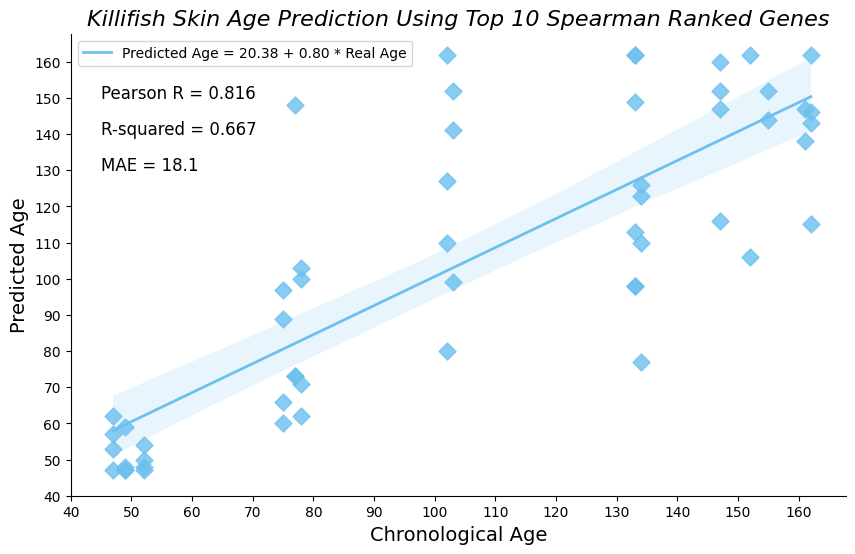

In [ ]:
# Ensure the 'age' and 'prediction' columns are numeric
skin_predicted_ages['age'] = pd.to_numeric(skin_predicted_ages['true_age'], errors='coerce')
skin_predicted_ages['prediction'] = pd.to_numeric(skin_predicted_ages['prediction'], errors='coerce')

# Drop rows with NaN values in 'age' or 'prediction' columns
skin_df_female_predictions = skin_predicted_ages.dropna(subset=['age', 'prediction'])

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(skin_predicted_ages['age'], skin_predicted_ages['prediction'])

# Calculate Pearson R, R-squared, and MAE
skin_correlation_coefficient = r_value
cod = r_value ** 2
MAE = mae(skin_predicted_ages['age'], skin_predicted_ages['prediction'])

# Formatting variables to three significant figures
skin_correlation_coefficient = f"{skin_correlation_coefficient:.3g}"
cod = f"{cod:.3g}"
MAE = f"{MAE:.3g}"

# Plotting the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x="age",
            y="prediction",
            data=skin_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
sns.despine(right=True)

x_tick = np.arange(40, 170, 10)
y_tick = np.arange(40, 170, 10)

plt.xticks(x_tick)
plt.yticks(y_tick)

# Perason Correlation
plt.text(45, 150, f"Pearson R = {skin_correlation_coefficient}", fontsize=12, color="black")

#R-squared
plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

# Adding MAE text
plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

# Changing the names and sizes of x and y-axis labels
plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

# Changing the size of the title
plt.title('Killifish Skin Age Prediction Using Top 10 Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

# Display the legend
plt.legend()

# Save the plot as a publication-ready image (e.g., PNG)
#plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

plt.show()

# Gut

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/gut/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
gut_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "Gut"]

gut_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,21686,623,1980,523,200,802,1242,1224,562,577,...,220,1560,42,515,3018,1422,325,F,Gut,155
A2_1,17338,448,2930,420,208,532,1008,1284,367,330,...,156,922,36,300,3297,1659,201,M,Gut,133
A3_1,20387,315,1904,494,178,584,1153,1301,551,401,...,201,1274,24,432,2967,1781,251,F,Gut,134
A4_1,15913,379,2115,438,240,584,942,890,402,387,...,129,1183,64,296,2981,1396,210,F,Gut,75
B1_1,16812,301,1276,467,196,568,857,1074,304,281,...,94,939,6,439,2498,1035,204,M,Gut,134


In [ ]:
gut_age_days_value_counts = gut_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
gut_age_steps = sorted(gut_age_days_value_counts)

print(gut_age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
gut_gene_expression_data = gut_df_counts.iloc[:, :-3]

In [ ]:
gut_df_age = gut_gene_expression_data.copy()

In [ ]:
gut_df_age["age"] = gut_df_counts["age_days"].tolist()

gut_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A1_1,21686,623,1980,523,200,802,1242,1224,562,577,...,161,1014,220,1560,42,515,3018,1422,325,155
A2_1,17338,448,2930,420,208,532,1008,1284,367,330,...,84,612,156,922,36,300,3297,1659,201,133
A3_1,20387,315,1904,494,178,584,1153,1301,551,401,...,122,1016,201,1274,24,432,2967,1781,251,134


In [ ]:
#for sample in gut_df_age.index.tolist():

#    new_df = gut_df_age.drop(sample)

#    new_df.to_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/gut/sample/gut_sample_{sample}.csv", sep="\t")

#    print(new_df.shape)

In [ ]:
new_gut_age_steps = np.arange(min(gut_age_steps), max(gut_age_steps) + 1, 1)

In [ ]:
#counter = 0

#for sample in gut_df_age.index.tolist():

#    transcriptome_reference(training_matrix=f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/gut/sample/gut_sample_{sample}.csv",
#                           reference_name=f"gut_reference_{sample}",
#                            output_path="/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/gut/reference/",
#                            age_prediction="list",
#                            age_list=new_gut_age_steps,
#                            min_age=1,
#                            max_age=24,
#                            age_step=1,
#                            tau=0.7)

#    counter += 1

#    print(counter)

#### Gut Age Prediction

In [ ]:
gene_number = 50

In [ ]:
# Initialize DataFrame for predictions
gut_predicted_ages = pd.DataFrame(index=gut_df_age.index, columns=["prediction"])

# Iterate through each sample in the DataFrame
for sample in gut_df_age.index.tolist():

    # Read the spearman and frequency data for the current sample
    #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
    df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/gut/reference/gut_reference_{sample}", sep="\t")
    df_frequency.set_index("Gene", inplace=True)

    # Get top genes based on spearman correlation
    top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
    top_genes = top_absolute_spearman_correlation.index.tolist()
    #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

    total_reads_sample = df_unnorm.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    # Iterate through each age step
    for age in new_gut_age_steps:

        probability_list_one_age = []
        genes_not_defined = []

        # Iterate through each gene for the sample
        for gene in top_genes:

            gene_frequency = df_frequency.loc[gene, f"{age}"]

            # Replace negative gene frequency with 10^-10
            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_unnorm.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_gut_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    gut_predicted_ages.loc[sample, "prediction"] = max_probability_age

# Print the resulting DataFrame
print(gut_predicted_ages)

     prediction
A1_1      130.0
A2_1      162.0
A3_1      114.0
A4_1       81.0
B1_1      155.0
B2_1      136.0
B3_1       57.0
B4_1       70.0
C1_1       71.0
C2_1      109.0
C3_1      128.0
C4_1      115.0
D1_1       64.0
D2_1      162.0
D3_1      148.0
D4_1      139.0
E1_1      113.0
E2_1      122.0
E3_1      128.0
E4_1       83.0
F1_1      157.0
F2_1      143.0
F3_1      162.0
F4_1      121.0
G1_1      160.0
G2_1      135.0
G3_1      128.0
G4_1       55.0
H1_1       61.0
H2_1       51.0
H3_1       68.0
I1_1      114.0
I2_1       54.0
I3_1      124.0
J1_1      149.0
J2_1      147.0
J3_1      119.0
K1_1       86.0
K2_1      119.0
K3_1       53.0
L1_1      162.0
L2_1      106.0
L3_1      114.0
M1_1      162.0
M2_1       76.0
M3_1      153.0
N1_1       85.0
N2_1      109.0
N3_1       76.0
O1_1       53.0
O2_1       86.0
O3_1       60.0
P1_1      158.0
P2_1      105.0
P3_1       81.0


In [ ]:
gut_predicted_ages["true_age"] = gut_df_age["age"].tolist()

In [ ]:
gut_df_model = sm.OLS(gut_predicted_ages["prediction"].tolist(), sm.add_constant(gut_predicted_ages["true_age"].tolist()))

gut_df_results = gut_df_model.fit()

print(gut_df_results.params)
print(gut_df_results.summary())

[36.18089321  0.71299928]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     96.57
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           1.54e-13
Time:                        20:54:27   Log-Likelihood:                -246.66
No. Observations:                  55   AIC:                             497.3
Df Residuals:                      53   BIC:                             501.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.1809     

In [ ]:
b, m = gut_df_results.params

In [ ]:
MAE = mae(gut_predicted_ages["true_age"].tolist(), gut_predicted_ages["prediction"].tolist())

print(MAE)

19.89090909090909


In [ ]:
gut_correlation_coefficient, gut_p_value = pearsonr(gut_predicted_ages["true_age"].tolist(), gut_predicted_ages["prediction"].tolist())

gut_correlation_coefficient

0.8035258506762499

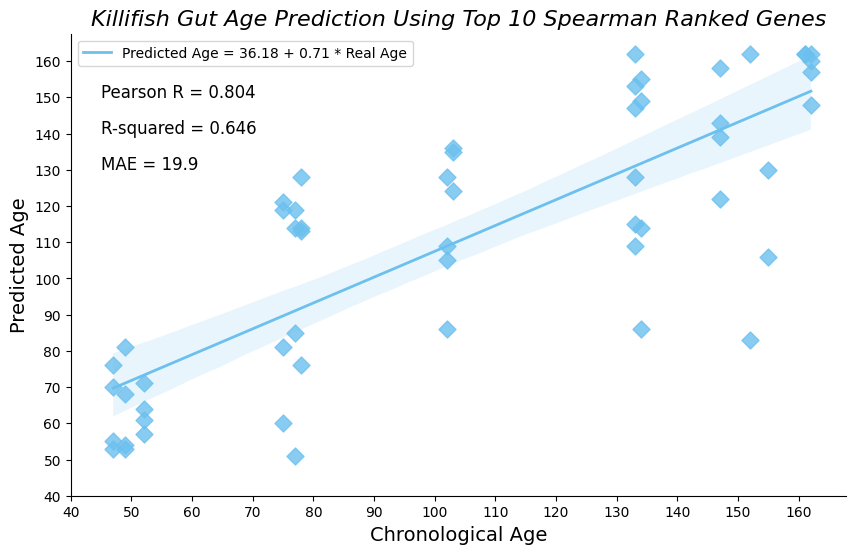

In [ ]:
# Ensure the 'age' and 'prediction' columns are numeric
gut_predicted_ages['age'] = pd.to_numeric(gut_predicted_ages['true_age'], errors='coerce')
gut_predicted_ages['prediction'] = pd.to_numeric(gut_predicted_ages['prediction'], errors='coerce')

# Drop rows with NaN values in 'age' or 'prediction' columns
gut_df_female_predictions = gut_predicted_ages.dropna(subset=['age', 'prediction'])

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(gut_predicted_ages['age'], gut_predicted_ages['prediction'])

# Calculate Pearson R, R-squared, and MAE
gut_correlation_coefficient = r_value
cod = r_value ** 2
MAE = mae(gut_predicted_ages['age'], gut_predicted_ages['prediction'])

# Formatting variables to three significant figures
gut_correlation_coefficient = f"{gut_correlation_coefficient:.3g}"
cod = f"{cod:.3g}"
MAE = f"{MAE:.3g}"

# Plotting the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x="age",
            y="prediction",
            data=gut_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
sns.despine(right=True)

x_tick = np.arange(40, 170, 10)
y_tick = np.arange(40, 170, 10)

plt.xticks(x_tick)
plt.yticks(y_tick)

# Perason Correlation
plt.text(45, 150, f"Pearson R = {gut_correlation_coefficient}", fontsize=12, color="black")

#R-squared
plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

# Adding MAE text
plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

# Changing the names and sizes of x and y-axis labels
plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

# Changing the size of the title
plt.title('Killifish Gut Age Prediction Using Top 10 Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

# Display the legend
plt.legend()

# Save the plot as a publication-ready image (e.g., PNG)
#plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

plt.show()

# Brain

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/brain/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
brain_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "Brain"]

brain_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A21_2,97,929,895,571,266,1008,4422,601,898,771,...,396,1124,35,1873,1132,294,616,M,Brain,162
A22_2,97,804,995,643,176,887,4179,502,820,839,...,487,1142,39,2228,1671,338,820,M,Brain,152
A23_2,28,973,978,524,173,703,5011,386,584,614,...,350,840,51,2049,1226,422,735,F,Brain,78
A24_2,74,929,717,564,169,839,3392,532,556,719,...,386,981,40,1700,1317,268,711,M,Brain,103
B21_2,91,1142,1030,887,253,1051,4066,404,891,1066,...,532,1756,54,2382,2295,424,695,M,Brain,162


In [ ]:
brain_age_days_value_counts = brain_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
brain_age_steps = sorted(brain_age_days_value_counts)

print(brain_age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
brain_gene_expression_data = brain_df_counts.iloc[:, :-3]

In [ ]:
brain_df_age = brain_gene_expression_data.copy()

In [ ]:
brain_df_age["age"] = brain_df_counts["age_days"].tolist()

brain_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A21_2,97,929,895,571,266,1008,4422,601,898,771,...,189,966,396,1124,35,1873,1132,294,616,162
A22_2,97,804,995,643,176,887,4179,502,820,839,...,118,1409,487,1142,39,2228,1671,338,820,152
A23_2,28,973,978,524,173,703,5011,386,584,614,...,108,1343,350,840,51,2049,1226,422,735,78


In [ ]:
#for sample in brain_df_age.index.tolist():

#    new_df = brain_df_age.drop(sample)

#    new_df.to_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/brain/sample/brain_sample_{sample}.csv", sep="\t")

#    print(new_df.shape)

In [ ]:
new_brain_age_steps = np.arange(min(brain_age_steps), max(brain_age_steps) + 1, 1)

In [ ]:
#counter = 0

#for sample in brain_df_age.index.tolist():

#    transcriptome_reference(training_matrix=f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/brain/sample/brain_sample_{sample}.csv",
#                            reference_name=f"brain_reference_{sample}",
#                            output_path="/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/brain/reference/",
#                            age_prediction="list",
#                            age_list=new_brain_age_steps,
#                            min_age=1,
#                            max_age=24,
#                            age_step=1,
#                            tau=0.7)

#    counter += 1

#    print(counter)

#### Age Prediction

In [ ]:
gene_number = 10

In [ ]:
# Initialize DataFrame for predictions
brain_predicted_ages = pd.DataFrame(index=brain_df_age.index, columns=["prediction"])

# Iterate through each sample in the DataFrame
for sample in brain_df_age.index.tolist():

    # Read the spearman and frequency data for the current sample
    #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
    df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/brain/reference/brain_reference_{sample}", sep="\t")
    df_frequency.set_index("Gene", inplace=True)

    # Get top genes based on spearman correlation
    top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
    top_genes = top_absolute_spearman_correlation.index.tolist()
    #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

    total_reads_sample = df_unnorm.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    # Iterate through each age step
    for age in new_brain_age_steps:

        probability_list_one_age = []
        genes_not_defined = []

        # Iterate through each gene for the sample
        for gene in top_genes:

            gene_frequency = df_frequency.loc[gene, f"{age}"]

            # Replace negative gene frequency with 10^-10
            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_unnorm.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_brain_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    brain_predicted_ages.loc[sample, "prediction"] = max_probability_age

# Print the resulting DataFrame
print(brain_predicted_ages)

      prediction
A21_2      162.0
A22_2      135.0
A23_2       85.0
A24_2       90.0
B21_2      111.0
B22_2       47.0
B23_2      109.0
B24_2      127.0
C21_2      106.0
C22_2      145.0
C23_2       64.0
C24_2       82.0
D21_2      112.0
D23_2       73.0
D24_2       77.0
E21_2      108.0
E22_2       63.0
E23_2      103.0
E24_2      162.0
F21_2      146.0
F22_2       47.0
F23_2       77.0
F24_2      157.0
G21_2      101.0
G22_2       47.0
G23_2       71.0
G24_2      148.0
H21_2      133.0
H22_2       50.0
H23_2       81.0
I21_2       47.0
I22_2      144.0
I23_2      133.0
J21_2      142.0
J22_2      103.0
J23_2      151.0
K21_2      139.0
K22_2      147.0
K23_2       88.0
L21_2      115.0
L22_2      152.0
L23_2      151.0
M21_2       62.0
M22_2       57.0
M23_2      130.0
N21_2       51.0
N22_2       47.0
N23_2      109.0
O21_2      140.0
O22_2      142.0
O23_2      150.0
P21_2      162.0
P22_2       47.0
P23_2      148.0


In [ ]:
brain_predicted_ages["true_age"] = brain_df_age["age"].tolist()

In [ ]:
brain_df_model = sm.OLS(brain_predicted_ages["prediction"].tolist(), sm.add_constant(brain_predicted_ages["true_age"].tolist()))

brain_df_results = brain_df_model.fit()

print(brain_df_results.params)
print(brain_df_results.summary())

[19.99225059  0.82596174]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     158.2
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           2.13e-17
Time:                        21:21:16   Log-Likelihood:                -235.83
No. Observations:                  54   AIC:                             475.7
Df Residuals:                      52   BIC:                             479.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.9923     

In [ ]:
b, m = brain_df_results.params

In [ ]:
MAE = mae(brain_predicted_ages["true_age"].tolist(), brain_predicted_ages["prediction"].tolist())

print(MAE)

13.222222222222221


In [ ]:
brain_correlation_coefficient, brain_p_value = pearsonr(brain_predicted_ages["true_age"].tolist(), brain_predicted_ages["prediction"].tolist())

brain_correlation_coefficient

0.8675362403096449

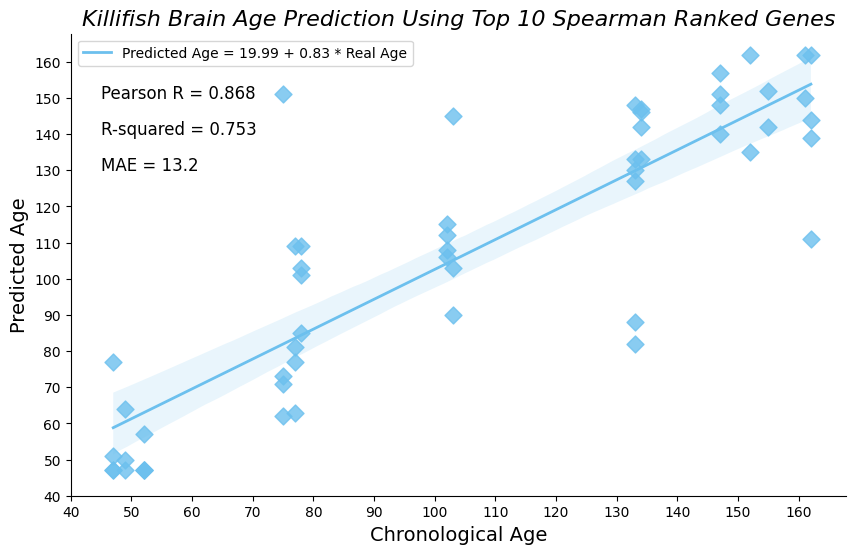

In [ ]:
# Ensure the 'age' and 'prediction' columns are numeric
brain_predicted_ages['age'] = pd.to_numeric(brain_predicted_ages['true_age'], errors='coerce')
brain_predicted_ages['prediction'] = pd.to_numeric(brain_predicted_ages['prediction'], errors='coerce')

# Drop rows with NaN values in 'age' or 'prediction' columns
brain_df_female_predictions = brain_predicted_ages.dropna(subset=['age', 'prediction'])

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(brain_predicted_ages['age'], brain_predicted_ages['prediction'])

# Calculate Pearson R, R-squared, and MAE
brain_correlation_coefficient = r_value
cod = r_value ** 2
MAE = mae(brain_predicted_ages['age'], brain_predicted_ages['prediction'])

# Formatting variables to three significant figures
brain_correlation_coefficient = f"{brain_correlation_coefficient:.3g}"
cod = f"{cod:.3g}"
MAE = f"{MAE:.3g}"

# Plotting the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x="age",
            y="prediction",
            data=brain_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
sns.despine(right=True)

x_tick = np.arange(40, 170, 10)
y_tick = np.arange(40, 170, 10)

plt.xticks(x_tick)
plt.yticks(y_tick)

# Perason Correlation
plt.text(45, 150, f"Pearson R = {brain_correlation_coefficient}", fontsize=12, color="black")

#R-squared
plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

# Adding MAE text
plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

# Changing the names and sizes of x and y-axis labels
plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

# Changing the size of the title
plt.title('Killifish Brain Age Prediction Using Top 10 Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

# Display the legend
plt.legend()

# Save the plot as a publication-ready image (e.g., PNG)
#plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

plt.show()

# Retina

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/retina/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
retina_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "Eye"]

retina_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
I12_2,10,391,602,686,80,564,2583,1137,940,516,...,204,430,26,898,664,169,436,M,Eye,47
I16_2,4,350,670,855,90,633,2865,1125,935,572,...,332,523,48,1046,1044,185,483,M,Eye,147
I20_2,16,439,710,889,132,879,2288,1329,927,786,...,312,564,18,680,594,66,328,M,Eye,78
I4_2,16,426,978,949,120,695,3943,1559,1117,667,...,269,563,28,1041,1233,127,543,F,Eye,103
I8_2,10,474,930,976,118,732,3438,1161,1041,702,...,281,456,38,882,650,110,374,F,Eye,78


In [ ]:
retina_age_days_value_counts = retina_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
retina_age_steps = sorted(retina_age_days_value_counts)

print(retina_age_steps)

[47, 49, 75, 77, 78, 102, 103, 133, 147, 152, 161, 162]


In [ ]:
retina_gene_expression_data = retina_df_counts.iloc[:, :-3]

In [ ]:
retina_df_age = retina_gene_expression_data.copy()

In [ ]:
retina_df_age["age"] = retina_df_counts["age_days"].tolist()

retina_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
I12_2,10,391,602,686,80,564,2583,1137,940,516,...,249,1060,204,430,26,898,664,169,436,47
I16_2,4,350,670,855,90,633,2865,1125,935,572,...,262,955,332,523,48,1046,1044,185,483,147
I20_2,16,439,710,889,132,879,2288,1329,927,786,...,292,625,312,564,18,680,594,66,328,78


In [ ]:
#for sample in retina_df_age.index.tolist():

#    new_df = retina_df_age.drop(sample)

#    new_df.to_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/retina/sample/retina_sample_{sample}.csv", sep="\t")

#    print(new_df.shape)

In [ ]:
new_retina_age_steps = np.arange(min(retina_age_steps), max(retina_age_steps) + 1, 1)

In [ ]:
#counter = 0

#for sample in retina_df_age.index.tolist():

#    transcriptome_reference(training_matrix=f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/retina/sample/retina_sample_{sample}.csv",
#                            reference_name=f"retina_reference_{sample}",
#                            output_path="/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/retina/reference/",
#                            age_prediction="list",
#                            age_list=new_retina_age_steps,
#                            min_age=1,
#                            max_age=24,
#                            age_step=1,
#                            tau=0.7)

#    counter += 1

#    print(counter)

#### Retina Age Prediction

In [ ]:
gene_number = 50

In [ ]:
# Initialize DataFrame for predictions
retina_predicted_ages = pd.DataFrame(index=retina_df_age.index, columns=["prediction"])

# Iterate through each sample in the DataFrame
for sample in retina_df_age.index.tolist():

    # Read the spearman and frequency data for the current sample
    #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
    df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/retina/reference/retina_reference_{sample}", sep="\t")
    df_frequency.set_index("Gene", inplace=True)

    # Get top genes based on spearman correlation
    top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
    top_genes = top_absolute_spearman_correlation.index.tolist()
    #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

    total_reads_sample = df_unnorm.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    # Iterate through each age step
    for age in new_retina_age_steps:

        probability_list_one_age = []
        genes_not_defined = []

        # Iterate through each gene for the sample
        for gene in top_genes:

            gene_frequency = df_frequency.loc[gene, f"{age}"]

            # Replace negative gene frequency with 10^-10
            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_unnorm.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_retina_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    retina_predicted_ages.loc[sample, "prediction"] = max_probability_age

# Print the resulting DataFrame
print(retina_predicted_ages)

      prediction
I12_2       91.0
I16_2       97.0
I20_2       75.0
I4_2       116.0
I8_2        94.0
J12_2      131.0
J16_2      133.0
J20_2      125.0
J4_2        64.0
J8_2       111.0
K12_2       68.0
K16_2      104.0
K20_2      112.0
K4_2       108.0
K8_2       100.0
L12_2      113.0
L16_2      110.0
L20_2      131.0
L4_2       112.0
L8_2       159.0
M12_2       84.0
M16_2       99.0
M20_2       95.0
M4_2        75.0
M8_2        49.0
N12_2       47.0
N16_2      160.0
N4_2        60.0
N8_2       123.0
O12_2      101.0
O16_2      150.0
O4_2       109.0
O8_2       120.0
P12_2      119.0
P16_2      112.0
P4_2       108.0
P8_2       149.0


In [ ]:
retina_predicted_ages["true_age"] = retina_df_age["age"].tolist()

In [ ]:
retina_predicted_ages.head(5)

,prediction,true_age
I12_2,91.0,47
I16_2,97.0,147
I20_2,75.0,78
I4_2,116.0,103
I8_2,94.0,78


In [ ]:
retina_df_model = sm.OLS(retina_predicted_ages["prediction"].tolist(), sm.add_constant(retina_predicted_ages["true_age"].tolist()))

retina_df_results = retina_df_model.fit()

print(retina_df_results.params)
print(retina_df_results.summary())

[50.64039482  0.50192015]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     29.10
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           4.85e-06
Time:                        21:38:25   Log-Likelihood:                -163.92
No. Observations:                  37   AIC:                             331.8
Df Residuals:                      35   BIC:                             335.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.6404     

In [ ]:
b, m = retina_df_results.params

In [ ]:
MAE = mae(retina_predicted_ages["true_age"].tolist(), retina_predicted_ages["prediction"].tolist())

print(MAE)

21.864864864864863


In [ ]:
retina_correlation_coefficient, retina_p_value = pearsonr(retina_predicted_ages["true_age"].tolist(), retina_predicted_ages["prediction"].tolist())

retina_correlation_coefficient

0.6737860102721125

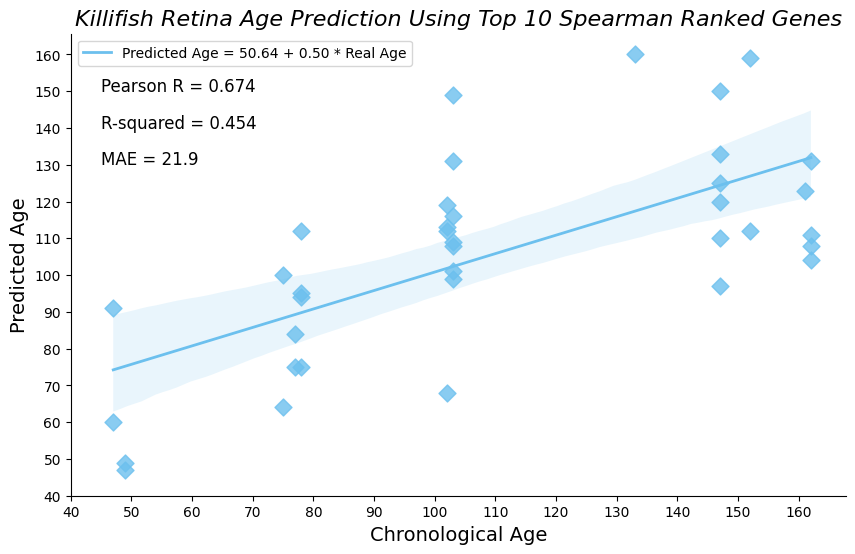

In [ ]:
# Ensure the 'age' and 'prediction' columns are numeric
retina_predicted_ages['age'] = pd.to_numeric(retina_predicted_ages['true_age'], errors='coerce')
retina_predicted_ages['prediction'] = pd.to_numeric(retina_predicted_ages['prediction'], errors='coerce')

# Drop rows with NaN values in 'age' or 'prediction' columns
retina_df_female_predictions = retina_predicted_ages.dropna(subset=['age', 'prediction'])

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(retina_predicted_ages['age'], retina_predicted_ages['prediction'])

# Calculate Pearson R, R-squared, and MAE
retina_correlation_coefficient = r_value
cod = r_value ** 2
MAE = mae(retina_predicted_ages['age'], retina_predicted_ages['prediction'])

# Formatting variables to three significant figures
retina_correlation_coefficient = f"{retina_correlation_coefficient:.3g}"
cod = f"{cod:.3g}"
MAE = f"{MAE:.3g}"

# Plotting the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x="age",
            y="prediction",
            data=retina_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
sns.despine(right=True)

x_tick = np.arange(40, 170, 10)
y_tick = np.arange(40, 170, 10)

plt.xticks(x_tick)
plt.yticks(y_tick)

# Perason Correlation
plt.text(45, 150, f"Pearson R = {retina_correlation_coefficient}", fontsize=12, color="black")

#R-squared
plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

# Adding MAE text
plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

# Changing the names and sizes of x and y-axis labels
plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

# Changing the size of the title
plt.title('Killifish Retina Age Prediction Using Top 10 Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

# Display the legend
plt.legend()

# Save the plot as a publication-ready image (e.g., PNG)
#plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

plt.show()

# Fat

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/fat/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
fat_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "Fat"]

fat_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_2,4017,132,317,205,106,293,711,322,297,198,...,43,597,26,183,780,128,186,M,Fat,52
A6_2,3879,677,129,461,267,628,974,363,668,484,...,187,682,192,406,3948,245,272,M,Fat,77
A7_2,2848,204,212,202,132,366,886,242,340,159,...,63,666,45,283,1236,169,243,F,Fat,78
A8_2,2692,257,197,297,83,218,627,223,165,148,...,48,462,56,314,884,138,211,M,Fat,103
B5_2,3697,253,262,313,188,411,727,410,329,225,...,41,813,26,299,937,186,208,F,Fat,134


In [ ]:
fat_age_days_value_counts = fat_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
fat_age_steps = sorted(fat_age_days_value_counts)

print(fat_age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
fat_gene_expression_data = fat_df_counts.iloc[:, :-3]

In [ ]:
fat_df_age = fat_gene_expression_data.copy()

In [ ]:
fat_df_age["age"] = fat_df_counts["age_days"].tolist()

fat_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_2,4017,132,317,205,106,293,711,322,297,198,...,27,468,43,597,26,183,780,128,186,52
A6_2,3879,677,129,461,267,628,974,363,668,484,...,82,1128,187,682,192,406,3948,245,272,77
A7_2,2848,204,212,202,132,366,886,242,340,159,...,47,747,63,666,45,283,1236,169,243,78


In [ ]:
#for sample in fat_df_age.index.tolist():

 #   new_df = fat_df_age.drop(sample)

#    new_df.to_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/fat/sample/fat_sample_{sample}.csv", sep="\t")

#    print(new_df.shape)

(52, 25123)


(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)
(52, 25123)


In [ ]:
new_fat_age_steps = np.arange(min(fat_age_steps), max(fat_age_steps) + 1, 1)

In [ ]:
#counter = 0

#for sample in fat_df_age.index.tolist():

#    transcriptome_reference(training_matrix=f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/fat/sample/fat_sample_{sample}.csv",
 #                           reference_name=f"fat_reference_{sample}",
#                            output_path="/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/fat/reference/",
#                            age_prediction="list",
#                            age_list=new_fat_age_steps,
#                            min_age=1,
#                            max_age=24,
#                            age_step=1,
#                            tau=0.7)

#    counter += 1

#    print(counter)

#### Fat Age Prediction

     prediction
A5_2       47.0
A6_2      135.0
A7_2      117.0
A8_2      162.0
B5_2       73.0
B6_2       97.0
B7_2      134.0
B8_2      137.0
C5_2       65.0
C6_2       72.0
C7_2       87.0
C8_2       47.0
D5_2      112.0
D6_2      131.0
D7_2      104.0
D8_2      162.0
E5_2      137.0
E6_2      100.0
E7_2      129.0
E8_2      150.0
F5_2       79.0
F6_2      130.0
F7_2       52.0
G5_2       49.0
G6_2      116.0
G7_2       47.0
H5_2      143.0
H6_2       67.0
H7_2       83.0
I5_2      114.0
I6_2       57.0
I7_2       90.0
J5_2      150.0
J6_2       80.0
J7_2      110.0
K5_2      111.0
K6_2      141.0
K7_2       47.0
L5_2       62.0
L6_2       69.0
L7_2      142.0
M5_2       96.0
M6_2       49.0
M7_2       89.0
N5_2      162.0
N6_2      101.0
N7_2       93.0
O5_2      162.0
O6_2       47.0
O7_2       64.0
P5_2       91.0
P6_2      162.0
P7_2       81.0
[34.00094854  0.63903559]
                            OLS Regression Results                            
Dep. Variable:                 

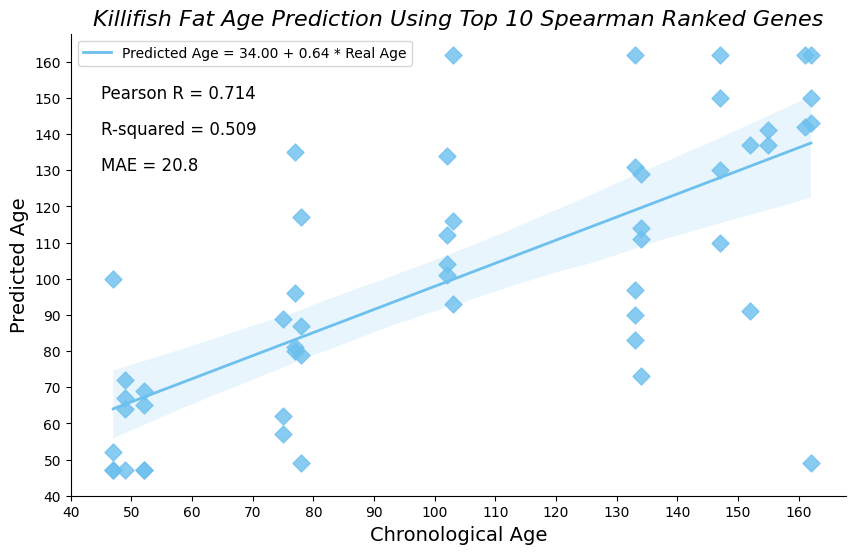

     prediction
A5_2       47.0
A6_2      124.0
A7_2       90.0
A8_2      144.0
B5_2       79.0
B6_2      100.0
B7_2      134.0
B8_2      136.0
C5_2       65.0
C6_2       72.0
C7_2       84.0
C8_2       47.0
D5_2      119.0
D6_2      133.0
D7_2      108.0
D8_2      157.0
E5_2      137.0
E6_2       89.0
E7_2      140.0
E8_2      162.0
F5_2       97.0
F6_2      123.0
F7_2       50.0
G5_2       49.0
G6_2      112.0
G7_2       47.0
H5_2      139.0
H6_2       74.0
H7_2       48.0
I5_2      115.0
I6_2       54.0
I7_2       90.0
J5_2      155.0
J6_2       78.0
J7_2      128.0
K5_2      111.0
K6_2      144.0
K7_2       47.0
L5_2       58.0
L6_2       67.0
L7_2      146.0
M5_2       91.0
M6_2       49.0
M7_2       73.0
N5_2      162.0
N6_2      101.0
N7_2       75.0
O5_2      162.0
O6_2       47.0
O7_2       72.0
P5_2      114.0
P6_2      162.0
P7_2       89.0
[29.49287982  0.67538943]
                            OLS Regression Results                            
Dep. Variable:                 

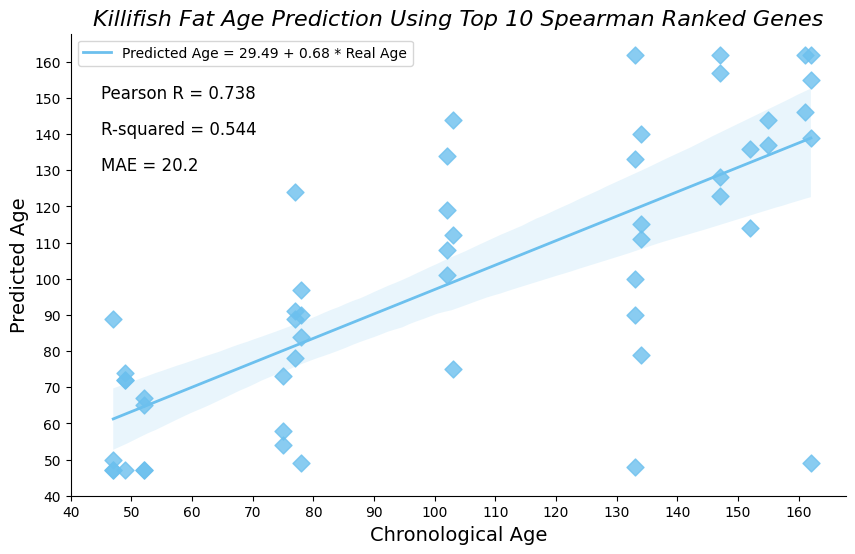

     prediction
A5_2       47.0
A6_2      121.0
A7_2      126.0
A8_2      151.0
B5_2       82.0
B6_2      102.0
B7_2      134.0
B8_2      143.0
C5_2       64.0
C6_2       72.0
C7_2       86.0
C8_2       47.0
D5_2      100.0
D6_2      128.0
D7_2      108.0
D8_2      158.0
E5_2      133.0
E6_2       88.0
E7_2      138.0
E8_2      138.0
F5_2       97.0
F6_2      126.0
F7_2       50.0
G5_2       49.0
G6_2      112.0
G7_2       47.0
H5_2      136.0
H6_2       74.0
H7_2       47.0
I5_2      107.0
I6_2       54.0
I7_2       90.0
J5_2      162.0
J6_2       79.0
J7_2      129.0
K5_2      110.0
K6_2      145.0
K7_2       47.0
L5_2       59.0
L6_2       65.0
L7_2      150.0
M5_2       91.0
M6_2       51.0
M7_2       69.0
N5_2      162.0
N6_2      146.0
N7_2       75.0
O5_2      162.0
O6_2       51.0
O7_2       56.0
P5_2      115.0
P6_2      162.0
P7_2       81.0
[30.38912237  0.67149928]
                            OLS Regression Results                            
Dep. Variable:                 

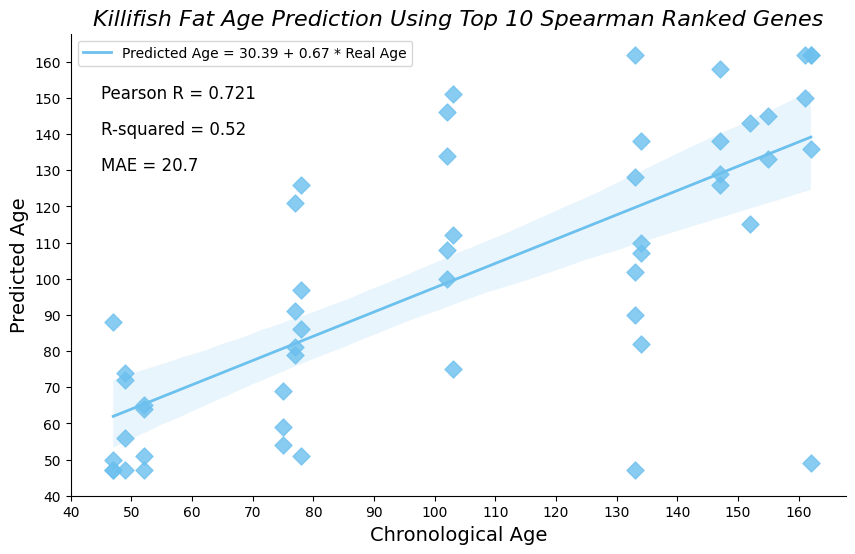

     prediction
A5_2       47.0
A6_2      126.0
A7_2      126.0
A8_2      143.0
B5_2       83.0
B6_2      104.0
B7_2      134.0
B8_2      142.0
C5_2       63.0
C6_2       71.0
C7_2       86.0
C8_2       47.0
D5_2      100.0
D6_2      128.0
D7_2      108.0
D8_2      158.0
E5_2      133.0
E6_2       88.0
E7_2      150.0
E8_2      162.0
F5_2       89.0
F6_2      125.0
F7_2       49.0
G5_2      162.0
G6_2      112.0
G7_2       47.0
H5_2      123.0
H6_2       74.0
H7_2       47.0
I5_2      107.0
I6_2       54.0
I7_2       90.0
J5_2      162.0
J6_2       78.0
J7_2      128.0
K5_2      111.0
K6_2      146.0
K7_2       47.0
L5_2       59.0
L6_2       66.0
L7_2      157.0
M5_2       92.0
M6_2       51.0
M7_2       69.0
N5_2      162.0
N6_2      144.0
N7_2       75.0
O5_2      162.0
O6_2       50.0
O7_2       57.0
P5_2      114.0
P6_2      162.0
P7_2       82.0
[23.81362249  0.75807454]
                            OLS Regression Results                            
Dep. Variable:                 

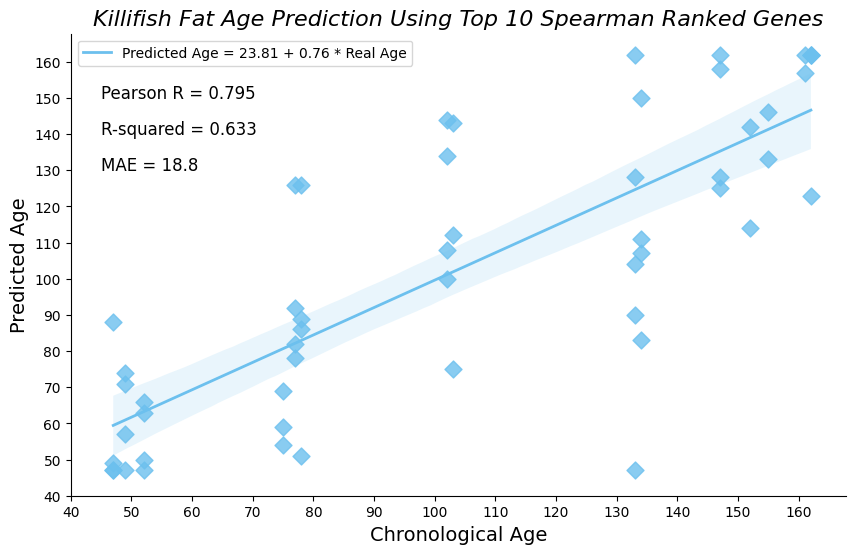

     prediction
A5_2       47.0
A6_2      121.0
A7_2      126.0
A8_2      146.0
B5_2       82.0
B6_2      103.0
B7_2      153.0
B8_2      143.0
C5_2       64.0
C6_2       69.0
C7_2       86.0
C8_2       47.0
D5_2      100.0
D6_2      130.0
D7_2      108.0
D8_2      161.0
E5_2      133.0
E6_2       88.0
E7_2      148.0
E8_2      162.0
F5_2       90.0
F6_2      125.0
F7_2       50.0
G5_2      161.0
G6_2      112.0
G7_2       47.0
H5_2      123.0
H6_2       74.0
H7_2       47.0
I5_2      107.0
I6_2       54.0
I7_2       90.0
J5_2      162.0
J6_2       79.0
J7_2      127.0
K5_2      109.0
K6_2      147.0
K7_2       47.0
L5_2       59.0
L6_2       66.0
L7_2      156.0
M5_2       93.0
M6_2       51.0
M7_2       70.0
N5_2      162.0
N6_2      144.0
N7_2       91.0
O5_2      162.0
O6_2       49.0
O7_2       57.0
P5_2      113.0
P6_2      162.0
P7_2       82.0
[24.53739032  0.75710482]
                            OLS Regression Results                            
Dep. Variable:                 

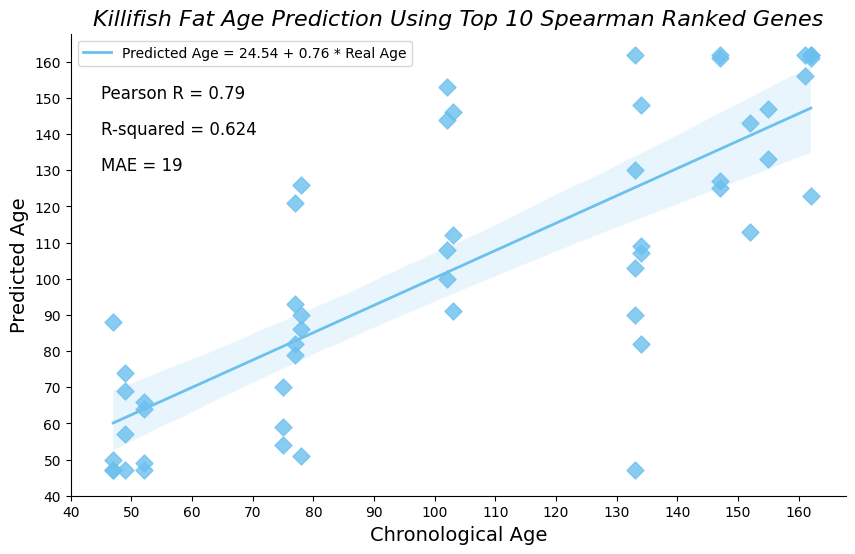

     prediction
A5_2       47.0
A6_2      125.0
A7_2      126.0
A8_2      148.0
B5_2       82.0
B6_2      104.0
B7_2      153.0
B8_2      147.0
C5_2       64.0
C6_2       66.0
C7_2       86.0
C8_2       47.0
D5_2      100.0
D6_2      127.0
D7_2      108.0
D8_2      162.0
E5_2      133.0
E6_2       88.0
E7_2      147.0
E8_2      127.0
F5_2       96.0
F6_2      124.0
F7_2       52.0
G5_2       49.0
G6_2      112.0
G7_2       47.0
H5_2      123.0
H6_2       55.0
H7_2       47.0
I5_2      105.0
I6_2       63.0
I7_2      116.0
J5_2      162.0
J6_2       76.0
J7_2      126.0
K5_2      106.0
K6_2      147.0
K7_2       47.0
L5_2       60.0
L6_2       66.0
L7_2      157.0
M5_2       93.0
M6_2       48.0
M7_2       70.0
N5_2      162.0
N6_2      144.0
N7_2       91.0
O5_2      162.0
O6_2       51.0
O7_2       58.0
P5_2      115.0
P6_2      162.0
P7_2       88.0
[30.24229694  0.68104908]
                            OLS Regression Results                            
Dep. Variable:                 

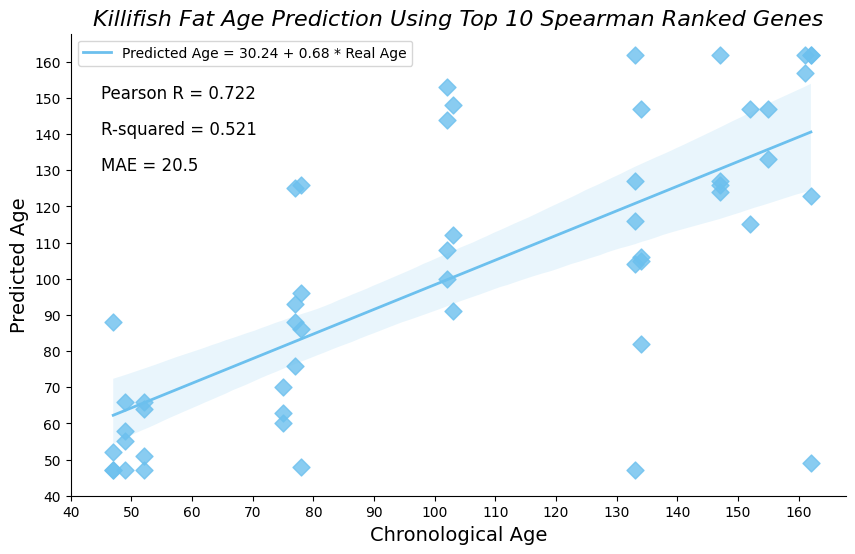

     prediction
A5_2       47.0
A6_2      125.0
A7_2      126.0
A8_2      147.0
B5_2       82.0
B6_2      103.0
B7_2      154.0
B8_2      149.0
C5_2       63.0
C6_2       66.0
C7_2       86.0
C8_2       47.0
D5_2      100.0
D6_2      125.0
D7_2      112.0
D8_2      162.0
E5_2      133.0
E6_2       88.0
E7_2      146.0
E8_2      162.0
F5_2       86.0
F6_2      124.0
F7_2       52.0
G5_2       49.0
G6_2      112.0
G7_2       47.0
H5_2      123.0
H6_2       70.0
H7_2       47.0
I5_2      105.0
I6_2       63.0
I7_2      116.0
J5_2      162.0
J6_2       78.0
J7_2      125.0
K5_2      106.0
K6_2      145.0
K7_2       47.0
L5_2       59.0
L6_2       62.0
L7_2      158.0
M5_2       93.0
M6_2       48.0
M7_2       72.0
N5_2      162.0
N6_2      144.0
N7_2       91.0
O5_2      159.0
O6_2       51.0
O7_2       56.0
P5_2      115.0
P6_2      162.0
P7_2       88.0
[29.6788479   0.69242284]
                            OLS Regression Results                            
Dep. Variable:                 

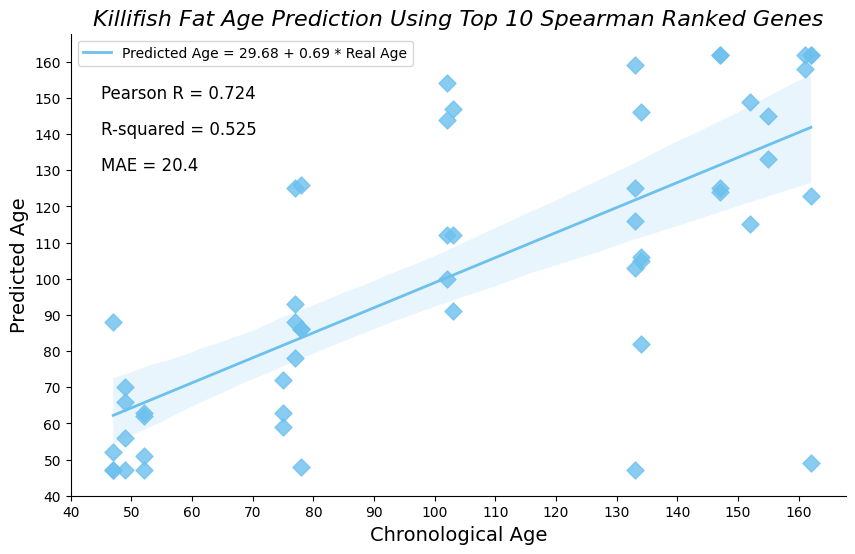

     prediction
A5_2       47.0
A6_2      126.0
A7_2       92.0
A8_2      151.0
B5_2       84.0
B6_2      104.0
B7_2      153.0
B8_2      149.0
C5_2       62.0
C6_2       66.0
C7_2       86.0
C8_2       47.0
D5_2      100.0
D6_2      124.0
D7_2      112.0
D8_2      162.0
E5_2      133.0
E6_2       88.0
E7_2      146.0
E8_2      162.0
F5_2       85.0
F6_2      124.0
F7_2       53.0
G5_2       49.0
G6_2      112.0
G7_2       47.0
H5_2      123.0
H6_2       70.0
H7_2       47.0
I5_2      105.0
I6_2       63.0
I7_2      116.0
J5_2      162.0
J6_2       77.0
J7_2      126.0
K5_2      106.0
K6_2      147.0
K7_2       47.0
L5_2       59.0
L6_2       61.0
L7_2      158.0
M5_2       89.0
M6_2       49.0
M7_2       73.0
N5_2      162.0
N6_2      144.0
N7_2       91.0
O5_2      159.0
O6_2       50.0
O7_2       56.0
P5_2      123.0
P6_2      162.0
P7_2       88.0
[27.30585046  0.71101681]
                            OLS Regression Results                            
Dep. Variable:                 

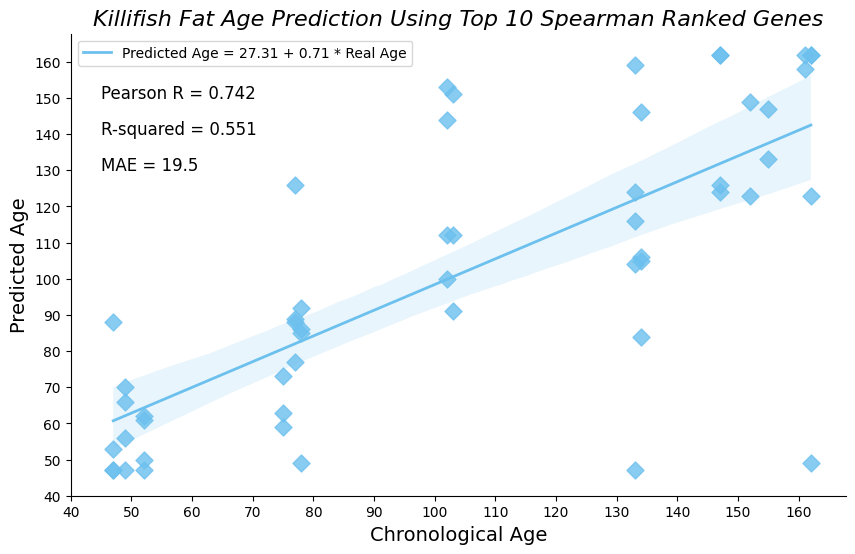

     prediction
A5_2       47.0
A6_2      125.0
A7_2       92.0
A8_2      150.0
B5_2       85.0
B6_2      103.0
B7_2      156.0
B8_2      149.0
C5_2       62.0
C6_2       66.0
C7_2       86.0
C8_2       47.0
D5_2      100.0
D6_2      124.0
D7_2      112.0
D8_2      162.0
E5_2      134.0
E6_2       87.0
E7_2      145.0
E8_2      162.0
F5_2       83.0
F6_2      124.0
F7_2       54.0
G5_2       49.0
G6_2      112.0
G7_2       47.0
H5_2      123.0
H6_2       71.0
H7_2       47.0
I5_2      105.0
I6_2       63.0
I7_2      116.0
J5_2      162.0
J6_2       78.0
J7_2      127.0
K5_2      106.0
K6_2      148.0
K7_2       47.0
L5_2       59.0
L6_2       64.0
L7_2      158.0
M5_2      111.0
M6_2       49.0
M7_2       73.0
N5_2      162.0
N6_2      144.0
N7_2       91.0
O5_2      159.0
O6_2       50.0
O7_2       56.0
P5_2      126.0
P6_2      162.0
P7_2       88.0
[28.48432073  0.70532495]
                            OLS Regression Results                            
Dep. Variable:                 

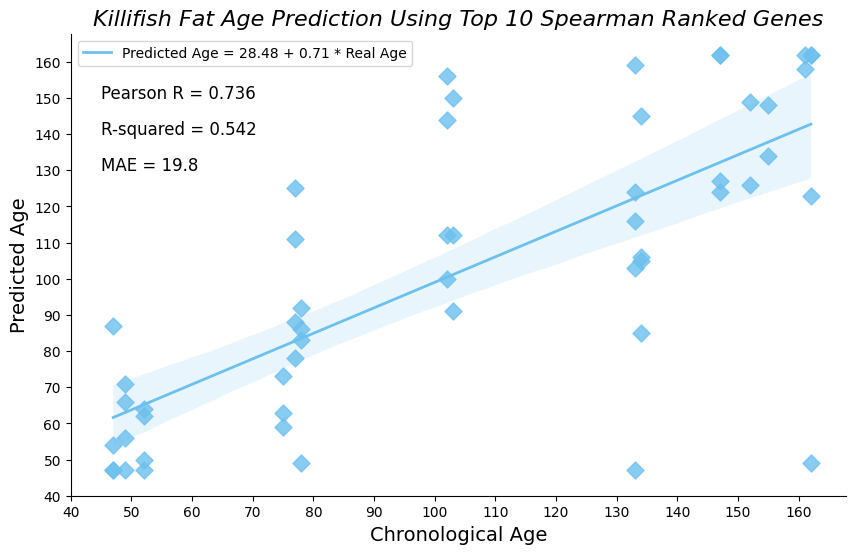

In [ ]:
gene_number_test = [10, 15, 20, 25, 30, 35, 40, 45, 50]

counter = 0

for number in gene_number_test:

    gene_number = number

    # Initialize DataFrame for predictions
    fat_predicted_ages = pd.DataFrame(index=fat_df_age.index, columns=["prediction"])

    # Iterate through each sample in the DataFrame
    for sample in fat_df_age.index.tolist():

        # Read the spearman and frequency data for the current sample
        #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
        df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/fat/reference/fat_reference_{sample}", sep="\t")
        df_frequency.set_index("Gene", inplace=True)

        # Get top genes based on spearman correlation
        top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
        top_genes = top_absolute_spearman_correlation.index.tolist()
        #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

        total_reads_sample = df_unnorm.loc[sample].sum()

        list_of_profile_probabilities_per_age = []

        # Iterate through each age step
        for age in new_fat_age_steps:

            probability_list_one_age = []
            genes_not_defined = []

            # Iterate through each gene for the sample
            for gene in top_genes:

                gene_frequency = df_frequency.loc[gene, f"{age}"]

                # Replace negative gene frequency with 10^-10
                if gene_frequency < 0:
                    gene_frequency = 10**-10

                sample_expected_counts = gene_frequency * total_reads_sample
                sample_observed_counts = df_unnorm.loc[sample, gene]

                poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

                # Replace NaN poisson probability with a small positive value and log it
                if np.isnan(poisson_probability):
                    poisson_probability = 0.001
                    genes_not_defined.append(gene)

                # Replace zero poisson probability with 0.001
                if poisson_probability == 0:
                    poisson_probability = 0.001

                logP = np.log(poisson_probability)

                probability_list_one_age.append(logP)

            list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

        # transform into dataframe with age steps
        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_fat_age_steps)

        # Compute highest likelihood age among age steps
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

        # Compute highest maximum probability
        max_probability = float(age_probability_df["Pr"].max())

        fat_predicted_ages.loc[sample, "prediction"] = max_probability_age

    # Print the resulting DataFrame
    print(fat_predicted_ages)

    fat_predicted_ages["true_age"] = fat_df_age["age"].tolist()

    fat_df_model = sm.OLS(fat_predicted_ages["prediction"].tolist(), sm.add_constant(fat_predicted_ages["true_age"].tolist()))

    fat_df_results = fat_df_model.fit()

    print(fat_df_results.params)
    print(fat_df_results.summary())

    b, m = fat_df_results.params

    MAE = mae(fat_predicted_ages["true_age"].tolist(), fat_predicted_ages["prediction"].tolist())

    print(MAE)

    fat_correlation_coefficient, fat_p_value = pearsonr(fat_predicted_ages["true_age"].tolist(), fat_predicted_ages["prediction"].tolist())

    fat_correlation_coefficient

    # Ensure the 'age' and 'prediction' columns are numeric
    fat_predicted_ages['age'] = pd.to_numeric(fat_predicted_ages['true_age'], errors='coerce')
    fat_predicted_ages['prediction'] = pd.to_numeric(fat_predicted_ages['prediction'], errors='coerce')

    # Drop rows with NaN values in 'age' or 'prediction' columns
    fat_df_female_predictions = fat_predicted_ages.dropna(subset=['age', 'prediction'])

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(fat_predicted_ages['age'], fat_predicted_ages['prediction'])

    # Calculate Pearson R, R-squared, and MAE
    fat_correlation_coefficient = r_value
    cod = r_value ** 2
    MAE = mae(fat_predicted_ages['age'], fat_predicted_ages['prediction'])

    # Formatting variables to three significant figures
    fat_correlation_coefficient = f"{fat_correlation_coefficient:.3g}"
    cod = f"{cod:.3g}"
    MAE = f"{MAE:.3g}"


    print(f"Performance for Gene Number: {gene_number}")
    print(f"Pearson Correlation: {fat_correlation_coefficient}")
    print(f"Coefficient of Determination: {cod}")
    print(f"Mean Absolute Error: {MAE}")

    counter += 1
    # Plotting the scatter plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.regplot(x="age",
            y="prediction",
            data=fat_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
    sns.despine(right=True)

    x_tick = np.arange(40, 170, 10)
    y_tick = np.arange(40, 170, 10)

    plt.xticks(x_tick)
    plt.yticks(y_tick)

    # Perason Correlation
    plt.text(45, 150, f"Pearson R = {fat_correlation_coefficient}", fontsize=12, color="black")

    #R-squared
    plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

    # Adding MAE text
    plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

    # Changing the names and sizes of x and y-axis labels
    plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
    plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

    # Changing the size of the title
    plt.title(f'Killifish Fat Age Prediction Using Top {gene_number} Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

    # Display the legend
    plt.legend()

    # Save the plot as a publication-ready image (e.g., PNG)
    #plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

    plt.show()

    print(counter)

# Heart

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/heart/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
heart_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "Heart"]

heart_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,249,1493,10,965,4511,265,630,M,Heart,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,100,1299,28,715,5683,219,444,M,Heart,103
A15_2,0,712,268,539,435,754,1479,1006,732,584,...,180,1690,94,1296,7531,334,454,M,Heart,103
B13_2,16,474,176,394,360,562,739,1450,435,524,...,154,1187,42,666,3405,184,367,M,Heart,134
B14_2,118,985,353,692,816,932,1622,1390,863,928,...,262,2512,167,1303,7114,466,630,M,Heart,47


In [ ]:
heart_age_days_value_counts = heart_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
heart_age_steps = sorted(heart_age_days_value_counts)

print(heart_age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
heart_gene_expression_data = heart_df_counts.iloc[:, :-3]

In [ ]:
heart_df_age = heart_gene_expression_data.copy()

In [ ]:
heart_df_age["age"] = heart_df_counts["age_days"].tolist()

heart_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_2,30,591,227,627,749,896,1293,1167,781,617,...,79,1736,249,1493,10,965,4511,265,630,162
A14_2,2,695,245,613,499,833,1037,1386,706,646,...,104,1456,100,1299,28,715,5683,219,444,103
A15_2,0,712,268,539,435,754,1479,1006,732,584,...,79,2068,180,1690,94,1296,7531,334,454,103


In [ ]:
for sample in heart_df_age.index.tolist():

    new_df = heart_df_age.drop(sample)

    new_df.to_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/heart/sample/heart_sample_{sample}.csv", sep="\t")

    print(new_df.shape)

(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)


In [ ]:
new_heart_age_steps = np.arange(min(heart_age_steps), max(heart_age_steps) + 1, 1)

In [ ]:
counter = 0

for sample in heart_df_age.index.tolist():

    transcriptome_reference(training_matrix=f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/heart/sample/heart_sample_{sample}.csv",
                            reference_name=f"heart_reference_{sample}",
                            output_path="/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/heart/reference/",
                            age_prediction="list",
                            age_list=new_heart_age_steps,
                            min_age=1,
                            max_age=24,
                           age_step=1,
                            tau=0.7)

    counter += 1

    print(counter)

#### Heart Age Prediction

      prediction
A13_2      162.0
A14_2      107.0
A15_2       97.0
B13_2      125.0
B14_2       47.0
B15_2       59.0
B16_2      126.0
C13_2      162.0
C14_2      162.0
C15_2       56.0
C16_2      107.0
D13_2       82.0
D14_2      112.0
D15_2       88.0
D16_2       67.0
E13_2      141.0
E14_2       58.0
E15_2       60.0
E16_2       56.0
F13_2      100.0
F14_2      100.0
F15_2      104.0
F16_2       47.0
G13_2       62.0
G14_2       62.0
G15_2      140.0
G16_2       47.0
H13_2       48.0
H14_2      162.0
H15_2      111.0
I13_2       62.0
I14_2       76.0
I15_2      109.0
J13_2      124.0
J14_2       47.0
J15_2      162.0
K13_2       99.0
K14_2       91.0
K15_2      127.0
L13_2       91.0
L14_2      133.0
L15_2      162.0
M13_2      130.0
M14_2      110.0
M15_2      162.0
N13_2      106.0
N14_2      160.0
N15_2      161.0
O13_2       49.0
O14_2      112.0
O15_2      157.0
P13_2      146.0
P14_2       88.0
P15_2       85.0
[15.36046288  0.84005188]
                            OLS Regress

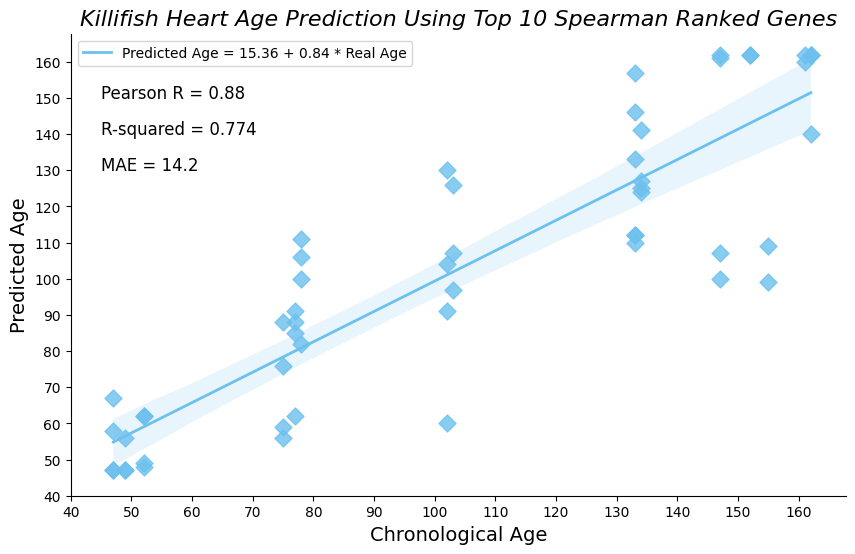

1
      prediction
A13_2      162.0
A14_2      109.0
A15_2       97.0
B13_2      125.0
B14_2       47.0
B15_2       63.0
B16_2      126.0
C13_2      156.0
C14_2      162.0
C15_2       51.0
C16_2      105.0
D13_2       97.0
D14_2      125.0
D15_2       89.0
D16_2       73.0
E13_2      143.0
E14_2       66.0
E15_2       60.0
E16_2       52.0
F13_2      104.0
F14_2      103.0
F15_2      100.0
F16_2       50.0
G13_2       58.0
G14_2       64.0
G15_2      139.0
G16_2       47.0
H13_2       49.0
H14_2      162.0
H15_2      118.0
I13_2       59.0
I14_2       73.0
I15_2      106.0
J13_2      124.0
J14_2       47.0
J15_2      160.0
K13_2       92.0
K14_2       78.0
K15_2      125.0
L13_2       87.0
L14_2      130.0
L15_2      162.0
M13_2      128.0
M14_2      110.0
M15_2      162.0
N13_2      113.0
N14_2      152.0
N15_2      162.0
O13_2       52.0
O14_2      112.0
O15_2      154.0
P13_2      145.0
P14_2       89.0
P15_2       92.0
[18.55766608  0.81144672]
                            OLS Regre

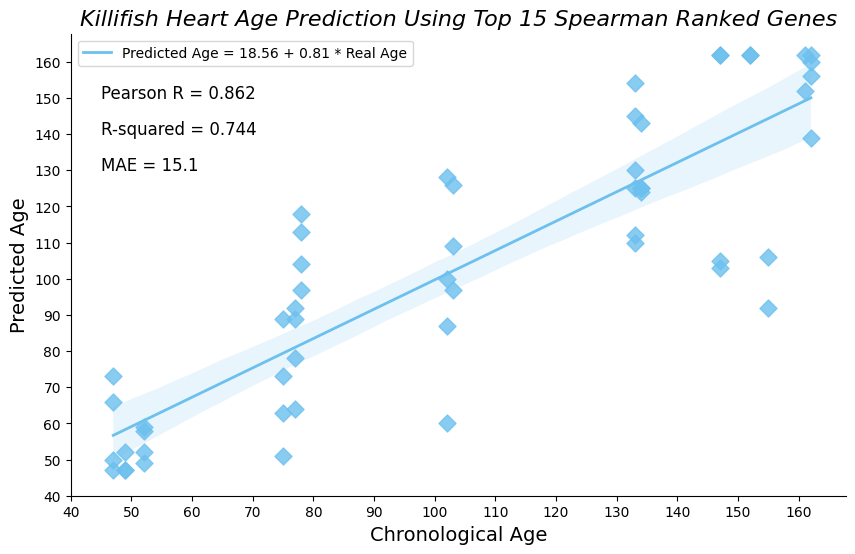

2
      prediction
A13_2      162.0
A14_2      107.0
A15_2       86.0
B13_2      115.0
B14_2       47.0
B15_2       64.0
B16_2      111.0
C13_2      145.0
C14_2      162.0
C15_2       62.0
C16_2      107.0
D13_2      100.0
D14_2      147.0
D15_2      105.0
D16_2       81.0
E13_2      143.0
E14_2       69.0
E15_2       60.0
E16_2       63.0
F13_2      112.0
F14_2      104.0
F15_2      105.0
F16_2       47.0
G13_2       62.0
G14_2       67.0
G15_2      136.0
G16_2       47.0
H13_2       48.0
H14_2      162.0
H15_2      115.0
I13_2       61.0
I14_2       73.0
I15_2       97.0
J13_2      109.0
J14_2       47.0
J15_2      158.0
K13_2       97.0
K14_2       78.0
K15_2      119.0
L13_2       88.0
L14_2      136.0
L15_2      162.0
M13_2      131.0
M14_2      112.0
M15_2      162.0
N13_2      113.0
N14_2      155.0
N15_2      158.0
O13_2       51.0
O14_2      106.0
O15_2      137.0
P13_2      147.0
P14_2       89.0
P15_2      116.0
[24.72601679  0.75761433]
                            OLS Regre

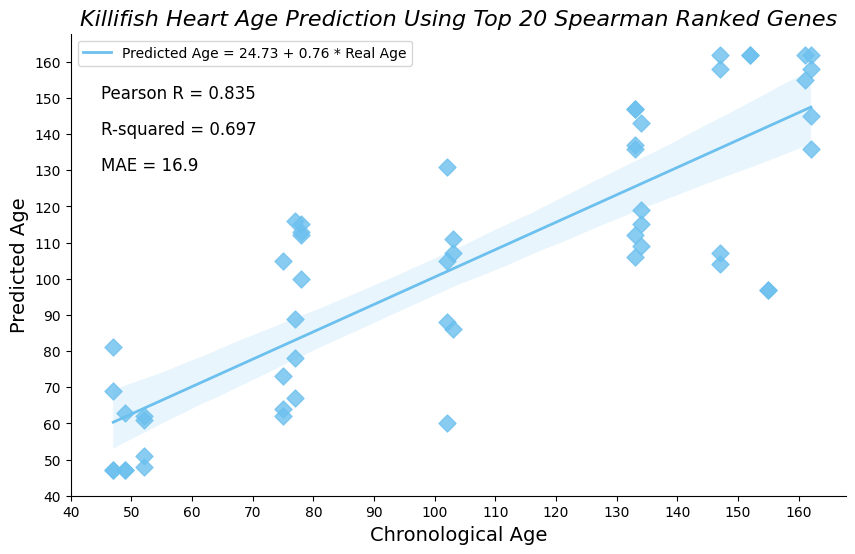

3
      prediction
A13_2      162.0
A14_2      111.0
A15_2       97.0
B13_2      118.0
B14_2       56.0
B15_2       59.0
B16_2      112.0
C13_2      140.0
C14_2      162.0
C15_2       62.0
C16_2      110.0
D13_2      122.0
D14_2      146.0
D15_2      122.0
D16_2       72.0
E13_2      145.0
E14_2       88.0
E15_2       60.0
E16_2       61.0
F13_2      112.0
F14_2      100.0
F15_2      109.0
F16_2       63.0
G13_2       60.0
G14_2       75.0
G15_2      139.0
G16_2       47.0
H13_2       47.0
H14_2      162.0
H15_2      124.0
I13_2       70.0
I14_2       70.0
I15_2       97.0
J13_2      109.0
J14_2       47.0
J15_2      155.0
K13_2      114.0
K14_2       70.0
K15_2      111.0
L13_2       95.0
L14_2      135.0
L15_2      162.0
M13_2      127.0
M14_2      105.0
M15_2      162.0
N13_2      115.0
N14_2      156.0
N15_2      141.0
O13_2       52.0
O14_2      109.0
O15_2      139.0
P13_2      147.0
P14_2       82.0
P15_2      117.0
[30.77803041  0.71543904]
                            OLS Regre

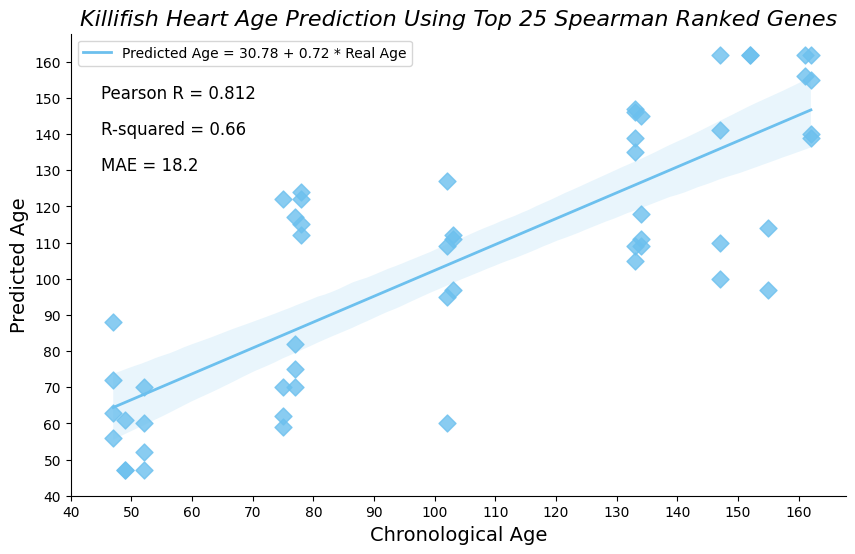

4
      prediction
A13_2      162.0
A14_2      111.0
A15_2      100.0
B13_2      115.0
B14_2       56.0
B15_2       59.0
B16_2      112.0
C13_2      131.0
C14_2      162.0
C15_2       62.0
C16_2      108.0
D13_2      122.0
D14_2      145.0
D15_2      106.0
D16_2       72.0
E13_2      146.0
E14_2       89.0
E15_2       92.0
E16_2       60.0
F13_2      108.0
F14_2      101.0
F15_2      109.0
F16_2       63.0
G13_2       58.0
G14_2       73.0
G15_2      146.0
G16_2       47.0
H13_2       47.0
H14_2      162.0
H15_2      125.0
I13_2       63.0
I14_2       70.0
I15_2      105.0
J13_2      111.0
J14_2       47.0
J15_2      150.0
K13_2      114.0
K14_2       70.0
K15_2      113.0
L13_2       86.0
L14_2      130.0
L15_2      162.0
M13_2      128.0
M14_2      108.0
M15_2      162.0
N13_2      112.0
N14_2      152.0
N15_2      143.0
O13_2       52.0
O14_2      111.0
O15_2      140.0
P13_2      147.0
P14_2       82.0
P15_2      117.0
[29.49649649  0.72655455]
                            OLS Regre

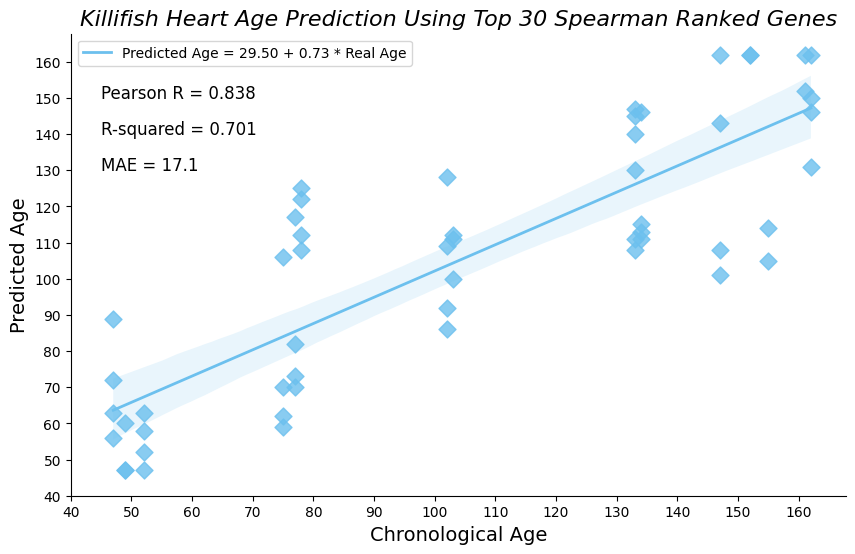

5
      prediction
A13_2      162.0
A14_2      113.0
A15_2      100.0
B13_2      117.0
B14_2       56.0
B15_2       57.0
B16_2      102.0
C13_2      131.0
C14_2      158.0
C15_2       62.0
C16_2      106.0
D13_2      122.0
D14_2      144.0
D15_2      107.0
D16_2       72.0
E13_2      146.0
E14_2       88.0
E15_2       92.0
E16_2       63.0
F13_2       65.0
F14_2       91.0
F15_2      111.0
F16_2       63.0
G13_2       63.0
G14_2       75.0
G15_2      146.0
G16_2       49.0
H13_2       47.0
H14_2      162.0
H15_2      125.0
I13_2       68.0
I14_2       71.0
I15_2      103.0
J13_2      111.0
J14_2       47.0
J15_2      148.0
K13_2      114.0
K14_2       70.0
K15_2      108.0
L13_2       84.0
L14_2      128.0
L15_2      162.0
M13_2      128.0
M14_2      109.0
M15_2      162.0
N13_2      113.0
N14_2      154.0
N15_2      142.0
O13_2       51.0
O14_2      117.0
O15_2      142.0
P13_2      149.0
P14_2       83.0
P15_2      117.0
[28.98955754  0.72292717]
                            OLS Regre

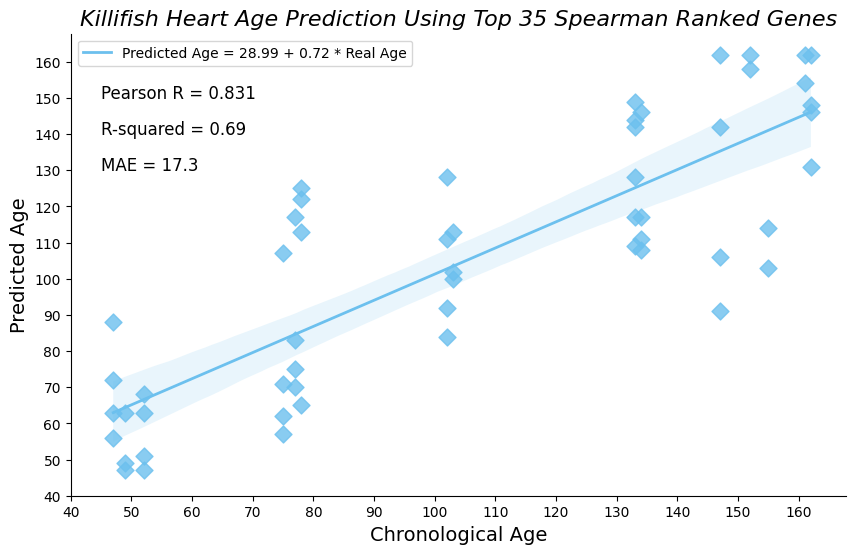

6
      prediction
A13_2      162.0
A14_2      113.0
A15_2       97.0
B13_2      118.0
B14_2       56.0
B15_2       55.0
B16_2      102.0
C13_2      142.0
C14_2      161.0
C15_2       62.0
C16_2      107.0
D13_2      122.0
D14_2      142.0
D15_2      124.0
D16_2       72.0
E13_2      147.0
E14_2       90.0
E15_2       97.0
E16_2       60.0
F13_2       65.0
F14_2       91.0
F15_2      110.0
F16_2       63.0
G13_2       61.0
G14_2       75.0
G15_2      145.0
G16_2       50.0
H13_2       47.0
H14_2      162.0
H15_2      131.0
I13_2       64.0
I14_2       70.0
I15_2      103.0
J13_2      107.0
J14_2       47.0
J15_2      147.0
K13_2      114.0
K14_2       70.0
K15_2      108.0
L13_2       85.0
L14_2      128.0
L15_2      162.0
M13_2      124.0
M14_2      108.0
M15_2      162.0
N13_2      115.0
N14_2      155.0
N15_2      144.0
O13_2       50.0
O14_2      120.0
O15_2      134.0
P13_2      150.0
P14_2       77.0
P15_2      116.0
[28.61953451  0.7287276 ]
                            OLS Regre

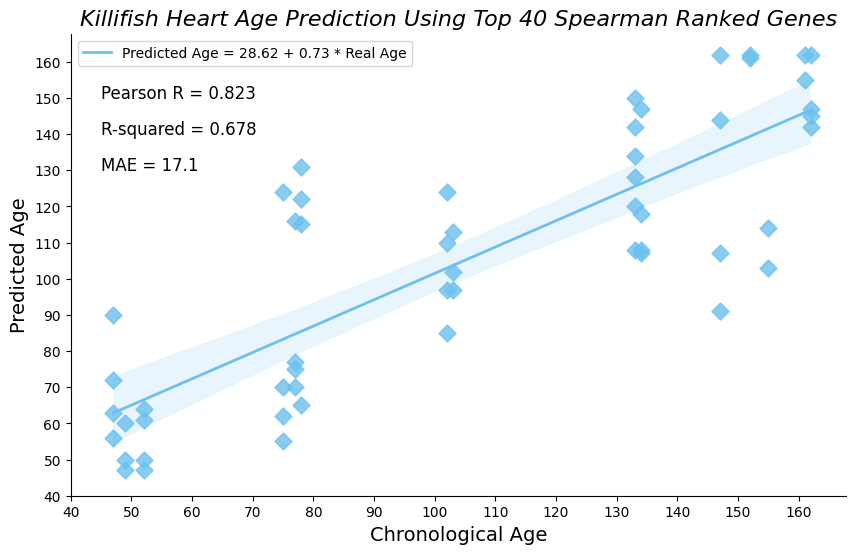

7
      prediction
A13_2      162.0
A14_2      109.0
A15_2       97.0
B13_2      118.0
B14_2       57.0
B15_2       54.0
B16_2      102.0
C13_2      139.0
C14_2      160.0
C15_2       62.0
C16_2      105.0
D13_2      122.0
D14_2      147.0
D15_2      124.0
D16_2       72.0
E13_2      150.0
E14_2       88.0
E15_2       98.0
E16_2       60.0
F13_2       65.0
F14_2       91.0
F15_2      113.0
F16_2       66.0
G13_2       60.0
G14_2       76.0
G15_2      144.0
G16_2       47.0
H13_2       47.0
H14_2      162.0
H15_2      127.0
I13_2       63.0
I14_2       70.0
I15_2       97.0
J13_2      108.0
J14_2       47.0
J15_2      146.0
K13_2      114.0
K14_2       70.0
K15_2      110.0
L13_2       85.0
L14_2      131.0
L15_2      157.0
M13_2      128.0
M14_2      110.0
M15_2      162.0
N13_2      114.0
N14_2      156.0
N15_2      145.0
O13_2       50.0
O14_2      120.0
O15_2      134.0
P13_2      151.0
P14_2       78.0
P15_2      117.0
[28.75967239  0.72704497]
                            OLS Regre

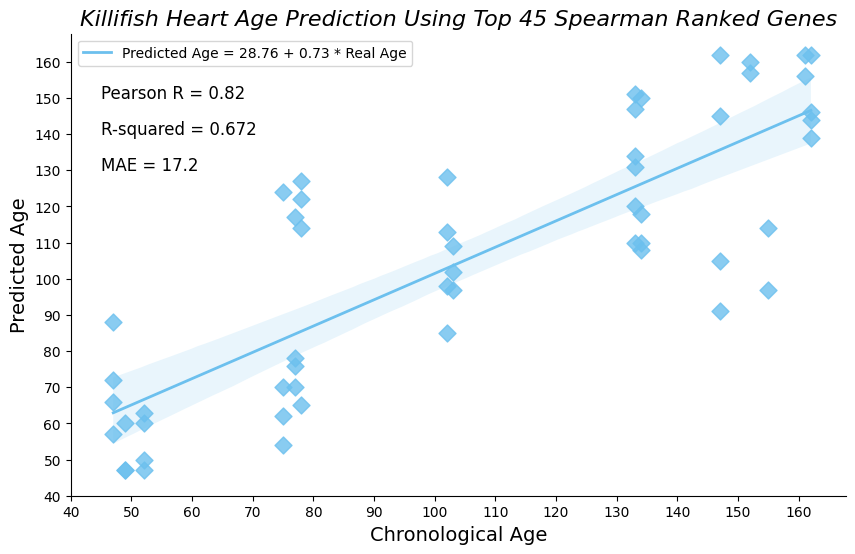

8
      prediction
A13_2      162.0
A14_2      109.0
A15_2       97.0
B13_2      116.0
B14_2       57.0
B15_2       54.0
B16_2      102.0
C13_2      135.0
C14_2      160.0
C15_2       62.0
C16_2      104.0
D13_2      127.0
D14_2      148.0
D15_2      112.0
D16_2       72.0
E13_2      150.0
E14_2       83.0
E15_2       98.0
E16_2       59.0
F13_2       65.0
F14_2       90.0
F15_2      112.0
F16_2       66.0
G13_2       60.0
G14_2       76.0
G15_2      145.0
G16_2       48.0
H13_2       47.0
H14_2      162.0
H15_2      128.0
I13_2       61.0
I14_2       70.0
I15_2      102.0
J13_2      108.0
J14_2       58.0
J15_2      151.0
K13_2      114.0
K14_2       70.0
K15_2      109.0
L13_2       84.0
L14_2      131.0
L15_2      157.0
M13_2      126.0
M14_2      108.0
M15_2      162.0
N13_2      114.0
N14_2      157.0
N15_2      145.0
O13_2       50.0
O14_2      120.0
O15_2      135.0
P13_2      151.0
P14_2       79.0
P15_2      117.0
[28.46831367  0.72946026]
                            OLS Regre

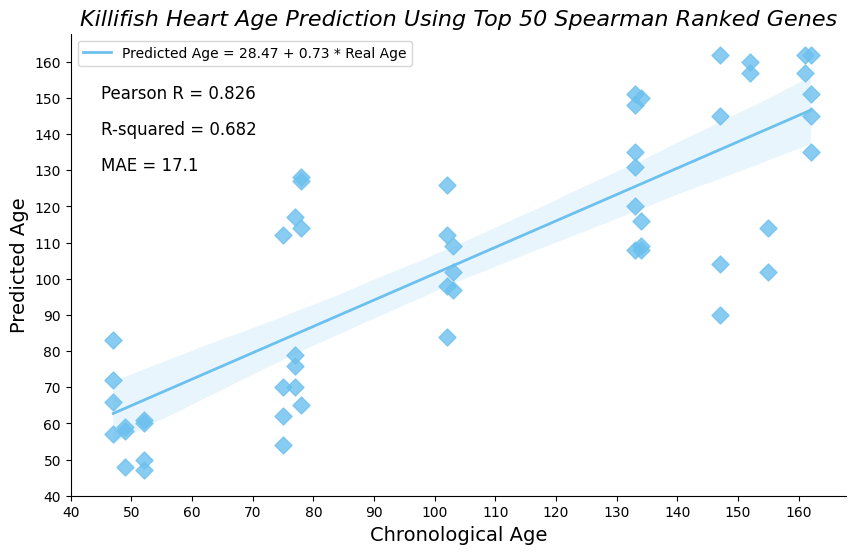

9


In [ ]:
gene_number_test = [10, 15, 20, 25, 30, 35, 40, 45, 50]

counter = 0

for number in gene_number_test:

    gene_number = number

    # Initialize DataFrame for predictions
    heart_predicted_ages = pd.DataFrame(index=heart_df_age.index, columns=["prediction"])

    # Iterate through each sample in the DataFrame
    for sample in heart_df_age.index.tolist():

        # Read the spearman and frequency data for the current sample
        #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
        df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/heart/reference/heart_reference_{sample}", sep="\t")
        df_frequency.set_index("Gene", inplace=True)

        # Get top genes based on spearman correlation
        top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
        top_genes = top_absolute_spearman_correlation.index.tolist()
        #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

        total_reads_sample = df_unnorm.loc[sample].sum()

        list_of_profile_probabilities_per_age = []

        # Iterate through each age step
        for age in new_heart_age_steps:

            probability_list_one_age = []
            genes_not_defined = []

            # Iterate through each gene for the sample
            for gene in top_genes:

                gene_frequency = df_frequency.loc[gene, f"{age}"]

                # Replace negative gene frequency with 10^-10
                if gene_frequency < 0:
                    gene_frequency = 10**-10

                sample_expected_counts = gene_frequency * total_reads_sample
                sample_observed_counts = df_unnorm.loc[sample, gene]

                poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

                # Replace NaN poisson probability with a small positive value and log it
                if np.isnan(poisson_probability):
                    poisson_probability = 0.001
                    genes_not_defined.append(gene)

                # Replace zero poisson probability with 0.001
                if poisson_probability == 0:
                    poisson_probability = 0.001

                logP = np.log(poisson_probability)

                probability_list_one_age.append(logP)

            list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

        # transform into dataframe with age steps
        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_heart_age_steps)

        # Compute highest likelihood age among age steps
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

        # Compute highest maximum probability
        max_probability = float(age_probability_df["Pr"].max())

        heart_predicted_ages.loc[sample, "prediction"] = max_probability_age

    # Print the resulting DataFrame
    print(heart_predicted_ages)

    heart_predicted_ages["true_age"] = heart_df_age["age"].tolist()

    heart_df_model = sm.OLS(heart_predicted_ages["prediction"].tolist(), sm.add_constant(heart_predicted_ages["true_age"].tolist()))

    heart_df_results = heart_df_model.fit()

    print(heart_df_results.params)
    print(heart_df_results.summary())

    b, m = heart_df_results.params

    MAE = mae(heart_predicted_ages["true_age"].tolist(), heart_predicted_ages["prediction"].tolist())

    print(MAE)

    heart_correlation_coefficient, heart_p_value = pearsonr(heart_predicted_ages["true_age"].tolist(), heart_predicted_ages["prediction"].tolist())

    heart_correlation_coefficient

    # Ensure the 'age' and 'prediction' columns are numeric
    heart_predicted_ages['age'] = pd.to_numeric(heart_predicted_ages['true_age'], errors='coerce')
    heart_predicted_ages['prediction'] = pd.to_numeric(heart_predicted_ages['prediction'], errors='coerce')

    # Drop rows with NaN values in 'age' or 'prediction' columns
    heart_df_female_predictions = heart_predicted_ages.dropna(subset=['age', 'prediction'])

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(heart_predicted_ages['age'], heart_predicted_ages['prediction'])

    # Calculate Pearson R, R-squared, and MAE
    heart_correlation_coefficient = r_value
    cod = r_value ** 2
    MAE = mae(heart_predicted_ages['age'], heart_predicted_ages['prediction'])

    # Formatting variables to three significant figures
    heart_correlation_coefficient = f"{heart_correlation_coefficient:.3g}"
    cod = f"{cod:.3g}"
    MAE = f"{MAE:.3g}"


    print(f"Performance for Gene Number: {gene_number}")
    print(f"Pearson Correlation: {heart_correlation_coefficient}")
    print(f"Coefficient of Determination: {cod}")
    print(f"Mean Absolute Error: {MAE}")

    counter += 1
    # Plotting the scatter plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.regplot(x="age",
            y="prediction",
            data=heart_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
    sns.despine(right=True)

    x_tick = np.arange(40, 170, 10)
    y_tick = np.arange(40, 170, 10)

    plt.xticks(x_tick)
    plt.yticks(y_tick)

    # Perason Correlation
    plt.text(45, 150, f"Pearson R = {heart_correlation_coefficient}", fontsize=12, color="black")

    #R-squared
    plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

    # Adding MAE text
    plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

    # Changing the names and sizes of x and y-axis labels
    plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
    plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

    # Changing the size of the title
    plt.title(f'Killifish Heart Age Prediction Using Top {gene_number} Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

    # Display the legend
    plt.legend()

    # Save the plot as a publication-ready image (e.g., PNG)
    #plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

    plt.show()

    print(counter)

# Muscle

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/muscle/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
muscle_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "Muscle"]

muscle_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A13_1,0,192,56,302,204,435,376,1219,322,298,...,40,375,5,547,654,126,147,M,Muscle,134
A14_1,0,173,92,333,196,448,419,1127,368,354,...,30,472,6,613,841,241,182,M,Muscle,147
A15_1,0,104,34,194,98,233,131,592,210,122,...,38,228,2,273,370,58,82,M,Muscle,52
A16_1,0,295,51,556,222,578,542,1368,793,459,...,84,376,4,588,765,65,268,F,Muscle,103
B13_1,0,284,55,465,270,571,563,1390,553,447,...,69,385,4,691,966,145,200,F,Muscle,155


In [ ]:
muscle_age_days_value_counts = muscle_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
muscle_age_steps = sorted(muscle_age_days_value_counts)

print(muscle_age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
muscle_gene_expression_data = muscle_df_counts.iloc[:, :-3]

In [ ]:
muscle_df_age = muscle_gene_expression_data.copy()

In [ ]:
muscle_df_age["age"] = muscle_df_counts["age_days"].tolist()

muscle_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_1,0,192,56,302,204,435,376,1219,322,298,...,21,440,40,375,5,547,654,126,147,134
A14_1,0,173,92,333,196,448,419,1127,368,354,...,22,510,30,472,6,613,841,241,182,147
A15_1,0,104,34,194,98,233,131,592,210,122,...,7,228,38,228,2,273,370,58,82,52


In [ ]:
muscle_df_age.shape

(55, 25123)

In [ ]:
#for sample in muscle_df_age.index.tolist():

#    new_df = muscle_df_age.drop(sample)

#    new_df.to_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/muscle/sample/muscle_sample_{sample}.csv", sep="\t")

#    print(new_df.shape)

(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)


In [ ]:
new_muscle_age_steps = np.arange(min(muscle_age_steps), max(muscle_age_steps)+1, 1)

In [ ]:
#counter = 0

#for sample in muscle_df_age.index.tolist():

#    transcriptome_reference(training_matrix=f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/muscle/sample/muscle_sample_{sample}.csv",
#                            reference_name=f"muscle_reference_{sample}",
#                            output_path="/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/muscle/reference/",
#                            age_prediction="list",
#                            age_list=new_muscle_age_steps,
#                            min_age=1,
#                            max_age=24,
#                            age_step=1,
#                            tau=0.7)

#    counter += 1

#    print(counter)

#### Muscle Age Prediction

      prediction
A13_1      128.0
A14_1      145.0
A15_1       53.0
A16_1      162.0
B13_1      140.0
B14_1       57.0
B15_1      162.0
B16_1      116.0
C13_1      155.0
C14_1       47.0
C15_1       88.0
C16_1       59.0
D13_1       94.0
D14_1      127.0
D15_1       82.0
D16_1      162.0
E13_1       91.0
E14_1      152.0
E15_1      117.0
E16_1      115.0
F13_1      162.0
F14_1      138.0
F15_1      162.0
F16_1       47.0
G13_1      108.0
G14_1       85.0
G15_1       47.0
G16_1       79.0
H13_1       52.0
H14_1      141.0
H15_1       47.0
I13_1       57.0
I14_1      126.0
I15_1      105.0
J13_1       80.0
J14_1      108.0
J15_1      154.0
K13_1      107.0
K14_1      122.0
K15_1       54.0
L13_1      159.0
L14_1       47.0
L15_1       72.0
M13_1       54.0
M14_1      120.0
M15_1      153.0
N13_1      114.0
N14_1      151.0
N15_1       65.0
O13_1       64.0
O14_1      131.0
O15_1      162.0
P13_1       78.0
P14_1      162.0
P15_1       54.0
[16.81918355  0.85334698]
                      

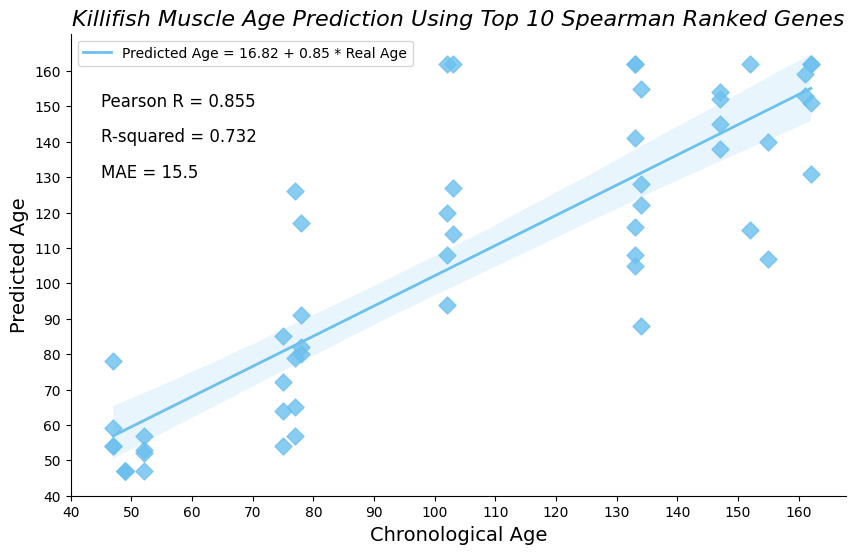

1
      prediction
A13_1      131.0
A14_1      143.0
A15_1       53.0
A16_1      162.0
B13_1      142.0
B14_1       57.0
B15_1      139.0
B16_1       96.0
C13_1      143.0
C14_1       47.0
C15_1       90.0
C16_1       62.0
D13_1      103.0
D14_1      139.0
D15_1       80.0
D16_1       50.0
E13_1       96.0
E14_1      141.0
E15_1      118.0
E16_1      114.0
F13_1      160.0
F14_1      139.0
F15_1      162.0
F16_1       47.0
G13_1      105.0
G14_1       86.0
G15_1       47.0
G16_1       79.0
H13_1       49.0
H14_1      117.0
H15_1       47.0
I13_1       55.0
I14_1       74.0
I15_1      103.0
J13_1       77.0
J14_1      101.0
J15_1      153.0
K13_1      108.0
K14_1      124.0
K15_1       55.0
L13_1      162.0
L14_1       48.0
L15_1       72.0
M13_1       57.0
M14_1      118.0
M15_1      152.0
N13_1      120.0
N14_1      160.0
N15_1       65.0
O13_1       70.0
O14_1      127.0
O15_1      162.0
P13_1       74.0
P14_1       71.0
P15_1       56.0
[24.09363454  0.72935486]
                    

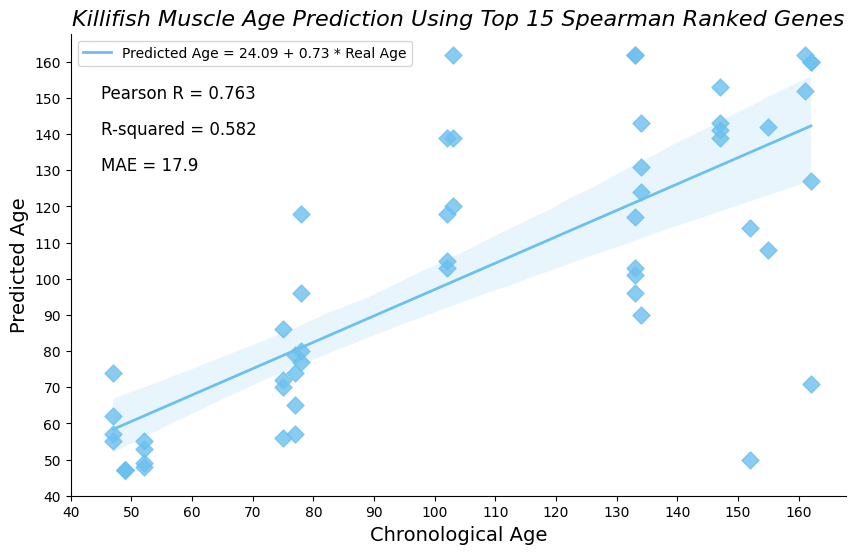

2
      prediction
A13_1      129.0
A14_1      157.0
A15_1       47.0
A16_1      162.0
B13_1      141.0
B14_1       56.0
B15_1      143.0
B16_1       87.0
C13_1      152.0
C14_1       47.0
C15_1       90.0
C16_1       63.0
D13_1       97.0
D14_1      136.0
D15_1       81.0
D16_1       50.0
E13_1      103.0
E14_1      144.0
E15_1      115.0
E16_1      118.0
F13_1      160.0
F14_1      135.0
F15_1      162.0
F16_1       47.0
G13_1      101.0
G14_1       84.0
G15_1       47.0
G16_1       70.0
H13_1       48.0
H14_1      162.0
H15_1       47.0
I13_1       50.0
I14_1       84.0
I15_1       84.0
J13_1       81.0
J14_1      100.0
J15_1      162.0
K13_1      114.0
K14_1      138.0
K15_1       56.0
L13_1      162.0
L14_1       47.0
L15_1       65.0
M13_1       51.0
M14_1      116.0
M15_1      132.0
N13_1      123.0
N14_1      162.0
N15_1       71.0
O13_1       63.0
O14_1      132.0
O15_1      162.0
P13_1       74.0
P14_1       70.0
P15_1       55.0
[21.47575374  0.75916888]
                    

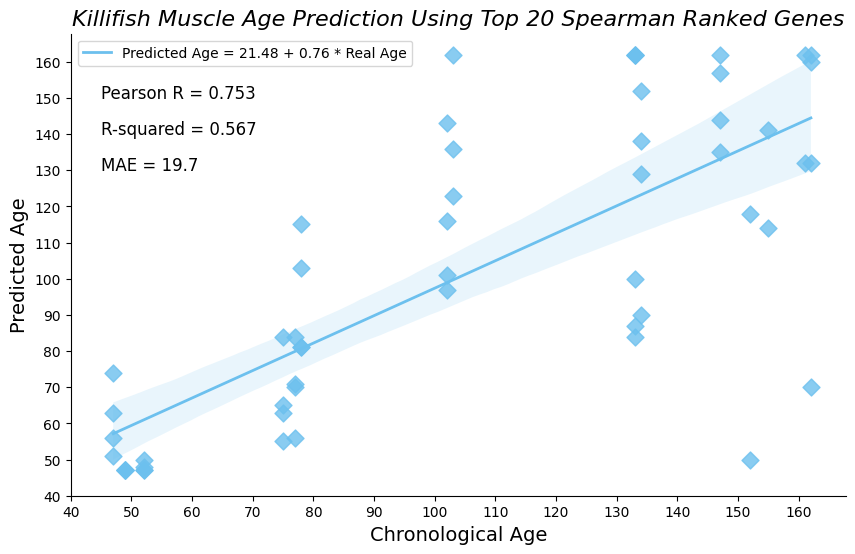

3
      prediction
A13_1      132.0
A14_1      155.0
A15_1       48.0
A16_1      162.0
B13_1      138.0
B14_1       56.0
B15_1      142.0
B16_1       88.0
C13_1      157.0
C14_1       47.0
C15_1       89.0
C16_1       57.0
D13_1       97.0
D14_1      135.0
D15_1       79.0
D16_1       49.0
E13_1      103.0
E14_1      140.0
E15_1      113.0
E16_1      122.0
F13_1      162.0
F14_1      133.0
F15_1      162.0
F16_1       47.0
G13_1      104.0
G14_1       79.0
G15_1       47.0
G16_1       71.0
H13_1       48.0
H14_1      162.0
H15_1       47.0
I13_1       51.0
I14_1       91.0
I15_1       84.0
J13_1       79.0
J14_1      100.0
J15_1      159.0
K13_1      113.0
K14_1      134.0
K15_1       56.0
L13_1      162.0
L14_1       47.0
L15_1       68.0
M13_1       51.0
M14_1      110.0
M15_1      132.0
N13_1      118.0
N14_1      162.0
N15_1       70.0
O13_1       62.0
O14_1      132.0
O15_1      162.0
P13_1       66.0
P14_1       70.0
P15_1       56.0
[20.43938807  0.7640512 ]
                    

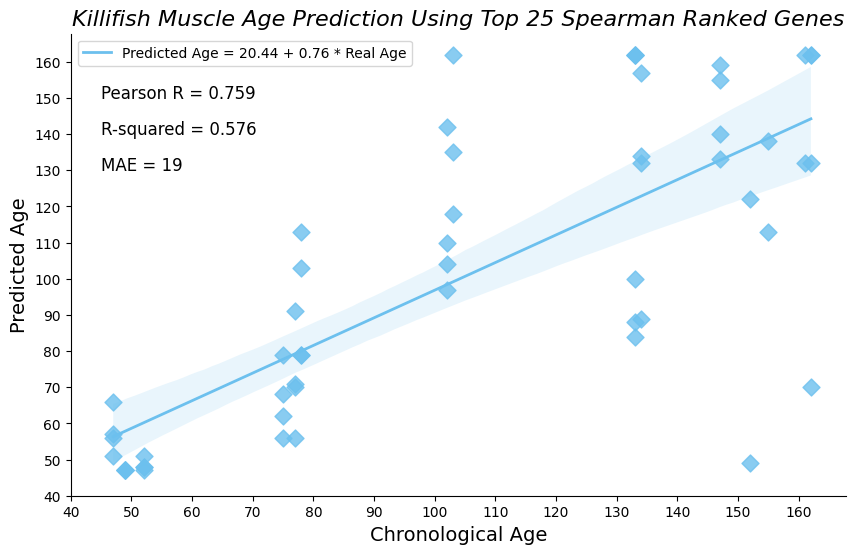

4
      prediction
A13_1      152.0
A14_1      156.0
A15_1       48.0
A16_1      162.0
B13_1      136.0
B14_1       56.0
B15_1      138.0
B16_1       89.0
C13_1      157.0
C14_1       47.0
C15_1       88.0
C16_1       59.0
D13_1       96.0
D14_1      116.0
D15_1       79.0
D16_1       48.0
E13_1      103.0
E14_1      133.0
E15_1      114.0
E16_1      114.0
F13_1      147.0
F14_1      128.0
F15_1      162.0
F16_1       47.0
G13_1      101.0
G14_1       79.0
G15_1       47.0
G16_1       72.0
H13_1       48.0
H14_1      161.0
H15_1       47.0
I13_1       50.0
I14_1       91.0
I15_1       84.0
J13_1       79.0
J14_1       99.0
J15_1      161.0
K13_1      113.0
K14_1      125.0
K15_1       61.0
L13_1      162.0
L14_1       48.0
L15_1       68.0
M13_1       54.0
M14_1      110.0
M15_1      132.0
N13_1      119.0
N14_1      162.0
N15_1       70.0
O13_1       60.0
O14_1      130.0
O15_1      162.0
P13_1       66.0
P14_1      161.0
P15_1       56.0
[17.73279072  0.7982034 ]
                    

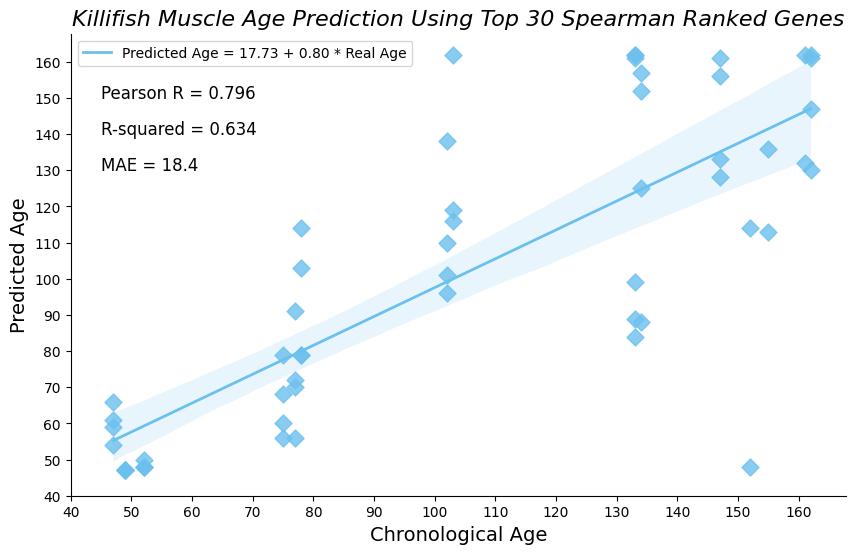

5
      prediction
A13_1      152.0
A14_1      155.0
A15_1       48.0
A16_1      162.0
B13_1      134.0
B14_1       55.0
B15_1      143.0
B16_1       89.0
C13_1      162.0
C14_1       47.0
C15_1       88.0
C16_1       59.0
D13_1       96.0
D14_1      146.0
D15_1       67.0
D16_1      162.0
E13_1      103.0
E14_1      129.0
E15_1      115.0
E16_1      118.0
F13_1      148.0
F14_1      126.0
F15_1      162.0
F16_1       47.0
G13_1      100.0
G14_1       79.0
G15_1       50.0
G16_1       65.0
H13_1       51.0
H14_1      151.0
H15_1       49.0
I13_1       49.0
I14_1       90.0
I15_1       84.0
J13_1       79.0
J14_1       99.0
J15_1      158.0
K13_1      110.0
K14_1      123.0
K15_1       60.0
L13_1      162.0
L14_1       47.0
L15_1       68.0
M13_1       54.0
M14_1      113.0
M15_1      126.0
N13_1      120.0
N14_1      162.0
N15_1       81.0
O13_1       60.0
O14_1      133.0
O15_1      162.0
P13_1       64.0
P14_1      161.0
P15_1       56.0
[14.6608779   0.84963413]
                    

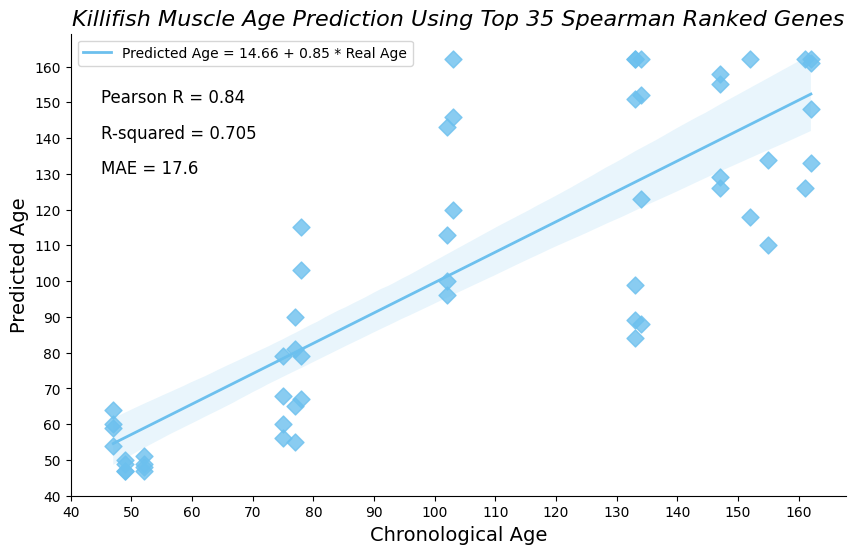

6
      prediction
A13_1      152.0
A14_1      157.0
A15_1       48.0
A16_1      162.0
B13_1      134.0
B14_1       55.0
B15_1      144.0
B16_1       90.0
C13_1      162.0
C14_1       47.0
C15_1       88.0
C16_1       58.0
D13_1      110.0
D14_1      148.0
D15_1       67.0
D16_1      162.0
E13_1      103.0
E14_1      127.0
E15_1      115.0
E16_1      118.0
F13_1      150.0
F14_1      118.0
F15_1      156.0
F16_1       47.0
G13_1      106.0
G14_1       79.0
G15_1       50.0
G16_1       79.0
H13_1       51.0
H14_1      151.0
H15_1       49.0
I13_1       49.0
I14_1       79.0
I15_1       82.0
J13_1       84.0
J14_1      103.0
J15_1      162.0
K13_1      110.0
K14_1      111.0
K15_1       59.0
L13_1      154.0
L14_1       47.0
L15_1       68.0
M13_1       54.0
M14_1      114.0
M15_1      126.0
N13_1      117.0
N14_1      149.0
N15_1       65.0
O13_1       56.0
O14_1      135.0
O15_1      162.0
P13_1       64.0
P14_1      161.0
P15_1       56.0
[15.49118637  0.8366146 ]
                    

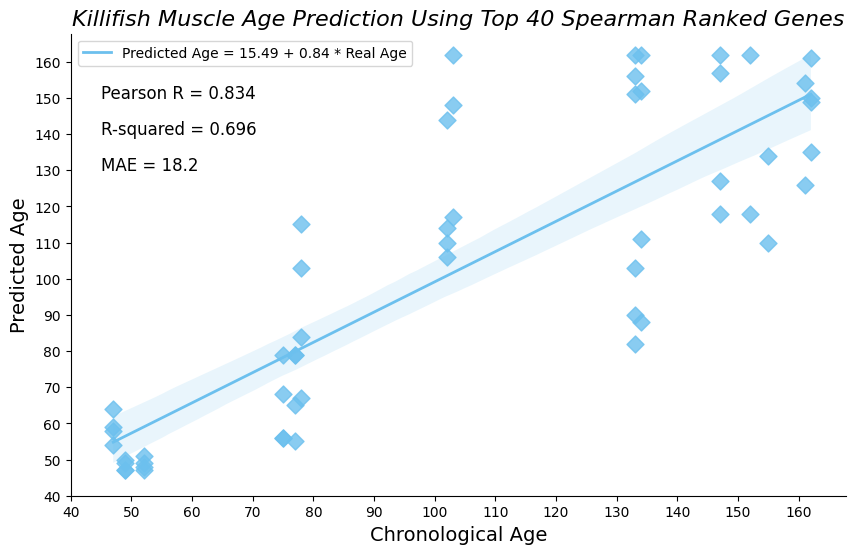

7
      prediction
A13_1      152.0
A14_1      157.0
A15_1       48.0
A16_1      155.0
B13_1      133.0
B14_1       54.0
B15_1      144.0
B16_1       84.0
C13_1      162.0
C14_1       47.0
C15_1       91.0
C16_1       58.0
D13_1      108.0
D14_1      142.0
D15_1       88.0
D16_1       48.0
E13_1      103.0
E14_1      135.0
E15_1      116.0
E16_1      118.0
F13_1      155.0
F14_1      110.0
F15_1      157.0
F16_1       47.0
G13_1      107.0
G14_1       77.0
G15_1       50.0
G16_1       79.0
H13_1       50.0
H14_1      154.0
H15_1       49.0
I13_1       49.0
I14_1       79.0
I15_1       82.0
J13_1       84.0
J14_1      104.0
J15_1      162.0
K13_1      109.0
K14_1       85.0
K15_1       59.0
L13_1      154.0
L14_1       47.0
L15_1       64.0
M13_1       52.0
M14_1      115.0
M15_1      161.0
N13_1      115.0
N14_1      149.0
N15_1       66.0
O13_1       57.0
O14_1      134.0
O15_1      162.0
P13_1       64.0
P14_1      161.0
P15_1       55.0
[18.5091788   0.78971145]
                    

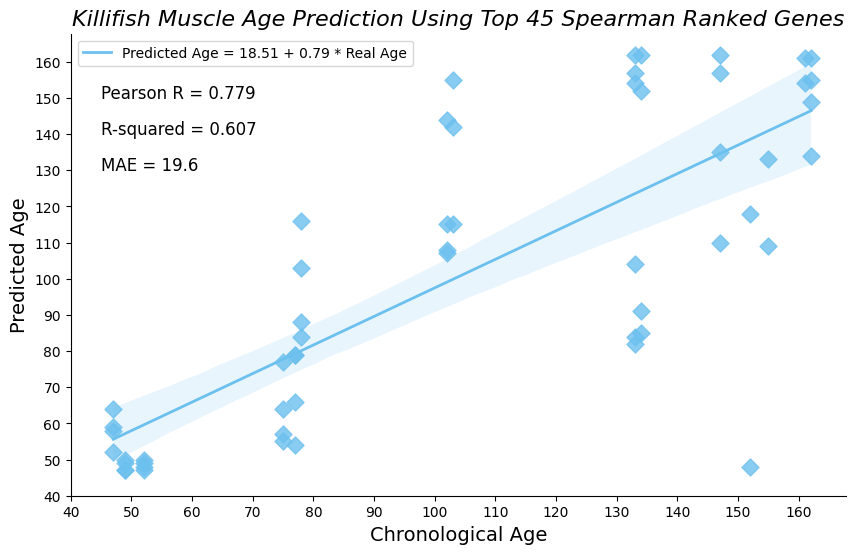

8
      prediction
A13_1      152.0
A14_1      157.0
A15_1       49.0
A16_1      157.0
B13_1      133.0
B14_1       54.0
B15_1      143.0
B16_1       84.0
C13_1      162.0
C14_1       47.0
C15_1       91.0
C16_1       58.0
D13_1       83.0
D14_1      138.0
D15_1       88.0
D16_1      162.0
E13_1      103.0
E14_1      145.0
E15_1      114.0
E16_1      118.0
F13_1      156.0
F14_1      110.0
F15_1      159.0
F16_1       47.0
G13_1      107.0
G14_1       77.0
G15_1       50.0
G16_1       78.0
H13_1       50.0
H14_1      154.0
H15_1       49.0
I13_1       49.0
I14_1       98.0
I15_1      115.0
J13_1       84.0
J14_1      104.0
J15_1      162.0
K13_1      110.0
K14_1      142.0
K15_1       60.0
L13_1      154.0
L14_1       47.0
L15_1       65.0
M13_1       52.0
M14_1      115.0
M15_1      162.0
N13_1      116.0
N14_1      162.0
N15_1       65.0
O13_1       72.0
O14_1      126.0
O15_1      162.0
P13_1       64.0
P14_1      161.0
P15_1       57.0
[13.4920049   0.87828069]
                    

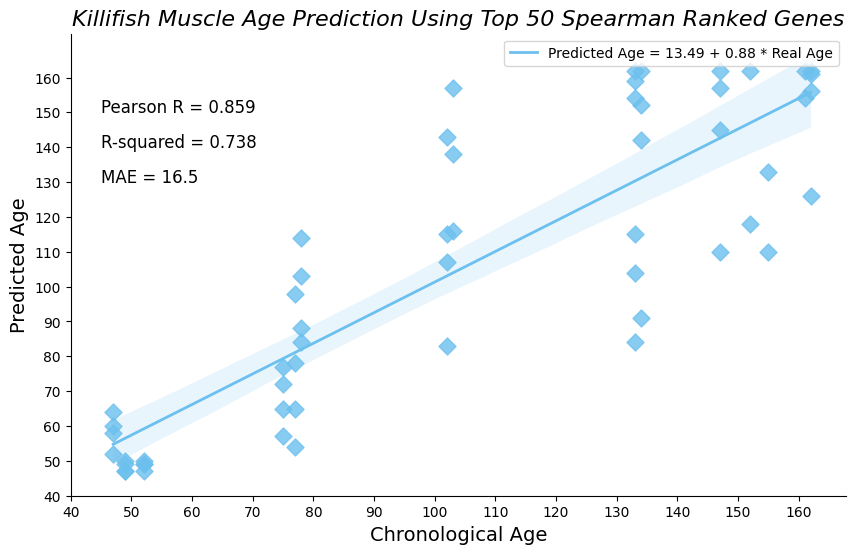

9


In [ ]:
gene_number_test = [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]

counter = 0

for number in gene_number_test:

    gene_number = number

    # Initialize DataFrame for predictions
    muscle_predicted_ages = pd.DataFrame(index=muscle_df_age.index, columns=["prediction"])

    # Iterate through each sample in the DataFrame
    for sample in muscle_df_age.index.tolist():

        # Read the spearman and frequency data for the current sample
        #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
        df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/muscle/reference/muscle_reference_{sample}", sep="\t")
        df_frequency.set_index("Gene", inplace=True)

        # Get top genes based on spearman correlation
        top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
        top_genes = top_absolute_spearman_correlation.index.tolist()
        #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

        total_reads_sample = df_unnorm.loc[sample].sum()

        list_of_profile_probabilities_per_age = []

        # Iterate through each age step
        for age in new_muscle_age_steps:

            probability_list_one_age = []
            genes_not_defined = []

            # Iterate through each gene for the sample
            for gene in top_genes:

                gene_frequency = df_frequency.loc[gene, f"{age}"]

                # Replace negative gene frequency with 10^-10
                if gene_frequency < 0:
                    gene_frequency = 10**-10

                sample_expected_counts = gene_frequency * total_reads_sample
                sample_observed_counts = df_unnorm.loc[sample, gene]

                poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

                # Replace NaN poisson probability with a small positive value and log it
                if np.isnan(poisson_probability):
                    poisson_probability = 0.001
                    genes_not_defined.append(gene)

                # Replace zero poisson probability with 0.001
                if poisson_probability == 0:
                    poisson_probability = 0.001

                logP = np.log(poisson_probability)

                probability_list_one_age.append(logP)

            list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

        # transform into dataframe with age steps
        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_muscle_age_steps)

        # Compute highest likelihood age among age steps
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

        # Compute highest maximum probability
        max_probability = float(age_probability_df["Pr"].max())

        muscle_predicted_ages.loc[sample, "prediction"] = max_probability_age

    # Print the resulting DataFrame
    print(muscle_predicted_ages)

    muscle_predicted_ages["true_age"] = muscle_df_age["age"].tolist()

    muscle_df_model = sm.OLS(muscle_predicted_ages["prediction"].tolist(), sm.add_constant(muscle_predicted_ages["true_age"].tolist()))

    muscle_df_results = muscle_df_model.fit()

    print(muscle_df_results.params)
    print(muscle_df_results.summary())

    b, m = muscle_df_results.params

    MAE = mae(muscle_predicted_ages["true_age"].tolist(), muscle_predicted_ages["prediction"].tolist())

    print(MAE)

    muscle_correlation_coefficient, muscle_p_value = pearsonr(muscle_predicted_ages["true_age"].tolist(), muscle_predicted_ages["prediction"].tolist())

    muscle_correlation_coefficient

    # Ensure the 'age' and 'prediction' columns are numeric
    muscle_predicted_ages['age'] = pd.to_numeric(muscle_predicted_ages['true_age'], errors='coerce')
    muscle_predicted_ages['prediction'] = pd.to_numeric(muscle_predicted_ages['prediction'], errors='coerce')

    # Drop rows with NaN values in 'age' or 'prediction' columns
    muscle_df_female_predictions = muscle_predicted_ages.dropna(subset=['age', 'prediction'])

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(muscle_predicted_ages['age'], muscle_predicted_ages['prediction'])

    # Calculate Pearson R, R-squared, and MAE
    muscle_correlation_coefficient = r_value
    cod = r_value ** 2
    MAE = mae(muscle_predicted_ages['age'], muscle_predicted_ages['prediction'])

    # Formatting variables to three significant figures
    muscle_correlation_coefficient = f"{muscle_correlation_coefficient:.3g}"
    cod = f"{cod:.3g}"
    MAE = f"{MAE:.3g}"


    print(f"Performance for Gene Number: {gene_number}")
    print(f"Pearson Correlation: {muscle_correlation_coefficient}")
    print(f"Coefficient of Determination: {cod}")
    print(f"Mean Absolute Error: {MAE}")

    counter += 1
    # Plotting the scatter plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.regplot(x="age",
            y="prediction",
            data=muscle_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
    sns.despine(right=True)

    x_tick = np.arange(40, 170, 10)
    y_tick = np.arange(40, 170, 10)

    plt.xticks(x_tick)
    plt.yticks(y_tick)

    # Perason Correlation
    plt.text(45, 150, f"Pearson R = {muscle_correlation_coefficient}", fontsize=12, color="black")

    #R-squared
    plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

    # Adding MAE text
    plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

    # Changing the names and sizes of x and y-axis labels
    plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
    plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

    # Changing the size of the title
    plt.title(f'Killifish Muscle Age Prediction Using Top {gene_number} Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

    # Display the legend
    plt.legend()

    # Save the plot as a publication-ready image (e.g., PNG)
    #plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

    plt.show()

    print(counter)

# Spleen

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/spleen/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
spleen_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "Spleen"]

spleen_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A17_2,705,860,359,508,1635,1087,1879,1122,1136,1021,...,242,2250,116,683,2290,152,580,F,Spleen,78
A18_2,184,815,128,647,588,997,3422,1386,815,1152,...,252,1499,24,914,6078,571,714,M,Spleen,152
A19_2,11,650,168,372,599,580,1650,804,360,533,...,203,1100,40,491,3200,231,549,F,Spleen,155
A20_2,291,840,136,402,654,906,1414,729,716,1088,...,150,1835,207,492,2984,196,437,M,Spleen,47
B17_2,165,1017,158,308,703,969,2398,918,875,1099,...,379,1461,114,744,14961,721,590,M,Spleen,102


In [ ]:
spleen_age_days_value_counts = spleen_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
spleen_age_steps = sorted(spleen_age_days_value_counts)

print(spleen_age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
spleen_gene_expression_data = spleen_df_counts.iloc[:, :-3]

In [ ]:
spleen_df_age = spleen_gene_expression_data.copy()

In [ ]:
spleen_df_age["age"] = spleen_df_counts["age_days"].tolist()

spleen_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A17_2,705,860,359,508,1635,1087,1879,1122,1136,1021,...,193,1754,242,2250,116,683,2290,152,580,78
A18_2,184,815,128,647,588,997,3422,1386,815,1152,...,206,2023,252,1499,24,914,6078,571,714,152
A19_2,11,650,168,372,599,580,1650,804,360,533,...,87,1231,203,1100,40,491,3200,231,549,155


In [ ]:
#for sample in spleen_df_age.index.tolist():

#    new_df = spleen_df_age.drop(sample)

#    new_df.to_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/spleen/sample/spleen_sample_{sample}.csv", sep="\t")

#    print(new_df.shape)

(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)
(54, 25123)


In [ ]:
new_spleen_age_steps = np.arange(min(spleen_age_steps), max(spleen_age_steps) + 1, 1)

In [ ]:
#counter = 0

#for sample in spleen_df_age.index.tolist():

#    transcriptome_reference(training_matrix=f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/spleen/sample/spleen_sample_{sample}.csv",
#                            reference_name=f"spleen_reference_{sample}",
#                            output_path="/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/spleen/reference/",
#                            age_prediction="list",
#                            age_list=new_spleen_age_steps,
#                            min_age=1,
#                            max_age=24,
#                            age_step=1,
#                            tau=0.7)

#    counter += 1

#    print(counter)

#### Spleen Age Prediction

      prediction
A17_2       90.0
A18_2      108.0
A19_2      113.0
A20_2      153.0
B17_2      111.0
B18_2      122.0
B19_2       95.0
B20_2      162.0
C17_2      106.0
C18_2      139.0
C19_2      162.0
C20_2       58.0
D17_2      102.0
D18_2       85.0
D19_2      162.0
D20_2       47.0
E17_2       81.0
E18_2      105.0
E19_2       90.0
E20_2       69.0
F17_2      162.0
F18_2       83.0
F19_2       58.0
F20_2      162.0
G17_2      106.0
G18_2      157.0
G19_2      108.0
G20_2      110.0
H17_2      102.0
H18_2      111.0
H19_2      162.0
I17_2      105.0
I18_2      116.0
I19_2      105.0
J17_2       91.0
J18_2      110.0
J19_2       54.0
K17_2       85.0
K18_2      148.0
K19_2       84.0
L17_2       97.0
L18_2       54.0
L19_2       83.0
M17_2       75.0
M18_2      162.0
M19_2       47.0
N17_2      162.0
N18_2       47.0
N19_2       97.0
O17_2      111.0
O18_2       78.0
O19_2      112.0
P17_2      115.0
P18_2      142.0
P19_2       77.0
[54.86040049  0.49183574]
                      

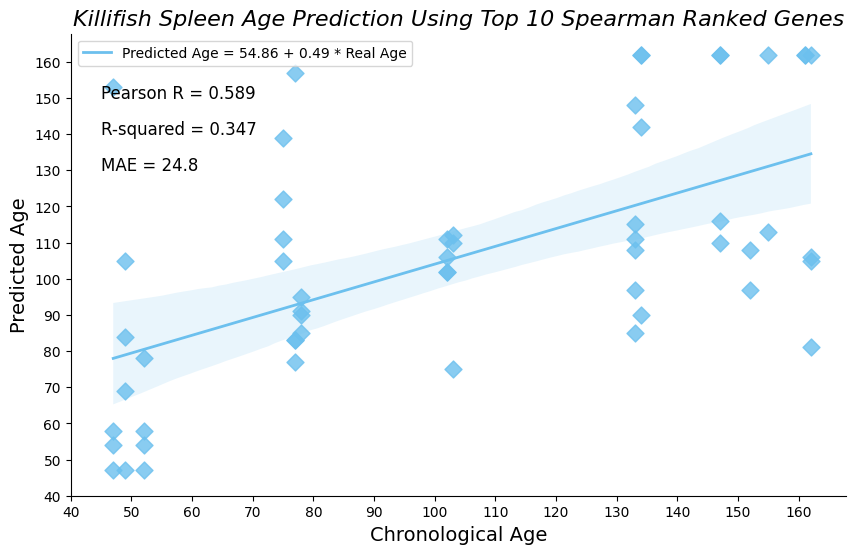

1
      prediction
A17_2       89.0
A18_2      109.0
A19_2      113.0
A20_2       50.0
B17_2      103.0
B18_2      122.0
B19_2       95.0
B20_2      162.0
C17_2      131.0
C18_2       56.0
C19_2      162.0
C20_2       57.0
D17_2       92.0
D18_2       85.0
D19_2      162.0
D20_2       47.0
E17_2       81.0
E18_2       47.0
E19_2       90.0
E20_2       47.0
F17_2      154.0
F18_2      107.0
F19_2       58.0
F20_2      162.0
G17_2      105.0
G18_2      157.0
G19_2      108.0
G20_2      110.0
H17_2      102.0
H18_2      110.0
H19_2      162.0
I17_2      105.0
I18_2      116.0
I19_2      105.0
J17_2       91.0
J18_2      110.0
J19_2       94.0
K17_2       67.0
K18_2      144.0
K19_2       53.0
L17_2      106.0
L18_2       51.0
L19_2       83.0
M17_2       75.0
M18_2      162.0
M19_2       57.0
N17_2      145.0
N18_2       47.0
N19_2       97.0
O17_2      160.0
O18_2       78.0
O19_2      154.0
P17_2      115.0
P18_2      132.0
P19_2       52.0
[35.17120372  0.64508872]
                    

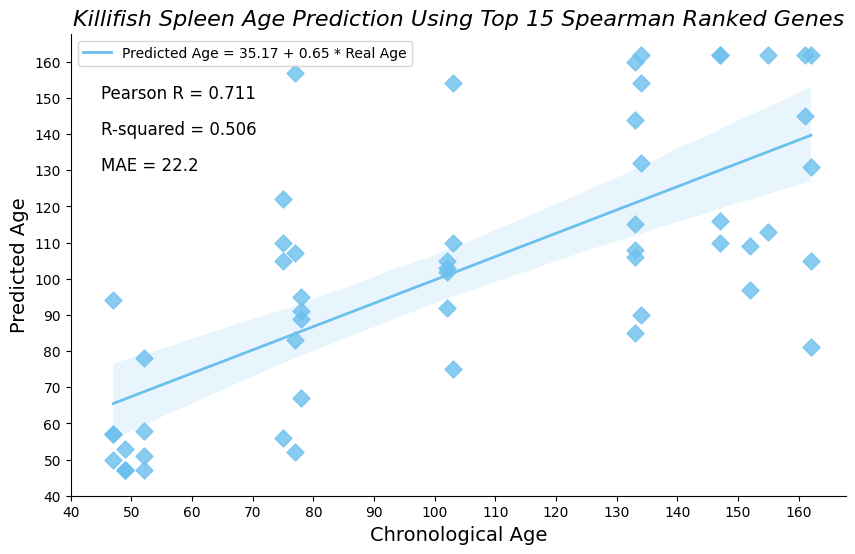

2
      prediction
A17_2       84.0
A18_2      110.0
A19_2      114.0
A20_2       51.0
B17_2      103.0
B18_2      122.0
B19_2       95.0
B20_2      162.0
C17_2      134.0
C18_2       52.0
C19_2      155.0
C20_2       51.0
D17_2       92.0
D18_2       85.0
D19_2      159.0
D20_2       47.0
E17_2       81.0
E18_2       47.0
E19_2       90.0
E20_2       47.0
F17_2      143.0
F18_2      111.0
F19_2       58.0
F20_2      162.0
G17_2      101.0
G18_2      157.0
G19_2      100.0
G20_2      162.0
H17_2      118.0
H18_2      110.0
H19_2      162.0
I17_2      105.0
I18_2      129.0
I19_2      105.0
J17_2       91.0
J18_2      153.0
J19_2       55.0
K17_2       67.0
K18_2      147.0
K19_2       53.0
L17_2      107.0
L18_2       53.0
L19_2       82.0
M17_2      109.0
M18_2      162.0
M19_2       57.0
N17_2      143.0
N18_2       70.0
N19_2      148.0
O17_2      162.0
O18_2       54.0
O19_2      145.0
P17_2       98.0
P18_2       49.0
P19_2       47.0
[30.69532211  0.69184957]
                    

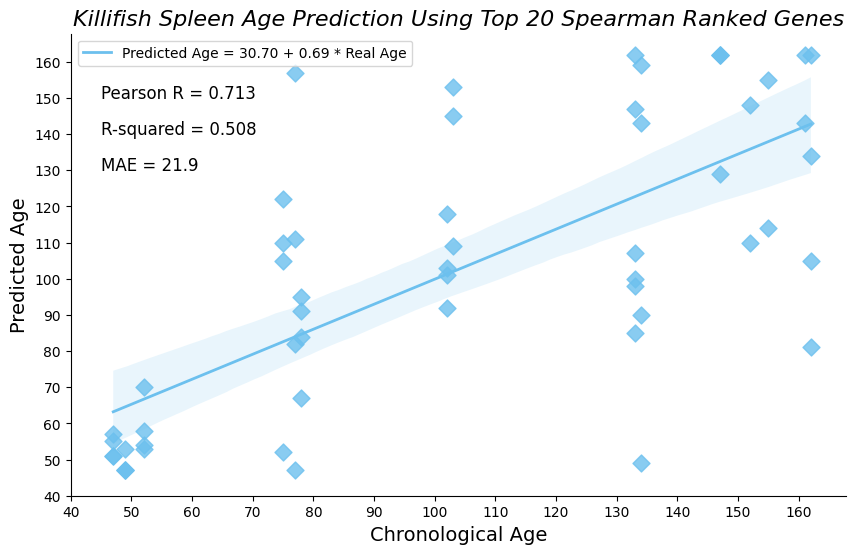

3
      prediction
A17_2       83.0
A18_2      111.0
A19_2      114.0
A20_2       52.0
B17_2      103.0
B18_2      122.0
B19_2       95.0
B20_2      162.0
C17_2      106.0
C18_2      139.0
C19_2      154.0
C20_2       50.0
D17_2      109.0
D18_2       85.0
D19_2      160.0
D20_2       47.0
E17_2       81.0
E18_2       47.0
E19_2       90.0
E20_2       47.0
F17_2      138.0
F18_2      117.0
F19_2       58.0
F20_2      162.0
G17_2      101.0
G18_2      113.0
G19_2      100.0
G20_2      162.0
H17_2      117.0
H18_2       70.0
H19_2      162.0
I17_2      105.0
I18_2      132.0
I19_2       68.0
J17_2       89.0
J18_2      153.0
J19_2       55.0
K17_2       67.0
K18_2      148.0
K19_2       53.0
L17_2      107.0
L18_2       52.0
L19_2       82.0
M17_2      109.0
M18_2      162.0
M19_2       57.0
N17_2      142.0
N18_2       70.0
N19_2      151.0
O17_2      162.0
O18_2       54.0
O19_2      152.0
P17_2       97.0
P18_2       49.0
P19_2       50.0
[30.98727971  0.68329549]
                    

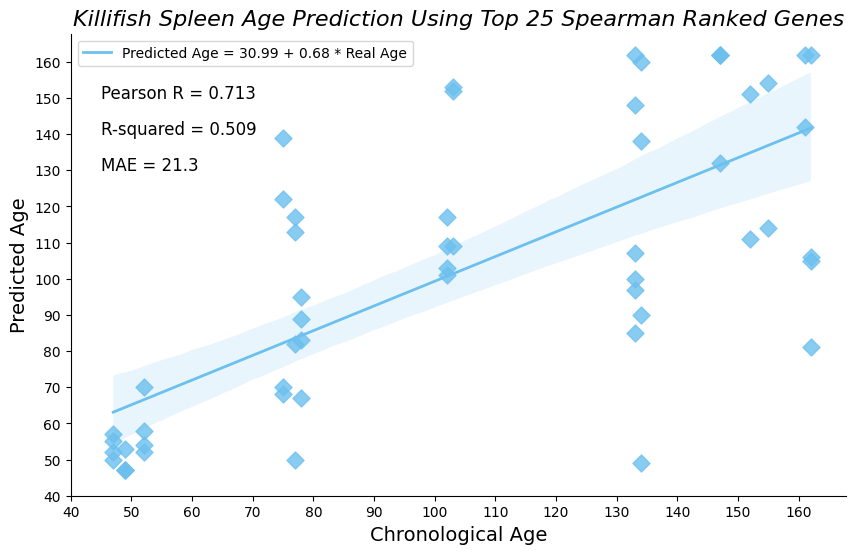

4
      prediction
A17_2       82.0
A18_2      111.0
A19_2      162.0
A20_2       52.0
B17_2      103.0
B18_2      122.0
B19_2       95.0
B20_2      162.0
C17_2      106.0
C18_2      139.0
C19_2      150.0
C20_2       49.0
D17_2       92.0
D18_2       85.0
D19_2      158.0
D20_2       47.0
E17_2       81.0
E18_2       47.0
E19_2       90.0
E20_2       47.0
F17_2      141.0
F18_2      139.0
F19_2       58.0
F20_2      162.0
G17_2      101.0
G18_2      157.0
G19_2      100.0
G20_2      162.0
H17_2      120.0
H18_2       70.0
H19_2      162.0
I17_2      105.0
I18_2      131.0
I19_2       67.0
J17_2       89.0
J18_2      153.0
J19_2       78.0
K17_2       67.0
K18_2      146.0
K19_2       53.0
L17_2      107.0
L18_2       53.0
L19_2       82.0
M17_2      109.0
M18_2      162.0
M19_2       69.0
N17_2      141.0
N18_2       70.0
N19_2      153.0
O17_2      162.0
O18_2       54.0
O19_2      155.0
P17_2       97.0
P18_2       49.0
P19_2       51.0
[35.16085004  0.66628653]
                    

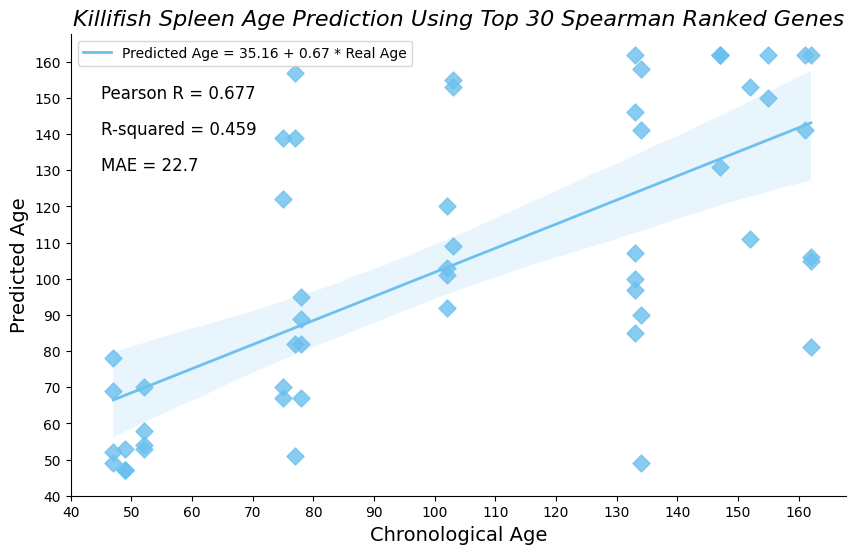

5
      prediction
A17_2       56.0
A18_2      111.0
A19_2      162.0
A20_2       52.0
B17_2      103.0
B18_2      122.0
B19_2       95.0
B20_2      162.0
C17_2      148.0
C18_2      139.0
C19_2      152.0
C20_2       48.0
D17_2      109.0
D18_2       85.0
D19_2      153.0
D20_2       47.0
E17_2       81.0
E18_2       47.0
E19_2       90.0
E20_2       47.0
F17_2      141.0
F18_2      138.0
F19_2       58.0
F20_2      162.0
G17_2      106.0
G18_2      157.0
G19_2       79.0
G20_2      162.0
H17_2      120.0
H18_2       70.0
H19_2      162.0
I17_2      152.0
I18_2      134.0
I19_2       66.0
J17_2       88.0
J18_2      153.0
J19_2       78.0
K17_2       67.0
K18_2      143.0
K19_2       53.0
L17_2      107.0
L18_2       52.0
L19_2       81.0
M17_2      109.0
M18_2      162.0
M19_2       69.0
N17_2      137.0
N18_2       61.0
N19_2      150.0
O17_2      162.0
O18_2       54.0
O19_2      155.0
P17_2       97.0
P18_2       75.0
P19_2       48.0
[29.00408103  0.7361422 ]
                    

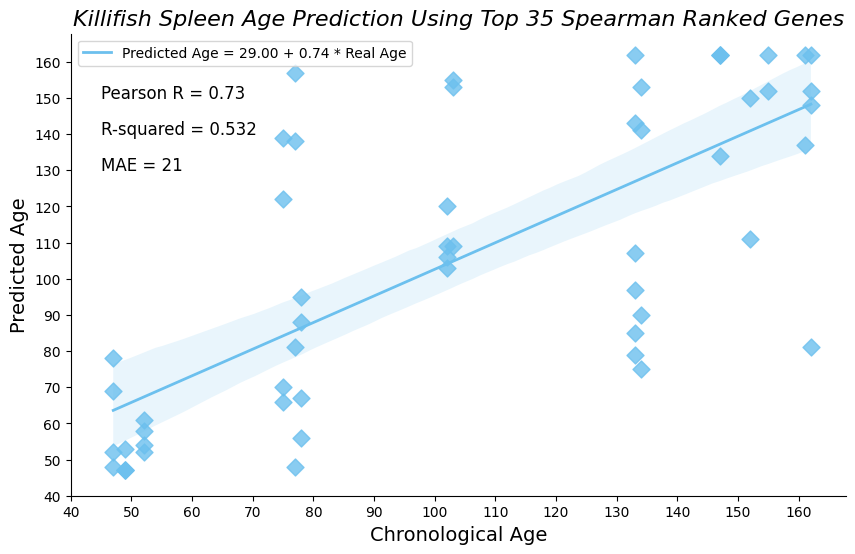

6
      prediction
A17_2       56.0
A18_2      111.0
A19_2      162.0
A20_2       52.0
B17_2      103.0
B18_2      122.0
B19_2       95.0
B20_2      162.0
C17_2      148.0
C18_2      139.0
C19_2      151.0
C20_2       48.0
D17_2      109.0
D18_2       85.0
D19_2      154.0
D20_2       47.0
E17_2       81.0
E18_2       47.0
E19_2       90.0
E20_2       47.0
F17_2      141.0
F18_2      136.0
F19_2       58.0
F20_2      162.0
G17_2      104.0
G18_2      157.0
G19_2       79.0
G20_2      162.0
H17_2      117.0
H18_2       70.0
H19_2      162.0
I17_2      153.0
I18_2      134.0
I19_2       65.0
J17_2       88.0
J18_2      153.0
J19_2       57.0
K17_2       67.0
K18_2      144.0
K19_2       53.0
L17_2      107.0
L18_2       51.0
L19_2       81.0
M17_2      109.0
M18_2      162.0
M19_2       69.0
N17_2      108.0
N18_2       61.0
N19_2      151.0
O17_2      162.0
O18_2       54.0
O19_2      158.0
P17_2       97.0
P18_2       69.0
P19_2       47.0
[28.30011184  0.73243136]
                    

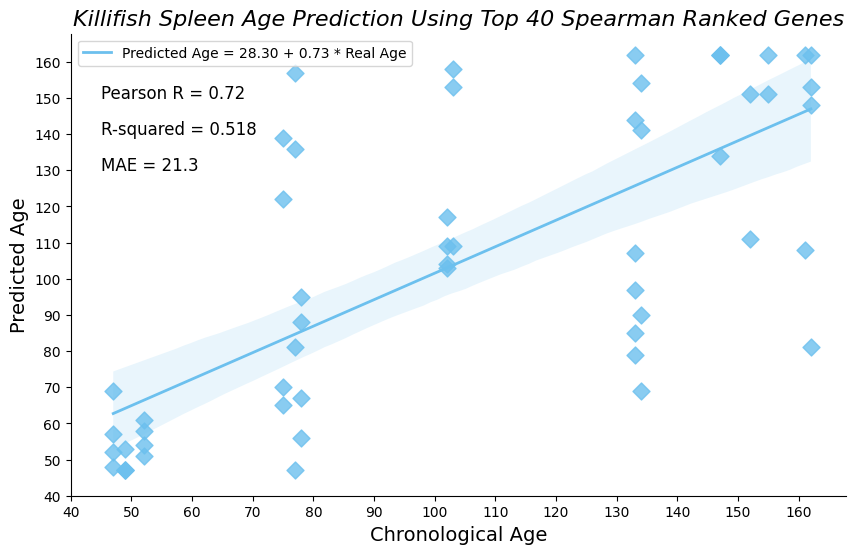

7
      prediction
A17_2       56.0
A18_2      111.0
A19_2      162.0
A20_2       52.0
B17_2      103.0
B18_2      122.0
B19_2       95.0
B20_2      162.0
C17_2      149.0
C18_2      151.0
C19_2      150.0
C20_2       47.0
D17_2      109.0
D18_2       85.0
D19_2      154.0
D20_2       47.0
E17_2      109.0
E18_2       47.0
E19_2       90.0
E20_2       47.0
F17_2      138.0
F18_2      136.0
F19_2       58.0
F20_2      162.0
G17_2      101.0
G18_2      114.0
G19_2       79.0
G20_2      162.0
H17_2      102.0
H18_2       69.0
H19_2      159.0
I17_2      154.0
I18_2      137.0
I19_2       65.0
J17_2       88.0
J18_2      153.0
J19_2       57.0
K17_2       67.0
K18_2      145.0
K19_2       53.0
L17_2      107.0
L18_2       52.0
L19_2       81.0
M17_2      109.0
M18_2      162.0
M19_2       69.0
N17_2      108.0
N18_2       61.0
N19_2      150.0
O17_2      162.0
O18_2       55.0
O19_2      113.0
P17_2       97.0
P18_2       68.0
P19_2       47.0
[24.23541928  0.75938133]
                    

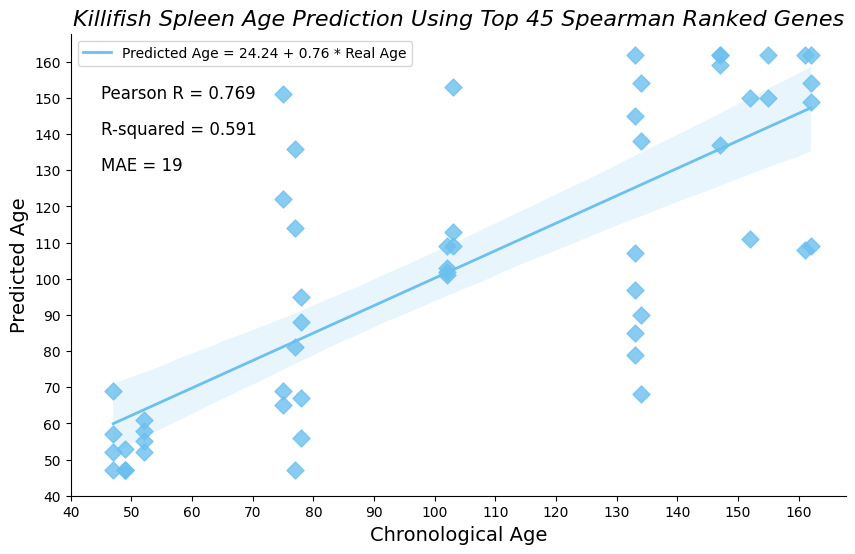

8
      prediction
A17_2       56.0
A18_2      111.0
A19_2      162.0
A20_2       53.0
B17_2      103.0
B18_2      122.0
B19_2       95.0
B20_2      162.0
C17_2      150.0
C18_2      151.0
C19_2      151.0
C20_2       47.0
D17_2      109.0
D18_2       85.0
D19_2      155.0
D20_2       47.0
E17_2      109.0
E18_2       47.0
E19_2       90.0
E20_2       47.0
F17_2      135.0
F18_2      139.0
F19_2       58.0
F20_2      162.0
G17_2      101.0
G18_2      114.0
G19_2       79.0
G20_2      159.0
H17_2      102.0
H18_2       69.0
H19_2      159.0
I17_2      158.0
I18_2      137.0
I19_2       63.0
J17_2       87.0
J18_2      153.0
J19_2       57.0
K17_2       67.0
K18_2      147.0
K19_2       53.0
L17_2      107.0
L18_2       52.0
L19_2       81.0
M17_2      109.0
M18_2      162.0
M19_2       69.0
N17_2      108.0
N18_2       61.0
N19_2      147.0
O17_2      162.0
O18_2       55.0
O19_2      113.0
P17_2       97.0
P18_2       70.0
P19_2       47.0
[24.20814622  0.76016599]
                    

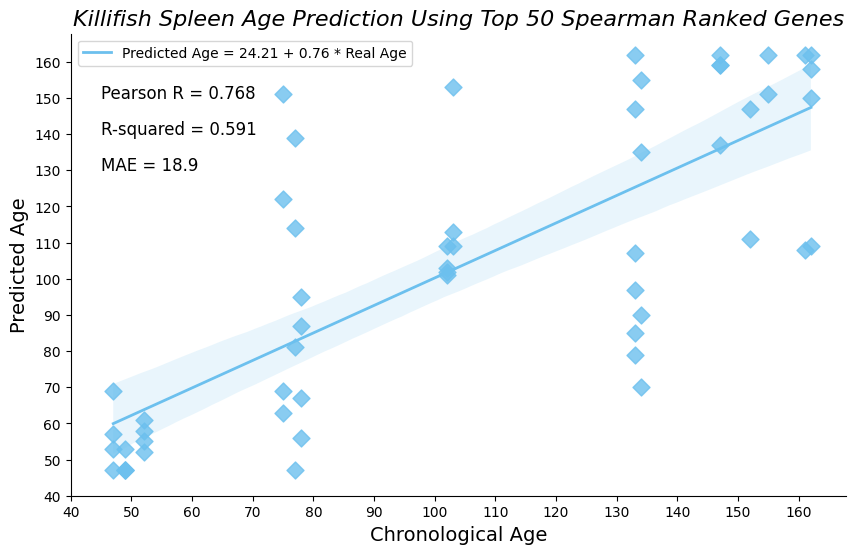

9


In [ ]:
gene_number_test = [10, 15, 20, 25, 30, 35, 40, 45, 50]

counter = 0

for number in gene_number_test:

    gene_number = number

    # Initialize DataFrame for predictions
    spleen_predicted_ages = pd.DataFrame(index=spleen_df_age.index, columns=["prediction"])

    # Iterate through each sample in the DataFrame
    for sample in spleen_df_age.index.tolist():

        # Read the spearman and frequency data for the current sample
        #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
        df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/spleen/reference/spleen_reference_{sample}", sep="\t")
        df_frequency.set_index("Gene", inplace=True)

        # Get top genes based on spearman correlation
        top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
        top_genes = top_absolute_spearman_correlation.index.tolist()
        #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

        total_reads_sample = df_unnorm.loc[sample].sum()

        list_of_profile_probabilities_per_age = []

        # Iterate through each age step
        for age in new_spleen_age_steps:

            probability_list_one_age = []
            genes_not_defined = []

            # Iterate through each gene for the sample
            for gene in top_genes:

                gene_frequency = df_frequency.loc[gene, f"{age}"]

                # Replace negative gene frequency with 10^-10
                if gene_frequency < 0:
                    gene_frequency = 10**-10

                sample_expected_counts = gene_frequency * total_reads_sample
                sample_observed_counts = df_unnorm.loc[sample, gene]

                poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

                # Replace NaN poisson probability with a small positive value and log it
                if np.isnan(poisson_probability):
                    poisson_probability = 0.001
                    genes_not_defined.append(gene)

                # Replace zero poisson probability with 0.001
                if poisson_probability == 0:
                    poisson_probability = 0.001

                logP = np.log(poisson_probability)

                probability_list_one_age.append(logP)

            list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

        # transform into dataframe with age steps
        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_spleen_age_steps)

        # Compute highest likelihood age among age steps
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

        # Compute highest maximum probability
        max_probability = float(age_probability_df["Pr"].max())

        spleen_predicted_ages.loc[sample, "prediction"] = max_probability_age

    # Print the resulting DataFrame
    print(spleen_predicted_ages)

    spleen_predicted_ages["true_age"] = spleen_df_age["age"].tolist()

    spleen_df_model = sm.OLS(spleen_predicted_ages["prediction"].tolist(), sm.add_constant(spleen_predicted_ages["true_age"].tolist()))

    spleen_df_results = spleen_df_model.fit()

    print(spleen_df_results.params)
    print(spleen_df_results.summary())

    b, m = spleen_df_results.params

    MAE = mae(spleen_predicted_ages["true_age"].tolist(), spleen_predicted_ages["prediction"].tolist())

    print(MAE)

    spleen_correlation_coefficient, spleen_p_value = pearsonr(spleen_predicted_ages["true_age"].tolist(), spleen_predicted_ages["prediction"].tolist())

    spleen_correlation_coefficient

    # Ensure the 'age' and 'prediction' columns are numeric
    spleen_predicted_ages['age'] = pd.to_numeric(spleen_predicted_ages['true_age'], errors='coerce')
    spleen_predicted_ages['prediction'] = pd.to_numeric(spleen_predicted_ages['prediction'], errors='coerce')

    # Drop rows with NaN values in 'age' or 'prediction' columns
    spleen_df_female_predictions = spleen_predicted_ages.dropna(subset=['age', 'prediction'])

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(spleen_predicted_ages['age'], spleen_predicted_ages['prediction'])

    # Calculate Pearson R, R-squared, and MAE
    spleen_correlation_coefficient = r_value
    cod = r_value ** 2
    MAE = mae(spleen_predicted_ages['age'], spleen_predicted_ages['prediction'])

    # Formatting variables to three significant figures
    spleen_correlation_coefficient = f"{spleen_correlation_coefficient:.3g}"
    cod = f"{cod:.3g}"
    MAE = f"{MAE:.3g}"


    print(f"Performance for Gene Number: {gene_number}")
    print(f"Pearson Correlation: {spleen_correlation_coefficient}")
    print(f"Coefficient of Determination: {cod}")
    print(f"Mean Absolute Error: {MAE}")

    counter += 1
    # Plotting the scatter plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.regplot(x="age",
            y="prediction",
            data=spleen_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
    sns.despine(right=True)

    x_tick = np.arange(40, 170, 10)
    y_tick = np.arange(40, 170, 10)

    plt.xticks(x_tick)
    plt.yticks(y_tick)

    # Perason Correlation
    plt.text(45, 150, f"Pearson R = {spleen_correlation_coefficient}", fontsize=12, color="black")

    #R-squared
    plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

    # Adding MAE text
    plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

    # Changing the names and sizes of x and y-axis labels
    plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
    plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

    # Changing the size of the title
    plt.title(f'Killifish Spleen Age Prediction Using Top {gene_number} Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

    # Display the legend
    plt.legend()

    # Save the plot as a publication-ready image (e.g., PNG)
    #plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

    plt.show()

    print(counter)

# Spinal Cord

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./outputs/all_bayesage_clocks/spinalcord/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
spinal_df_counts = combined_df.loc[combined_df.iloc[:,-2] == "SpinalCord"]

spinal_df_counts.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A10_2,6,720,1913,484,462,710,1745,747,1132,785,...,278,2082,44,2019,1827,251,380,M,SpinalCord,75
A11_2,18,1072,2252,790,413,1312,2765,1234,1979,1236,...,245,2435,115,2830,2170,477,555,F,SpinalCord,52
A12_2,9,611,1614,536,378,729,2021,1179,1119,760,...,210,1870,42,2445,1624,211,327,M,SpinalCord,161
A9_2,22,894,2610,848,637,915,3089,1368,1554,1058,...,431,2987,74,2925,2466,306,641,M,SpinalCord,162
B10_2,14,461,1361,372,239,581,1304,983,974,522,...,212,1312,50,1348,1090,180,240,M,SpinalCord,103


In [ ]:
spinal_age_days_value_counts = spinal_df_counts["age_days"].value_counts().index.tolist()

In [ ]:
spinal_age_steps = sorted(spinal_age_days_value_counts)

print(spinal_age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 155, 161, 162]


In [ ]:
spinal_gene_expression_data = spinal_df_counts.iloc[:, :-3]

In [ ]:
spinal_df_age = spinal_gene_expression_data.copy()

In [ ]:
spinal_df_age["age"] = spinal_df_counts["age_days"].tolist()

spinal_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A10_2,6,720,1913,484,462,710,1745,747,1132,785,...,209,1277,278,2082,44,2019,1827,251,380,75
A11_2,18,1072,2252,790,413,1312,2765,1234,1979,1236,...,372,1489,245,2435,115,2830,2170,477,555,52
A12_2,9,611,1614,536,378,729,2021,1179,1119,760,...,266,952,210,1870,42,2445,1624,211,327,161


In [ ]:
#for sample in spinal_df_age.index.tolist():

#    new_df = spinal_df_age.drop(sample)

#    new_df.to_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/spinalcord/sample/spinal_sample_{sample}.csv", sep="\t")

#    print(new_df.shape)

(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)
(53, 25123)


In [ ]:
new_spinal_age_steps = np.arange(min(spinal_age_steps), max(spinal_age_steps) + 1, 1)

In [ ]:
#counter = 0

#for sample in spinal_df_age.index.tolist():

#    transcriptome_reference(training_matrix=f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/spinalcord/sample/spinal_sample_{sample}.csv",
#                            reference_name=f"spinal_reference_{sample}",
#                            output_path="/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/spinalcord/reference/",
#                            age_prediction="list",
#                            age_list=new_spinal_age_steps,
#                            min_age=1,
#                            max_age=24,
#                            age_step=1,
#                            tau=0.7)

#    counter += 1

#    print(counter)

#### Spinal Cord Age Prediction

      prediction
A10_2       85.0
A11_2       47.0
A12_2      162.0
A9_2       158.0
B10_2      113.0
B11_2       55.0
B12_2      126.0
B9_2       140.0
C10_2      127.0
C11_2       87.0
C12_2      162.0
C9_2        67.0
D10_2      135.0
D11_2       84.0
D12_2       62.0
D9_2        47.0
E10_2      146.0
E11_2      162.0
E12_2       69.0
E9_2        89.0
F10_2      131.0
F11_2      133.0
F12_2       84.0
F9_2       103.0
G10_2       56.0
G11_2      160.0
G9_2       162.0
H10_2      162.0
H11_2      120.0
H9_2        98.0
I10_2       64.0
I11_2      144.0
I9_2        52.0
J10_2       47.0
J11_2      104.0
J9_2       122.0
K10_2      162.0
K11_2      113.0
K9_2       124.0
L10_2      139.0
L11_2       50.0
L9_2        75.0
M10_2       96.0
M11_2       73.0
M9_2       106.0
N10_2       98.0
N11_2      103.0
N9_2        57.0
O10_2      122.0
O11_2       77.0
O9_2       105.0
P10_2       93.0
P11_2       73.0
P9_2        50.0
[22.14856694  0.77091726]
                            OLS Regress

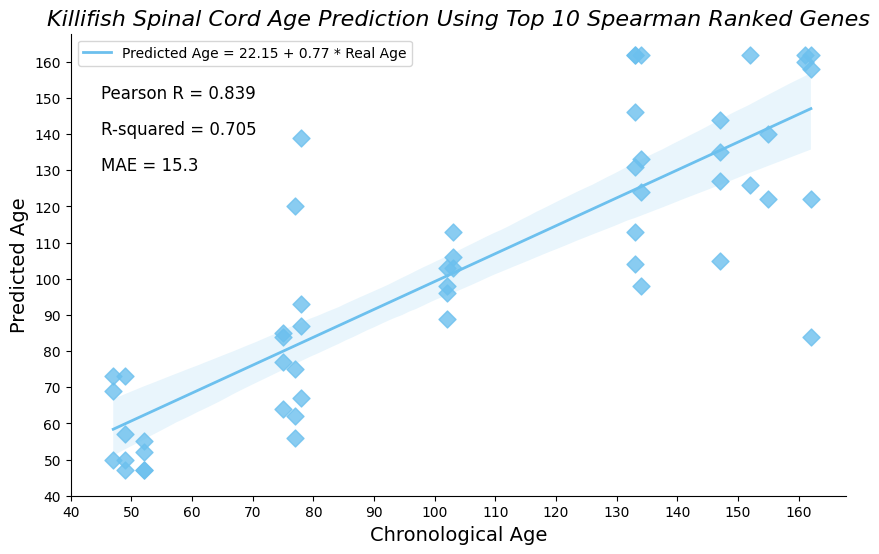

1
      prediction
A10_2       85.0
A11_2       47.0
A12_2      162.0
A9_2       162.0
B10_2      117.0
B11_2       56.0
B12_2      118.0
B9_2       134.0
C10_2      129.0
C11_2       80.0
C12_2      162.0
C9_2        81.0
D10_2      132.0
D11_2       86.0
D12_2       57.0
D9_2        47.0
E10_2      162.0
E11_2      148.0
E12_2       75.0
E9_2       116.0
F10_2      139.0
F11_2      136.0
F12_2       85.0
F9_2       106.0
G10_2       56.0
G11_2      144.0
G9_2       162.0
H10_2      162.0
H11_2      118.0
H9_2       102.0
I10_2       68.0
I11_2      144.0
I9_2        64.0
J10_2       47.0
J11_2      110.0
J9_2       134.0
K10_2      162.0
K11_2      114.0
K9_2       113.0
L10_2      148.0
L11_2       50.0
L9_2        70.0
M10_2       88.0
M11_2       53.0
M9_2       156.0
N10_2       98.0
N11_2      107.0
N9_2        47.0
O10_2      124.0
O11_2       77.0
O9_2       105.0
P10_2       92.0
P11_2       47.0
P9_2        49.0
[21.76777927  0.78367439]
                            OLS Regre

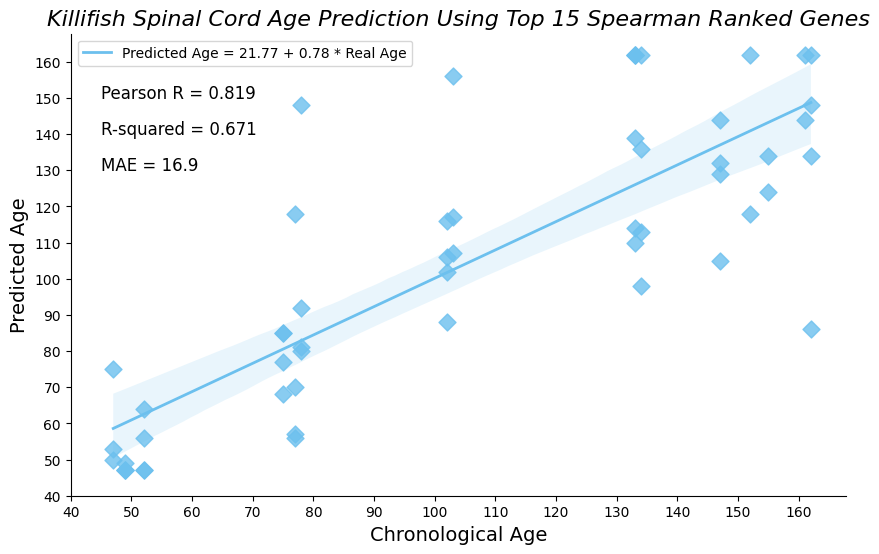

2
      prediction
A10_2       86.0
A11_2       47.0
A12_2      154.0
A9_2       162.0
B10_2      118.0
B11_2       52.0
B12_2      118.0
B9_2       132.0
C10_2      133.0
C11_2       80.0
C12_2      162.0
C9_2        82.0
D10_2      140.0
D11_2       75.0
D12_2       56.0
D9_2        48.0
E10_2      162.0
E11_2      148.0
E12_2       75.0
E9_2       116.0
F10_2      143.0
F11_2      141.0
F12_2       85.0
F9_2       113.0
G10_2      111.0
G11_2      144.0
G9_2       162.0
H10_2      157.0
H11_2      118.0
H9_2       105.0
I10_2       71.0
I11_2      153.0
I9_2        64.0
J10_2       47.0
J11_2      117.0
J9_2       133.0
K10_2      162.0
K11_2      115.0
K9_2       111.0
L10_2      131.0
L11_2       49.0
L9_2        71.0
M10_2       93.0
M11_2       54.0
M9_2       162.0
N10_2      161.0
N11_2      107.0
N9_2        47.0
O10_2      125.0
O11_2       78.0
O9_2       105.0
P10_2       99.0
P11_2       57.0
P9_2        51.0
[25.06691218  0.77960386]
                            OLS Regre

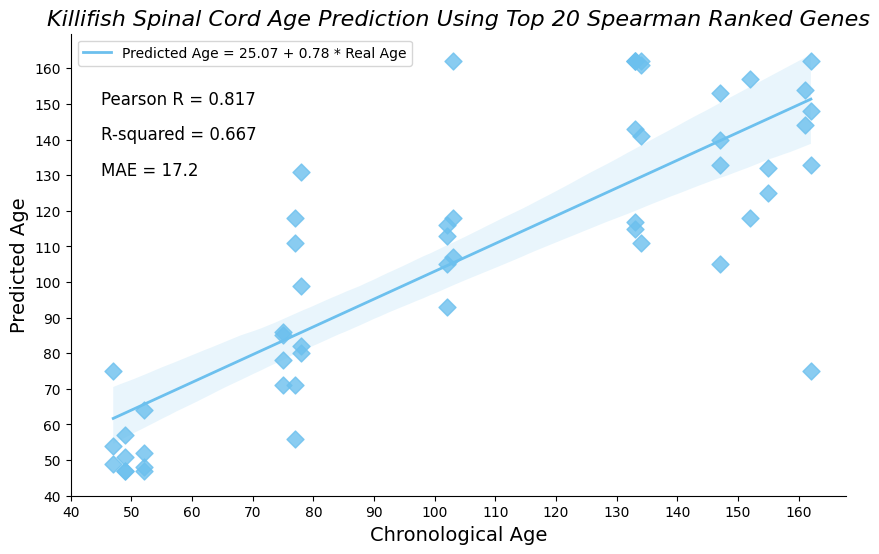

3
      prediction
A10_2       85.0
A11_2       47.0
A12_2      153.0
A9_2       162.0
B10_2      109.0
B11_2       52.0
B12_2      118.0
B9_2       133.0
C10_2      137.0
C11_2       78.0
C12_2      162.0
C9_2        82.0
D10_2      140.0
D11_2       88.0
D12_2       57.0
D9_2        50.0
E10_2      162.0
E11_2      148.0
E12_2       74.0
E9_2       115.0
F10_2      153.0
F11_2      142.0
F12_2       84.0
F9_2       113.0
G10_2      111.0
G11_2      137.0
G9_2       162.0
H10_2      157.0
H11_2       90.0
H9_2       107.0
I10_2       71.0
I11_2      155.0
I9_2        64.0
J10_2       47.0
J11_2      117.0
J9_2       130.0
K10_2      117.0
K11_2      114.0
K9_2       111.0
L10_2      131.0
L11_2       48.0
L9_2        71.0
M10_2       92.0
M11_2       54.0
M9_2       162.0
N10_2      161.0
N11_2      107.0
N9_2        47.0
O10_2      127.0
O11_2       79.0
O9_2       105.0
P10_2       99.0
P11_2       57.0
P9_2        52.0
[23.4634801   0.78392617]
                            OLS Regre

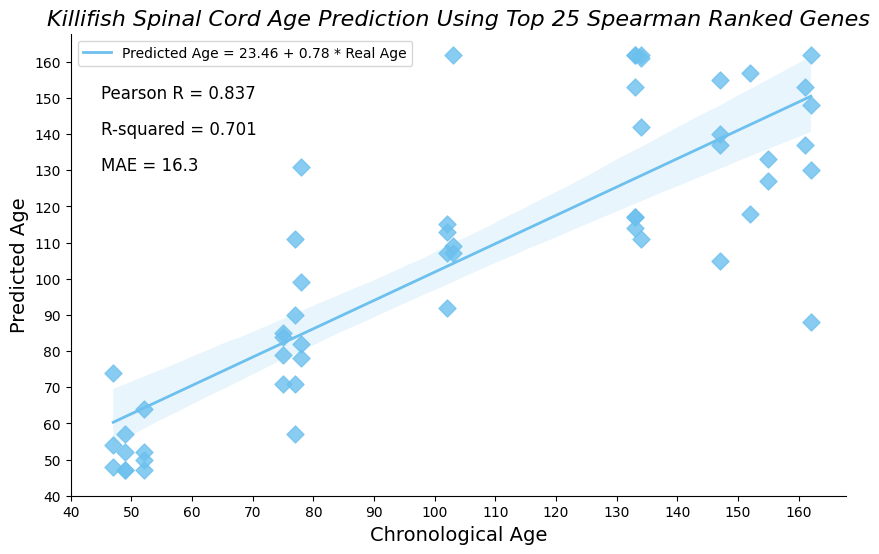

4
      prediction
A10_2       80.0
A11_2       47.0
A12_2      156.0
A9_2       162.0
B10_2      110.0
B11_2       52.0
B12_2      116.0
B9_2       117.0
C10_2      136.0
C11_2       79.0
C12_2      161.0
C9_2        83.0
D10_2      135.0
D11_2       88.0
D12_2       56.0
D9_2        53.0
E10_2      162.0
E11_2      148.0
E12_2       74.0
E9_2       115.0
F10_2      153.0
F11_2      144.0
F12_2       83.0
F9_2       116.0
G10_2      111.0
G11_2      139.0
G9_2       162.0
H10_2      157.0
H11_2       90.0
H9_2       102.0
I10_2       71.0
I11_2      152.0
I9_2        47.0
J10_2       47.0
J11_2      117.0
J9_2       129.0
K10_2      117.0
K11_2      114.0
K9_2       111.0
L10_2      131.0
L11_2       47.0
L9_2        70.0
M10_2       91.0
M11_2       54.0
M9_2       162.0
N10_2      159.0
N11_2      107.0
N9_2        47.0
O10_2      130.0
O11_2       79.0
O9_2       162.0
P10_2       81.0
P11_2       55.0
P9_2        50.0
[19.47652716  0.82019471]
                            OLS Regre

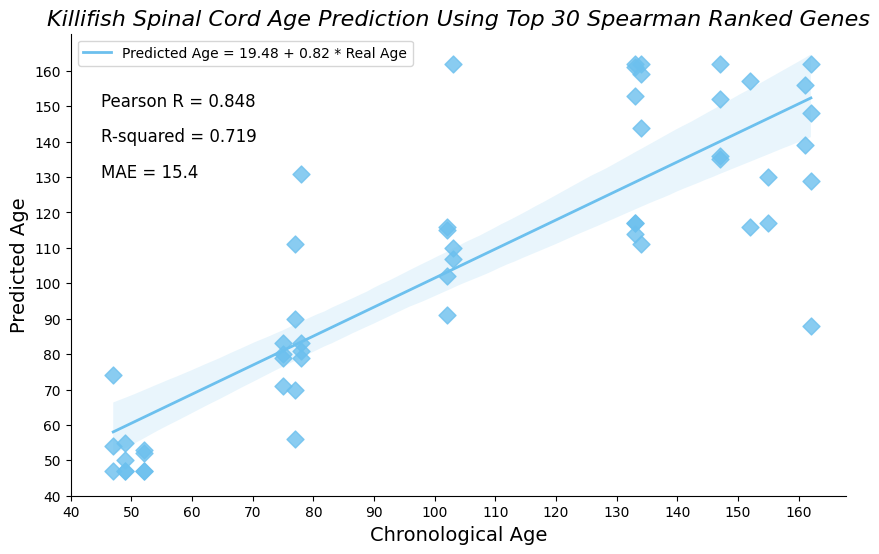

5
      prediction
A10_2       80.0
A11_2       47.0
A12_2      156.0
A9_2       162.0
B10_2       96.0
B11_2       54.0
B12_2      116.0
B9_2       119.0
C10_2      141.0
C11_2       79.0
C12_2      162.0
C9_2        83.0
D10_2      132.0
D11_2       88.0
D12_2       57.0
D9_2        52.0
E10_2      162.0
E11_2      148.0
E12_2       70.0
E9_2       115.0
F10_2      141.0
F11_2      146.0
F12_2       83.0
F9_2        86.0
G10_2      112.0
G11_2      139.0
G9_2       162.0
H10_2      157.0
H11_2       90.0
H9_2       102.0
I10_2       70.0
I11_2      159.0
I9_2        64.0
J10_2       48.0
J11_2      117.0
J9_2       130.0
K10_2      117.0
K11_2      114.0
K9_2       137.0
L10_2      108.0
L11_2       47.0
L9_2        70.0
M10_2       92.0
M11_2       56.0
M9_2       161.0
N10_2      161.0
N11_2      107.0
N9_2        47.0
O10_2      129.0
O11_2       79.0
O9_2       153.0
P10_2       79.0
P11_2       53.0
P9_2        50.0
[18.08387251  0.82779024]
                            OLS Regre

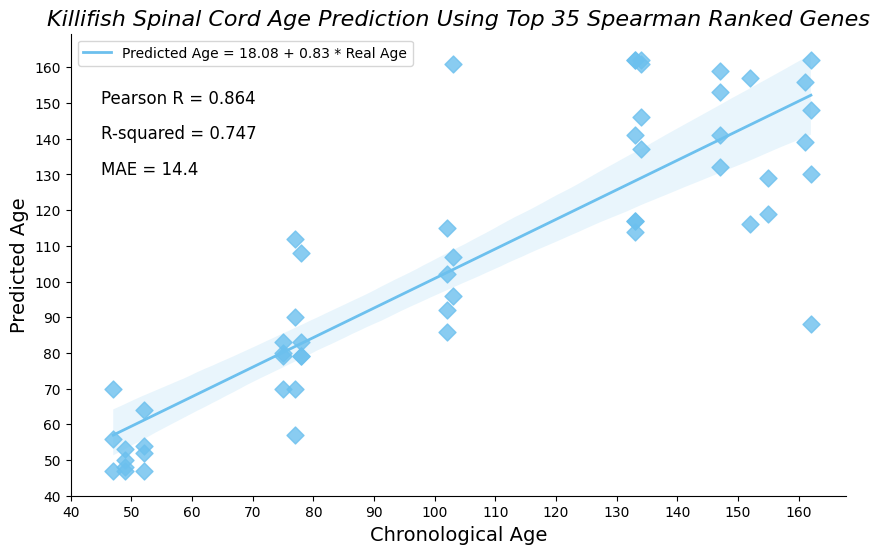

6
      prediction
A10_2       80.0
A11_2       47.0
A12_2      159.0
A9_2       162.0
B10_2       96.0
B11_2       55.0
B12_2      118.0
B9_2       119.0
C10_2      140.0
C11_2       78.0
C12_2      162.0
C9_2        83.0
D10_2      137.0
D11_2       88.0
D12_2       59.0
D9_2        48.0
E10_2      162.0
E11_2      148.0
E12_2       70.0
E9_2       115.0
F10_2      139.0
F11_2      145.0
F12_2       83.0
F9_2        79.0
G10_2      110.0
G11_2      139.0
G9_2       162.0
H10_2      157.0
H11_2       90.0
H9_2        98.0
I10_2       66.0
I11_2      160.0
I9_2        64.0
J10_2       48.0
J11_2      116.0
J9_2       131.0
K10_2      117.0
K11_2      115.0
K9_2       137.0
L10_2      108.0
L11_2       47.0
L9_2        73.0
M10_2       92.0
M11_2       56.0
M9_2       161.0
N10_2      161.0
N11_2      107.0
N9_2        47.0
O10_2      122.0
O11_2       79.0
O9_2       155.0
P10_2       79.0
P11_2       48.0
P9_2        50.0
[16.8837718   0.83601904]
                            OLS Regre

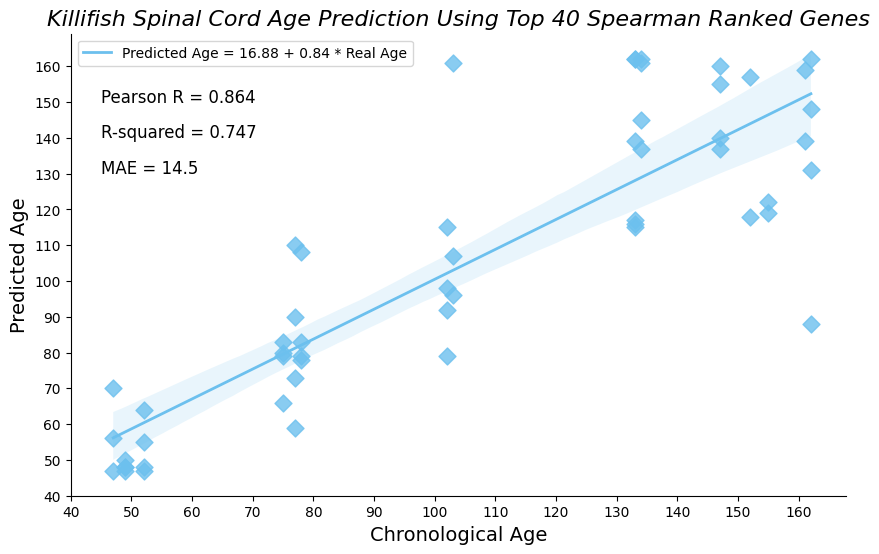

7
      prediction
A10_2       80.0
A11_2       47.0
A12_2      153.0
A9_2       162.0
B10_2       96.0
B11_2       51.0
B12_2      118.0
B9_2       123.0
C10_2      141.0
C11_2       78.0
C12_2      154.0
C9_2        85.0
D10_2      136.0
D11_2       88.0
D12_2       59.0
D9_2        48.0
E10_2      109.0
E11_2      148.0
E12_2       70.0
E9_2       115.0
F10_2      127.0
F11_2      143.0
F12_2       80.0
F9_2        79.0
G10_2      112.0
G11_2      139.0
G9_2       162.0
H10_2      157.0
H11_2       90.0
H9_2        98.0
I10_2       66.0
I11_2      160.0
I9_2        64.0
J10_2       48.0
J11_2      111.0
J9_2       135.0
K10_2      117.0
K11_2      115.0
K9_2       138.0
L10_2      106.0
L11_2       47.0
L9_2        73.0
M10_2       92.0
M11_2       55.0
M9_2       160.0
N10_2      161.0
N11_2      107.0
N9_2        47.0
O10_2      124.0
O11_2       76.0
O9_2       152.0
P10_2       79.0
P11_2       47.0
P9_2        53.0
[17.5025009   0.81502548]
                            OLS Regre

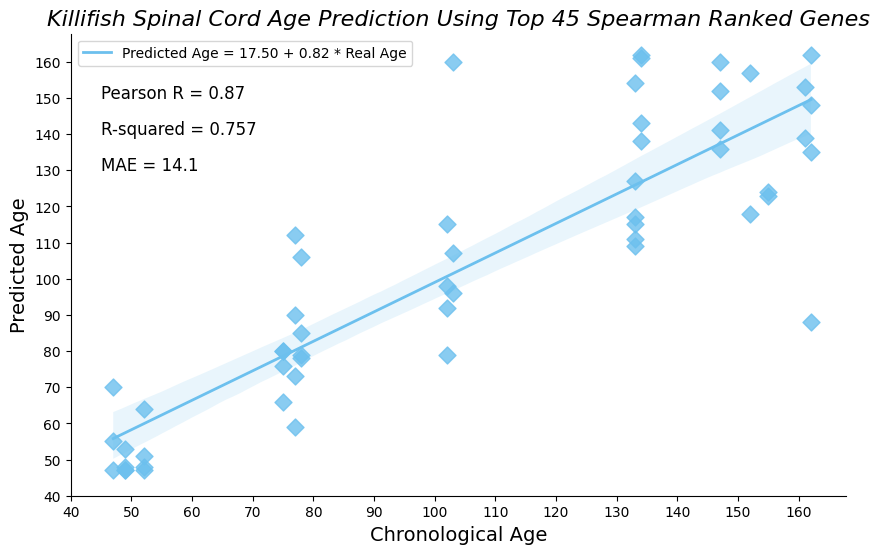

8
      prediction
A10_2       80.0
A11_2       47.0
A12_2      153.0
A9_2       162.0
B10_2       96.0
B11_2       51.0
B12_2      118.0
B9_2       124.0
C10_2      150.0
C11_2       80.0
C12_2      154.0
C9_2        86.0
D10_2      134.0
D11_2       88.0
D12_2       59.0
D9_2        51.0
E10_2      109.0
E11_2      148.0
E12_2       64.0
E9_2       115.0
F10_2      127.0
F11_2      145.0
F12_2       80.0
F9_2        79.0
G10_2      150.0
G11_2      142.0
G9_2       162.0
H10_2      157.0
H11_2       90.0
H9_2        93.0
I10_2       65.0
I11_2      161.0
I9_2        64.0
J10_2       48.0
J11_2      111.0
J9_2       138.0
K10_2      117.0
K11_2      115.0
K9_2       137.0
L10_2      106.0
L11_2       47.0
L9_2        73.0
M10_2      107.0
M11_2       55.0
M9_2       160.0
N10_2      158.0
N11_2      107.0
N9_2        47.0
O10_2      124.0
O11_2       76.0
O9_2       146.0
P10_2       75.0
P11_2       53.0
P9_2        52.0
[19.40265485  0.80665553]
                            OLS Regre

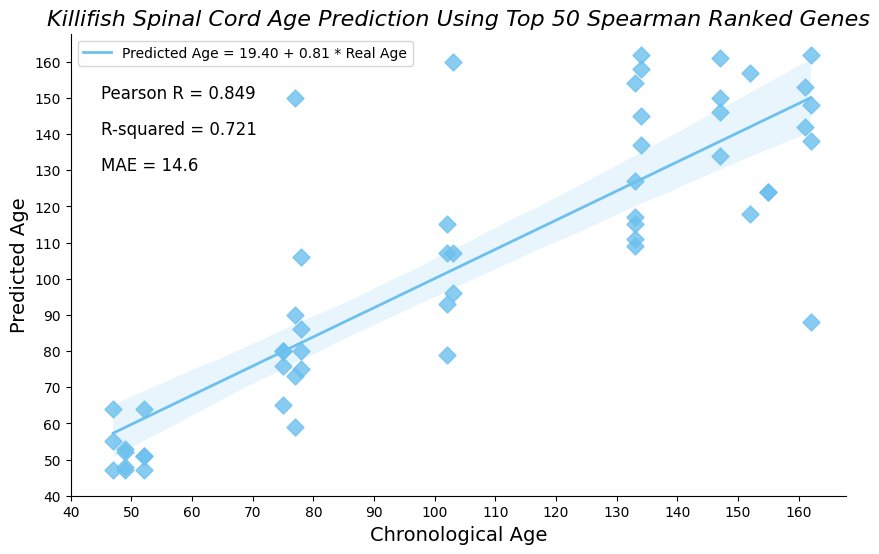

9


In [ ]:
gene_number_test = [10, 15, 20, 25, 30, 35, 40, 45, 50]

counter = 0

for number in gene_number_test:

    gene_number = number

    # Initialize DataFrame for predictions
    spinal_predicted_ages = pd.DataFrame(index=spinal_df_age.index, columns=["prediction"])

    # Iterate through each sample in the DataFrame
    for sample in spinal_df_age.index.tolist():

        # Read the spearman and frequency data for the current sample
        #df_spearman = pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/killifish/kidney/subsample/reference/liver_spearman_female_{sample}")
        df_frequency= pd.read_csv(f"/home/lajoyce/Documents/killifish_vs_mouse/analysis/killifish/spinalcord/reference/spinal_reference_{sample}", sep="\t")
        df_frequency.set_index("Gene", inplace=True)

        # Get top genes based on spearman correlation
        top_absolute_spearman_correlation = df_frequency["spearman_rank"].abs().nlargest(gene_number)
        top_genes = top_absolute_spearman_correlation.index.tolist()
        #genes_for_sample = df_frequency.loc[top_genes, "Gene"].tolist()

        total_reads_sample = df_unnorm.loc[sample].sum()

        list_of_profile_probabilities_per_age = []

        # Iterate through each age step
        for age in new_spinal_age_steps:

            probability_list_one_age = []
            genes_not_defined = []

            # Iterate through each gene for the sample
            for gene in top_genes:

                gene_frequency = df_frequency.loc[gene, f"{age}"]

                # Replace negative gene frequency with 10^-10
                if gene_frequency < 0:
                    gene_frequency = 10**-10

                sample_expected_counts = gene_frequency * total_reads_sample
                sample_observed_counts = df_unnorm.loc[sample, gene]

                poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

                # Replace NaN poisson probability with a small positive value and log it
                if np.isnan(poisson_probability):
                    poisson_probability = 0.001
                    genes_not_defined.append(gene)

                # Replace zero poisson probability with 0.001
                if poisson_probability == 0:
                    poisson_probability = 0.001

                logP = np.log(poisson_probability)

                probability_list_one_age.append(logP)

            list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

        # transform into dataframe with age steps
        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_spinal_age_steps)

        # Compute highest likelihood age among age steps
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

        # Compute highest maximum probability
        max_probability = float(age_probability_df["Pr"].max())

        spinal_predicted_ages.loc[sample, "prediction"] = max_probability_age

    # Print the resulting DataFrame
    print(spinal_predicted_ages)

    spinal_predicted_ages["true_age"] = spinal_df_age["age"].tolist()

    spinal_df_model = sm.OLS(spinal_predicted_ages["prediction"].tolist(), sm.add_constant(spinal_predicted_ages["true_age"].tolist()))

    spinal_df_results = spinal_df_model.fit()

    print(spinal_df_results.params)
    print(spinal_df_results.summary())

    b, m = spinal_df_results.params

    MAE = mae(spinal_predicted_ages["true_age"].tolist(), spinal_predicted_ages["prediction"].tolist())

    print(MAE)

    spinal_correlation_coefficient, spinal_p_value = pearsonr(spinal_predicted_ages["true_age"].tolist(), spinal_predicted_ages["prediction"].tolist())

    spinal_correlation_coefficient

    # Ensure the 'age' and 'prediction' columns are numeric
    spinal_predicted_ages['age'] = pd.to_numeric(spinal_predicted_ages['true_age'], errors='coerce')
    spinal_predicted_ages['prediction'] = pd.to_numeric(spinal_predicted_ages['prediction'], errors='coerce')

    # Drop rows with NaN values in 'age' or 'prediction' columns
    spinal_df_female_predictions = spinal_predicted_ages.dropna(subset=['age', 'prediction'])

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(spinal_predicted_ages['age'], spinal_predicted_ages['prediction'])

    # Calculate Pearson R, R-squared, and MAE
    spinal_correlation_coefficient = r_value
    cod = r_value ** 2
    MAE = mae(spinal_predicted_ages['age'], spinal_predicted_ages['prediction'])

    # Formatting variables to three significant figures
    spinal_correlation_coefficient = f"{spinal_correlation_coefficient:.3g}"
    cod = f"{cod:.3g}"
    MAE = f"{MAE:.3g}"


    print(f"Performance for Gene Number: {gene_number}")
    print(f"Pearson Correlation: {spinal_correlation_coefficient}")
    print(f"Coefficient of Determination: {cod}")
    print(f"Mean Absolute Error: {MAE}")

    counter += 1
    # Plotting the scatter plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.regplot(x="age",
            y="prediction",
            data=spinal_predicted_ages,
            marker="D",
            color="#6cc0ee",
            scatter_kws={'s': 75},  # Increase marker size
            line_kws={'label': f"Predicted Age = {intercept:.2f} + {slope:.2f} * Real Age",
                      'linewidth': 2})  # Increase line width
    sns.despine(right=True)

    x_tick = np.arange(40, 170, 10)
    y_tick = np.arange(40, 170, 10)

    plt.xticks(x_tick)
    plt.yticks(y_tick)

    # Perason Correlation
    plt.text(45, 150, f"Pearson R = {spinal_correlation_coefficient}", fontsize=12, color="black")

    #R-squared
    plt.text(45, 140, f"R-squared = {cod}", fontsize=12, color="black")

    # Adding MAE text
    plt.text(45, 130, f'MAE = {MAE}', fontsize=12, color='black')

    # Changing the names and sizes of x and y-axis labels
    plt.xlabel('Chronological Age', fontsize=14)  # Adjust fontsize as needed
    plt.ylabel('Predicted Age', fontsize=14)  # Adjust fontsize as needed

    # Changing the size of the title
    plt.title(f'Killifish Spinal Cord Age Prediction Using Top {gene_number} Spearman Ranked Genes', fontsize=16, fontstyle="italic")  # Adjust fontsize as needed

    # Display the legend
    plt.legend()

    # Save the plot as a publication-ready image (e.g., PNG)
    #plt.savefig('/home/lajoyce/Documents/killifish_vs_mouse/killifish/plots/new_killifish_plots/killifish_liver_combined_scatter_plot_top_25_genes.svg', dpi=300, bbox_inches='tight')

    plt.show()

    print(counter)